# What Drives the Resolution Time of NYC Heating Complaints?

**Project question.** When a New Yorker reports no heat or no hot water through 311, how long does the city's housing agency (HPD) take to close the request,
and which facts known at the moment of filing predict a slow resolution?

## Dataset

| | |
|---|---|
| **Source** | NYC Open Data, *311 Service Requests from 2010 to Present*, export of all requests created 1 Jan 2020 to 1 Oct 2026 |
| **Size** | 22,671,531 requests × 44 columns, a 16 GB CSV (2.8 GB zipped), 261 complaint categories |
| **Analysed subset** | 1,656,653 `HEAT/HOT WATER` requests, all handled by HPD |
| **Target** | resolution time = `Closed Date` − `Created Date`, in hours |

**Features available at filing time.**

| Group | Columns |
|---|---|
| Time | `Created Date` (year, month, weekday, hour, heat season) |
| Place | `Borough`, `Incident Zip`, `Community Board`, `Council District`, `Police Precinct`, `BBL`, `Incident Address`, `Latitude`, `Longitude` |
| Request | `Problem Detail` (whole building or one apartment), `Additional Details` (no heat, no hot water, both, heat on in summer), `Open Data Channel Type` (online, phone, mobile) |
| Derived | citywide heating requests that day, same-building requests that day and in the previous 365 days |

Columns written at closing (`Closed Date`, `Status`, `Resolution Description`, `Resolution Action Updated Date`) are kept out of every predictor set, because they would leak the answer.

## Why this dataset

- **It matters.** NYC law requires landlords to heat homes from 1 October to 31 May. A slow response leaves tenants, often elderly people and children, without heat in winter.
- **It is big enough to learn from.** Heating is the third-largest 311 category, with 1.66 million requests in under seven years.
- **It has one clean process.** A single agency (HPD) handles every request, so differences in resolution time come from the request, the building and the workload, not from different agencies.

## Why it is complex

- **Size.** 16 GB does not fit in memory, so the heating rows are extracted once and cached.
- **Messiness.** The label changes case for two months in 2023, there are 3,128 exact duplicates, text placeholders such as `Unspecified`, 184 requests that close before they open, and nine empty columns.
- **A skewed target.** The median request closes in 43 hours, but the slowest take almost four years.
- **Leakage traps.** Four columns are only known after the request closes.
- **Merging.** The strongest predictors do not exist as columns; they are built by aggregating the data and joining the counts back to each request.

## Contents
1. Where heating sits among all 311 complaints (section 1).
2. Keep only heating requests (section 2).
3. Clean step by step: structure, types, missing data, target, features (sections 3 to 7), with the full decision table (sections 8 and 9).
4. Exploratory analysis of resolution time (section 10).
5. Interactive dashboard (section 11) and the cleaned file for Tableau (section 12).
6. Key findings (section 13), preliminary ML direction (section 14), and challenges (section 15).

## 0. Setup

**GPU acceleration.** The first cell turns on RAPIDS `cudf.pandas` when an NVIDIA GPU is available. It runs the same pandas code on the GPU,
so the heavy steps (reading 1.6 million rows, `groupby` medians, the duplicate check, and the joins that build the workload and history features)
run many times faster without changing a line. On a machine without a GPU, the same code runs on the CPU with ordinary pandas.
On Google Colab, choose a GPU runtime and run `!pip install cudf-cu12` once before this cell.

In [1]:
try:
    %load_ext cudf.pandas
    GPU_BACKEND = "RAPIDS cudf.pandas (GPU)"
except Exception:
    GPU_BACKEND = "pandas (CPU)"
print(f"DataFrame backend: {GPU_BACKEND}")

DataFrame backend: pandas (CPU)


**Run metrics.** The next cell quietly records the time, CPU time and memory (and GPU memory when a GPU is used) of every cell that runs after it.
Section 16 at the end turns these into a table, saves them to a file you can download, and compares a CPU run with a GPU run.

In [2]:
import os
import platform
import resource
import sys
import threading
import time
from datetime import datetime

try:
    import psutil
    _PROCESS = psutil.Process()
except ImportError:
    psutil = _PROCESS = None

try:
    import pynvml
    pynvml.nvmlInit()
    _GPU_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
except Exception:
    _GPU_HANDLE = None


def _memory_mb():
    if _PROCESS is not None:
        return _PROCESS.memory_info().rss / 2**20
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak / 2**20 if sys.platform == "darwin" else peak / 2**10


def _gpu_memory_mb():
    if _GPU_HANDLE is None:
        return float("nan")
    return pynvml.nvmlDeviceGetMemoryInfo(_GPU_HANDLE).used / 2**20


class RunMetrics:
    """Wall time, CPU time, memory and GPU memory of every cell, collected by IPython's pre/post cell events."""

    def __init__(self, interval=0.1):
        self.records = []
        self.interval = interval
        self.started = datetime.now()
        self.start_clock = time.perf_counter()
        self.caches_existed = (Path("data") / "heating_raw.parquet").exists() if "Path" in globals() else os.path.exists("data/heating_raw.parquet")
        self._cell = None

    def _watch(self, cell):
        while not cell["stop"].wait(self.interval):
            cell["peak"] = max(cell["peak"], _memory_mb())
            cell["gpu_peak"] = max(cell["gpu_peak"], _gpu_memory_mb())

    def before(self, info):
        cell = {"source": info.raw_cell, "stop": threading.Event(), "peak": _memory_mb(), "gpu_peak": _gpu_memory_mb()}
        cell["thread"] = threading.Thread(target=self._watch, args=(cell,), daemon=True)
        cell["thread"].start()
        cell["cpu"] = time.process_time()
        cell["clock"] = time.perf_counter()
        self._cell = cell

    def after(self, result):
        cell, self._cell = self._cell, None
        if cell is None:
            return
        wall = time.perf_counter() - cell["clock"]
        cpu = time.process_time() - cell["cpu"]
        cell["stop"].set()
        cell["thread"].join()
        lines = [line.strip() for line in cell["source"].splitlines() if line.strip()]
        self.records.append({
            "cell": len(self.records) + 1,
            "first_line": lines[0][:80] if lines else "",
            "source": cell["source"],
            "wall_s": wall,
            "cpu_s": cpu,
            "memory_mb": _memory_mb(),
            "peak_memory_mb": max(cell["peak"], _memory_mb()),
            "gpu_memory_mb": _gpu_memory_mb(),
            "peak_gpu_memory_mb": max(cell["gpu_peak"], _gpu_memory_mb()),
            "error": bool(result.error_before_exec or result.error_in_exec),
        })


_ipython = get_ipython()
if "RUN_METRICS" in globals():
    for event, callback in (("pre_run_cell", RUN_METRICS.before), ("post_run_cell", RUN_METRICS.after)):
        try:
            _ipython.events.unregister(event, callback)
        except ValueError:
            pass
RUN_METRICS = RunMetrics()
_ipython.events.register("pre_run_cell", RUN_METRICS.before)
_ipython.events.register("post_run_cell", RUN_METRICS.after)
print(f"Recording run metrics from {RUN_METRICS.started:%Y-%m-%d %H:%M:%S}"
      + ("" if psutil else " (install psutil for exact memory per cell)"))

Recording run metrics from 2026-10-08 04:15:32


In [3]:
import zipfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

In [4]:
DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

COUNTS_CACHE = DATA_DIR / "category_counts.csv"
HEATING_PARQUET = DATA_DIR / "heating_raw.parquet"

CATEGORY_COL = "Problem (formerly Complaint Type)"
HEATING_CATEGORY = "HEAT/HOT WATER"

# Where to look for the data: this folder, the folder above it, the project folder on the Desktop,
# and on Google Colab the session folder and Google Drive (if mounted). Each one is also searched in its
# data/ and eda_outputs/ subfolders, so the files can sit in any of these places.
RAW_NAME = "311_Service_Requests_from_2020_to_Present_20261003.csv"
SEARCH_DIRS = [Path.cwd(), Path.cwd().parent, Path.home() / "Desktop" / "datavisNYC311",
               Path("/content"), Path("/content/drive/MyDrive"), Path("/content/drive/MyDrive/datavisNYC311")]
SUBFOLDERS = ["", "data", "eda_outputs"]


def find_first(name):
    """Return the first existing file called `name` in the search folders or their data/ and eda_outputs/ subfolders."""
    for folder in SEARCH_DIRS:
        for sub in SUBFOLDERS:
            path = folder / sub / name
            if path.is_file():
                return path.resolve()
    return None


CSV_PATH = find_first(RAW_NAME)                                         # the unzipped 16 GB CSV
ZIP_PATH = find_first(RAW_NAME + ".zip")                                # the 2.8 GB download
PREBUILT_COUNTS = find_first("category_counts.csv")          # category counts of the full file
PREBUILT_HEATING = find_first("heat_hotwater_raw_all44cols.csv.gz")  # heating rows, all 44 columns

for label, path in [("CSV", CSV_PATH), ("zip", ZIP_PATH), ("prebuilt counts", PREBUILT_COUNTS), ("prebuilt heating rows", PREBUILT_HEATING)]:
    print(f"{label:22s} {path if path else 'not found'}")

CSV                    not found
zip                    not found
prebuilt counts        /home/claude/deckfig/run/data/category_counts.csv
prebuilt heating rows  /home/claude/deckfig/run/data/heat_hotwater_raw_all44cols.csv.gz


**Getting the data.** Scanning the full file is slow, so the notebook works from two small caches in `data/`:
the row count of every complaint category, and the heating rows with all 44 columns. It builds them from the first source it finds:

1. the caches themselves, if they already exist (every run after the first);
2. the prebuilt extracts `category_counts.csv` and `heat_hotwater_raw_all44cols.csv.gz`, made from the same file; this takes under a minute.
   They can sit next to the notebook or in a `data/` or `eda_outputs/` folder beside it (on Colab, upload them to `/content/data/`);
3. the unzipped CSV, read with DuckDB (about 90 seconds);
4. the zip itself, streamed in chunks without unzipping it to disk (slow, roughly 10 to 20 minutes, but only once).

All columns are read as text, exactly as in the DuckDB route, so every later step sees the same data.

In [5]:
def counts_and_heating_from_zip(zip_path, chunk_rows=500_000):
    """Stream the zipped CSV once: count every category and keep the heating rows."""
    with zipfile.ZipFile(zip_path) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        with archive.open(member) as handle:
            reader = pd.read_csv(handle, dtype=str, keep_default_na=False, na_values=[""],
                                 chunksize=chunk_rows, on_bad_lines="skip")
            totals, heating_parts, rows_read = None, [], 0
            for chunk in reader:
                category = chunk[CATEGORY_COL].str.strip().str.upper()
                chunk_counts = category.value_counts(dropna=False)
                totals = chunk_counts if totals is None else totals.add(chunk_counts, fill_value=0)
                heating_parts.append(chunk[category == HEATING_CATEGORY])
                rows_read += len(chunk)
                if rows_read % 5_000_000 < chunk_rows:
                    print(f"    {rows_read:,} rows read")
    counts = totals.astype("int64").sort_values(ascending=False).rename_axis("category").reset_index(name="n")
    return counts, pd.concat(heating_parts, ignore_index=True)


def prepare_caches():
    """Build data/category_counts.csv and data/heating_raw.parquet from the first source available."""
    if COUNTS_CACHE.exists() and HEATING_PARQUET.exists():
        return "existing caches in data/"

    if PREBUILT_COUNTS and PREBUILT_HEATING:
        counts_table = pd.read_csv(PREBUILT_COUNTS)
        counts_table.to_csv(COUNTS_CACHE, index=False)
        heating_rows = pd.read_csv(PREBUILT_HEATING, dtype=str, keep_default_na=False, na_values=[""])
        heating_rows.to_parquet(HEATING_PARQUET, index=False)
        return f"prebuilt extracts in {PREBUILT_HEATING.parent}"

    if CSV_PATH:
        return f"the CSV at {CSV_PATH} (read by DuckDB in sections 1 and 2)"

    if ZIP_PATH:
        print(f"Streaming {ZIP_PATH.name}; this runs once and then the caches are reused.")
        counts, heating_rows = counts_and_heating_from_zip(ZIP_PATH)
        counts.to_csv(COUNTS_CACHE, index=False)
        heating_rows.to_parquet(HEATING_PARQUET, index=False)
        return f"the zip at {ZIP_PATH}"

    raise FileNotFoundError(
        "No data found. Put category_counts.csv and heat_hotwater_raw_all44cols.csv.gz next to this notebook "
        "or in a data/ or eda_outputs/ folder beside it (on Colab: /content/data/), "
        f"or edit SEARCH_DIRS above. Looked in: {[str(d) for d in SEARCH_DIRS]}"
    )


print(f"Data source: {prepare_caches()}")

Data source: existing caches in data/


**Figure style.** Serif font, labelled axes with units, bars sorted by value, a zero baseline,
a caption instead of a title, and the Okabe-Ito colour-blind-safe palette.
The highlighted bar also carries a hatch pattern, so it never relies on hue alone.

In [6]:
GREY = "#8C8C8C"
VERMILION = "#D55E00"
BLUE = "#0072B2"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

In [7]:
def add_caption(fig, text, y=-0.04):
    """Put the figure caption under the figure, left-aligned (papers use captions, not titles)."""
    fig.text(0.01, y, text, ha="left", va="top", fontsize=11, wrap=True)


def tidy_label(category):
    """Turn 'NOISE - RESIDENTIAL' into 'Noise - Residential' for display."""
    return category.title()

## 1. Which complaint categories dominate NYC 311?

**Question the figure answers:** *Which five complaint categories receive the most requests, and where does heating rank?*

One thing to fix before counting. The raw column spells some labels two ways (`HEAT/HOT WATER` and `Heat/Hot Water`).
Counting on the upper-cased, trimmed label keeps one category from being split in two.

In [8]:
def load_category_counts():
    """Rows per complaint category. Cached, because scanning the 16 GB CSV takes about 90 seconds."""
    if COUNTS_CACHE.exists():
        return pd.read_csv(COUNTS_CACHE)

    query = f"""
        SELECT upper(trim("{CATEGORY_COL}")) AS category, count(*) AS n
        FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
        GROUP BY 1
        ORDER BY n DESC
    """
    counts = duckdb.connect().execute(query).df()
    counts.to_csv(COUNTS_CACHE, index=False)
    return counts


counts = load_category_counts()
TOTAL_ROWS = int(counts["n"].sum())
print(f"{TOTAL_ROWS:,} requests across {len(counts)} complaint categories")
counts.head(8)

22,671,531 requests across 261 complaint categories


,category,n
0,ILLEGAL PARKING,2948820
1,NOISE - RESIDENTIAL,2570655
2,HEAT/HOT WATER,1656653
3,NOISE - STREET/SIDEWALK,1172503
4,BLOCKED DRIVEWAY,1081959
5,UNSANITARY CONDITION,713539
6,REQUEST LARGE BULKY ITEM COLLECTION,632148
7,STREET CONDITION,517738


In [9]:
TOP_N = 5
top = counts.head(TOP_N).copy()
top["share"] = top["n"] / TOTAL_ROWS * 100
top["is_heating"] = top["category"] == HEATING_CATEGORY

heating_rank = int(counts.index[counts["category"] == HEATING_CATEGORY][0]) + 1
print(f"Heating ranks #{heating_rank} of {len(counts)} categories")

Heating ranks #3 of 261 categories


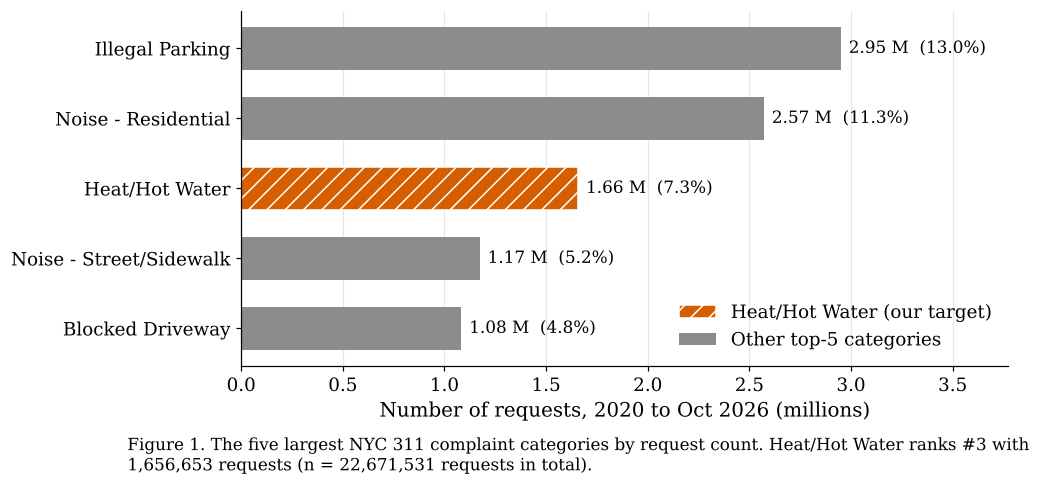

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.2))

# Largest category on top: reverse so barh draws it last.
plot_df = top.iloc[::-1]
colors = [VERMILION if flag else GREY for flag in plot_df["is_heating"]]
bars = ax.barh(
    [tidy_label(c) for c in plot_df["category"]],
    plot_df["n"] / 1e6,
    color=colors,
    height=0.62,
)

for bar, flag in zip(bars, plot_df["is_heating"]):
    if flag:
        bar.set_hatch("//")
        bar.set_edgecolor("white")

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    label = f"{row['n'] / 1e6:.2f} M  ({row['share']:.1f}%)"
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=11)

ax.set_xlim(0, top["n"].max() / 1e6 * 1.28)
ax.set_xlabel("Number of requests, 2020 to Oct 2026 (millions)")
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Heat/Hot Water (our target)"),
        Patch(facecolor=GREY, label="Other top-5 categories"),
    ],
    loc="lower right",
)

add_caption(
    fig,
    f"Figure 1. The five largest NYC 311 complaint categories by request count. "
    f"Heat/Hot Water ranks #{heating_rank} with {top.loc[top['is_heating'], 'n'].iloc[0]:,} requests "
    f"(n = {TOTAL_ROWS:,} requests in total).",
)
fig.savefig(FIG_DIR / "01_top5_categories.png")
plt.show()

**Reading Figure 1.** Heating is the third-largest complaint category in the whole city, ahead of street noise and blocked driveways.
It is large enough to model on its own, and it comes from a single agency (HPD) with a single, well-defined resolution process.

**Question the figure answers:** *Beyond the top five, how does heating compare with the rest of the 20 largest categories, and how concentrated is 311 demand?*

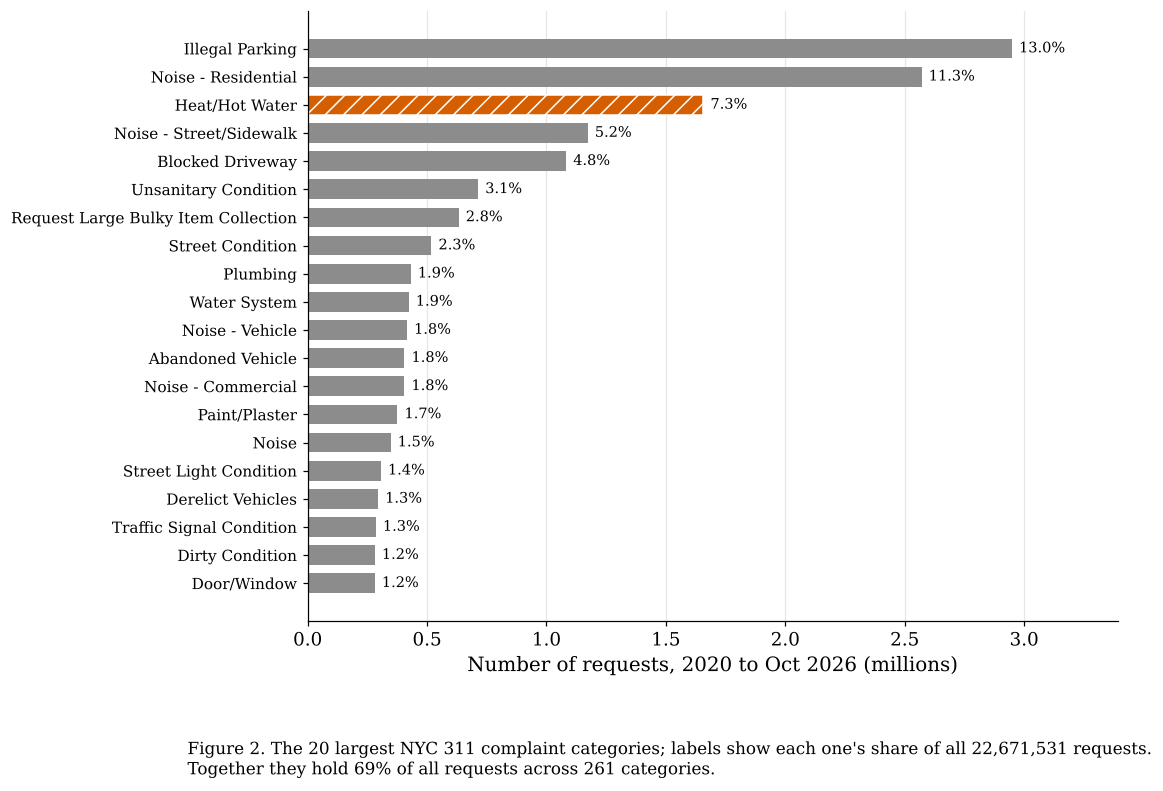

In [11]:
top20 = counts.head(20).copy()
top20["share"] = top20["n"] / TOTAL_ROWS * 100
top20_share = top20["share"].sum()

fig, ax = plt.subplots(figsize=(9.5, 7.2))
plot_df = top20.iloc[::-1]
is_heat = plot_df["category"] == HEATING_CATEGORY
bars = ax.barh([tidy_label(c) for c in plot_df["category"]], plot_df["n"] / 1e6,
               color=[VERMILION if h else GREY for h in is_heat], height=0.7)
for bar, heat, share in zip(bars, is_heat, plot_df["share"]):
    if heat:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2, f"{share:.1f}%", va="center", fontsize=9.5)
ax.set_xlim(0, top20["n"].max() / 1e6 * 1.15)
ax.set_xlabel("Number of requests, 2020 to Oct 2026 (millions)")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", visible=False)

add_caption(fig, f"Figure 2. The 20 largest NYC 311 complaint categories; labels show each one's share of all {TOTAL_ROWS:,} requests. "
                 f"Together they hold {top20_share:.0f}% of all requests across {len(counts)} categories.")
fig.savefig(FIG_DIR / "02_top20_categories.png")
plt.show()

**Reading Figure 2.** The 20 largest categories hold 69% of all 22.67 million requests, and heating is third with 7.3%. It is also by far the largest housing-condition
category: more than twice `Unsanitary Condition` (3.1%) and several times `Plumbing` (1.9%), `Paint/Plaster` (1.7%) and `Door/Window` (1.2%). A model built for heating
therefore covers the single biggest share of HPD's 311 workload.

## 2. Keep only heating requests

**Decision.** Keep rows where the upper-cased `Problem` equals `HEAT/HOT WATER`. Drop every other row.

**Why.**
- The project predicts heating resolution time only. Other categories have different agencies, processes and timescales, so mixing them would blur the target.
- Matching on the upper-cased label keeps the 1,814 rows that were typed `Heat/Hot Water` in Aug to Oct 2023.
- `Non-Residential Heat` (DOHMH) is a different category with a different process, so this rule removes it too.

**How.** DuckDB filters the 16 GB file and writes the kept rows to Parquet. Every column stays as raw text for now,
because type conversion is a cleaning step we do later and document there.

In [12]:
def extract_heating_rows():
    """Filter the big CSV down to heating rows once and cache them as Parquet."""
    if HEATING_PARQUET.exists():
        return

    query = f"""
        COPY (
            SELECT *
            FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
            WHERE upper(trim("{CATEGORY_COL}")) = '{HEATING_CATEGORY}'
        ) TO '{HEATING_PARQUET}' (FORMAT parquet)
    """
    duckdb.connect().execute(query)


extract_heating_rows()
heating = pd.read_parquet(HEATING_PARQUET)
print(f"Kept {len(heating):,} rows x {heating.shape[1]} columns")

Kept 1,656,653 rows x 44 columns


In [13]:
expected = int(counts.loc[counts["category"] == HEATING_CATEGORY, "n"].iloc[0])
assert len(heating) == expected, f"row count {len(heating):,} does not match category count {expected:,}"

kept = len(heating)
dropped = TOTAL_ROWS - kept
print(f"Before: {TOTAL_ROWS:,} rows")
print(f"After:  {kept:,} rows ({kept / TOTAL_ROWS * 100:.1f}% kept)")
print(f"Dropped: {dropped:,} rows from {len(counts) - 1} other categories")

Before: 22,671,531 rows
After:  1,656,653 rows (7.3% kept)
Dropped: 21,014,878 rows from 260 other categories


### Before and after

**Question the figure answers:** *How many rows did the filter remove, and which categories did they come from?*

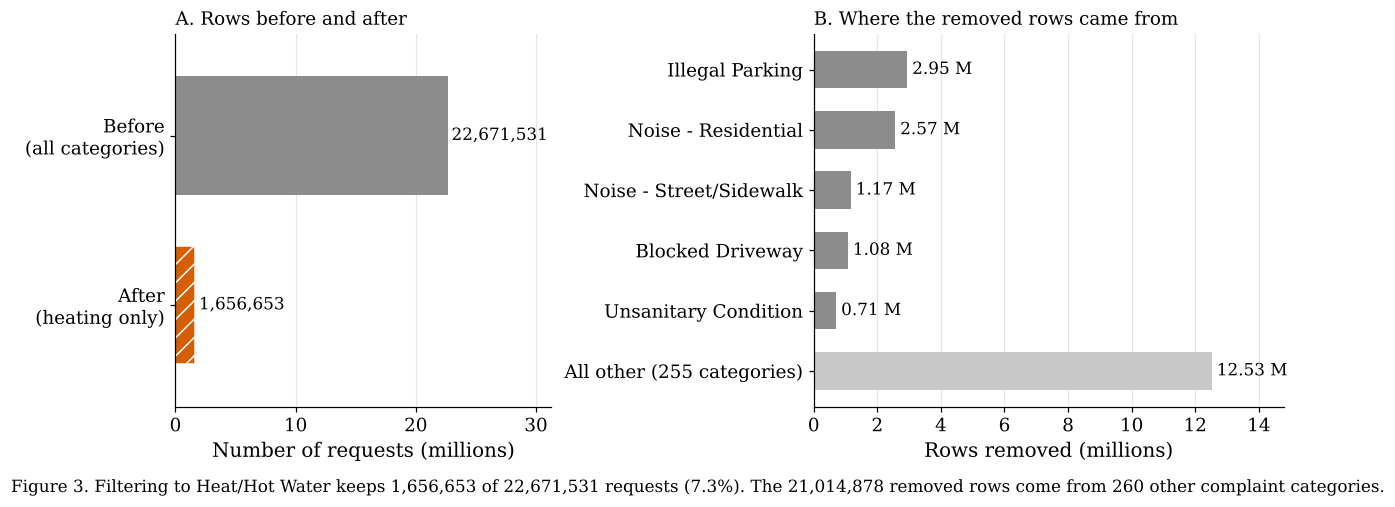

In [14]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.62})

# Panel A: row count before and after, zero baseline.
ax_a.barh(
    ["After\n(heating only)", "Before\n(all categories)"],
    [kept / 1e6, TOTAL_ROWS / 1e6],
    color=[VERMILION, GREY],
    height=0.7,
)
ax_a.patches[0].set_hatch("//")
ax_a.patches[0].set_edgecolor("white")
for patch, value in zip(ax_a.patches, [kept, TOTAL_ROWS]):
    ax_a.text(patch.get_width() + 0.3, patch.get_y() + patch.get_height() / 2, f"{value:,}", va="center", fontsize=11)
ax_a.set_xlim(0, TOTAL_ROWS / 1e6 * 1.38)
ax_a.set_ylim(-0.6, 1.6)
ax_a.set_xlabel("Number of requests (millions)")
ax_a.grid(axis="y", visible=False)
ax_a.set_title("A. Rows before and after", loc="left", fontsize=12)

# Panel B: what was removed, largest first, 'all other' last.
removed = counts[counts["category"] != HEATING_CATEGORY].copy()
largest = removed.head(5)
rest = removed.iloc[5:]["n"].sum()
labels = [tidy_label(c) for c in largest["category"]] + [f"All other ({len(removed) - 5} categories)"]
values = list(largest["n"] / 1e6) + [rest / 1e6]
bar_colors = [GREY] * 5 + ["#C8C8C8"]

positions = np.arange(len(labels))[::-1]
ax_b.barh(positions, values, color=bar_colors, height=0.62)
ax_b.set_yticks(positions)
ax_b.set_yticklabels(labels)
for pos, value in zip(positions, values):
    ax_b.text(value + 0.15, pos, f"{value:.2f} M", va="center", fontsize=11)
ax_b.set_xlim(0, max(values) * 1.18)
ax_b.set_xlabel("Rows removed (millions)")
ax_b.grid(axis="y", visible=False)
ax_b.set_title("B. Where the removed rows came from", loc="left", fontsize=12)

add_caption(
    fig,
    f"Figure 3. Filtering to Heat/Hot Water keeps {kept:,} of {TOTAL_ROWS:,} requests ({kept / TOTAL_ROWS * 100:.1f}%). "
    f"The {dropped:,} removed rows come from {len(removed)} other complaint categories.",
)
fig.savefig(FIG_DIR / "03_filter_to_heating_before_after.png")
plt.show()

## 3. The heating-only dataset

From here on, `heating` is the working dataset. First look at its structure.

In [15]:
heating.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70607308,10/01/2026 11:58:54 PM,None,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HOT WATER,RESIDENTIAL BUILDING,10467,...,None,None,None,None,None,None,None,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,70615467,10/01/2026 11:41:10 PM,None,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11355,...,None,None,None,None,None,None,None,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,70613895,10/01/2026 11:31:41 PM,None,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10019,...,None,None,None,None,None,None,None,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)
3,70608878,10/01/2026 11:31:30 PM,None,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11226,...,None,None,None,None,None,None,None,40.65595860808,-73.95490586002,POINT (-73.954905860019 40.655958608083)
4,70608877,10/01/2026 11:26:06 PM,None,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10032,...,None,None,None,None,None,None,None,40.82946158953,-73.94079691863,POINT (-73.940796918633 40.829461589532)


In [16]:
heating.shape

(1656653, 44)

## 4. Cleaning step 1: redundant structure

**Question this step answers:** *Which columns and rows add nothing, so they can go before we analyse anything?*

Order matters: **drop the ID column first**, because a unique ID makes `duplicated()` unable to ever fire.
Then count and drop duplicate rows. Then drop columns that hold a single value, columns that are exact copies of another column, and columns that can be rebuilt from another column.

### 4.1 The ID column: `Unique Key`

`Unique Key` is a serial number NYC assigns to every request. It carries no information about resolution time,
and it hides duplicates, because two otherwise identical requests still get different keys.

In [17]:
ID_COL = "Unique Key"

print(f"{ID_COL}: {heating[ID_COL].nunique():,} distinct values for {len(heating):,} rows, so every row has its own ID")
print(f"duplicated() with the ID:    {heating.duplicated().sum():,}")
print(f"duplicated() without the ID: {heating.drop(columns=[ID_COL]).duplicated().sum():,}")

Unique Key: 1,656,653 distinct values for 1,656,653 rows, so every row has its own ID


duplicated() with the ID:    0


duplicated() without the ID: 3,128


**Decision.** Drop `Unique Key`. The check above shows why: with the ID the duplicate count is 0, without it the real count appears.
`clean` is the working copy from here on; `heating` stays untouched as the "before" reference for every before/after figure.

In [18]:
clean = heating.drop(columns=[ID_COL])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,656,653 rows x 43 columns


### 4.2 Duplicate rows

A row is an **exact duplicate** when every remaining column matches an earlier row, down to the second in `Created Date` and `Closed Date`.
`keep="first"` keeps one copy of each. Because the copies are identical, it does not matter which one is kept.

In [19]:
DATE_FORMAT = "%m/%d/%Y %I:%M:%S %p"
CHANNEL_COL = "Open Data Channel Type"


def resolution_hours(frame):
    """Hours between Created Date and Closed Date. Only used here to check what a drop does to the target."""
    created = pd.to_datetime(frame["Created Date"], format=DATE_FORMAT)
    closed = pd.to_datetime(frame["Closed Date"], format=DATE_FORMAT)
    return (closed - created).dt.total_seconds() / 3600

In [20]:
is_duplicate = clean.duplicated(keep="first")
n_duplicates = int(is_duplicate.sum())
all_copies = clean[clean.duplicated(keep=False)]

group_sizes = all_copies.groupby(list(all_copies.columns), dropna=False).size()
size_table = group_sizes.value_counts().sort_index().rename_axis("copies of the same row").rename("groups")

print(f"Exact duplicate rows to remove: {n_duplicates:,} ({n_duplicates / len(clean) * 100:.2f}% of rows)")
print(f"Rows involved, including the copy we keep: {len(all_copies):,} in {len(group_sizes):,} groups")
size_table

Exact duplicate rows to remove: 3,128 (0.19% of rows)
Rows involved, including the copy we keep: 6,160 in 3,032 groups


copies of the same row
2    2942
3      85
4       4
5       1
Name: groups, dtype: int64

**Are these real duplicates or two genuine complaints?** The same request submitted twice in the same second is a double-tap on "submit".
Two different tenants filing at the very same second, for the same address, with the same answer and close time, would be a coincidence.
If these are double-taps, the mobile app should be heavily over-represented among them.

In [21]:
channel_all = clean[CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = clean.loc[is_duplicate, CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = channel_removed.reindex(channel_all.index, fill_value=0)

channel_table = pd.DataFrame({"all rows (%)": channel_all.round(1), "removed duplicates (%)": channel_removed.round(1)})
channel_table

,all rows (%),removed duplicates (%)
Open Data Channel Type,,
ONLINE,53.7,28.3
PHONE,28.1,2.1
MOBILE,18.2,69.6


**Decision.** Drop the exact duplicates, keeping the first copy.

**Why.** They are repeated submissions of one request, and keeping them would count that request twice in every average and model fit.

**Not dropped.** Rows that match on address and creation second but differ elsewhere (for example a different `Closed Date`) are
different complaints, such as separate apartments in one building. We cannot tell them apart from the data, so they stay.

In [22]:
rows_before = len(clean)
hours_before = resolution_hours(clean)

clean = clean[~is_duplicate].reset_index(drop=True)
hours_after = hours_before[~is_duplicate]

assert clean.duplicated().sum() == 0
assert rows_before - len(clean) == n_duplicates
print(f"{rows_before:,} rows -> {len(clean):,} rows (removed {n_duplicates:,})")

1,656,653 rows -> 1,653,525 rows (removed 3,128)


### Before and after

**Question the figure answers:** *Which rows did the duplicate drop remove, and did it change the target?*

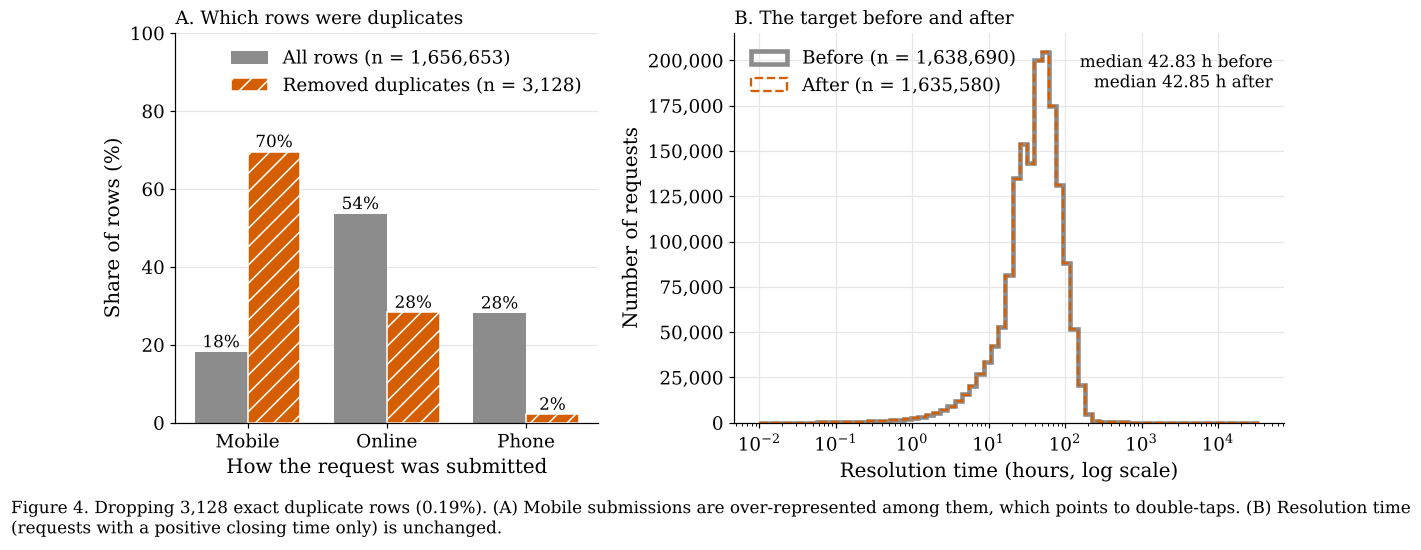

In [23]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.3], "wspace": 0.28})

# Panel A: channel mix of the removed rows against all rows, same zero baseline.
order = list(channel_removed.sort_values(ascending=False).index)
positions = np.arange(len(order))
bar_width = 0.38

ax_a.bar(positions - bar_width / 2, [channel_all[c] for c in order], bar_width, color=GREY)
ax_a.bar(
    positions + bar_width / 2,
    [channel_removed[c] for c in order],
    bar_width,
    color=VERMILION,
    hatch="//",
    edgecolor="white",
)
for pos, channel in zip(positions, order):
    ax_a.text(pos - bar_width / 2, channel_all[channel] + 1.2, f"{channel_all[channel]:.0f}%", ha="center", fontsize=11)
    ax_a.text(pos + bar_width / 2, channel_removed[channel] + 1.2, f"{channel_removed[channel]:.0f}%", ha="center", fontsize=11)

ax_a.set_xticks(positions)
ax_a.set_xticklabels([c.title() for c in order])
ax_a.set_ylim(0, 100)
ax_a.set_ylabel("Share of rows (%)")
ax_a.set_xlabel("How the request was submitted")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which rows were duplicates", loc="left", fontsize=12)
ax_a.legend(
    handles=[
        Patch(facecolor=GREY, label=f"All rows (n = {rows_before:,})"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label=f"Removed duplicates (n = {n_duplicates:,})"),
    ],
    loc="upper right",
)

# Panel B: resolution time before and after, one axis so the curves can be compared directly.
positive_before = hours_before[hours_before > 0].dropna()
positive_after = hours_after[hours_after > 0].dropna()
bins = np.logspace(-2, np.log10(positive_before.max()), 70)

ax_b.hist(positive_before, bins=bins, histtype="step", color=GREY, linewidth=3.0, label=f"Before (n = {len(positive_before):,})")
ax_b.hist(positive_after, bins=bins, histtype="step", color=VERMILION, linewidth=1.5, linestyle="--", label=f"After (n = {len(positive_after):,})")
ax_b.set_xscale("log")
ax_b.set_xlabel("Resolution time (hours, log scale)")
ax_b.set_ylabel("Number of requests")
ax_b.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax_b.set_title("B. The target before and after", loc="left", fontsize=12)
ax_b.legend(loc="upper left")
ax_b.text(
    0.98,
    0.95,
    f"median {positive_before.median():.2f} h before\nmedian {positive_after.median():.2f} h after",
    transform=ax_b.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)

add_caption(
    fig,
    f"Figure 4. Dropping {n_duplicates:,} exact duplicate rows ({n_duplicates / rows_before * 100:.2f}%). "
    f"(A) Mobile submissions are over-represented among them, which points to double-taps. "
    f"(B) Resolution time (requests with a positive closing time only) is unchanged.",
)
fig.savefig(FIG_DIR / "04_duplicate_rows_before_after.png")
plt.show()

In [24]:
summary = pd.DataFrame(
    {
        "rows": [rows_before, len(clean)],
        "median (h)": [hours_before.median(), hours_after.median()],
        "mean (h)": [hours_before.mean(), hours_after.mean()],
        "90th pct (h)": [hours_before.quantile(0.9), hours_after.quantile(0.9)],
    },
    index=["before", "after"],
)
summary.round(2)

,rows,median (h),mean (h),90th pct (h)
before,1656653,42.82,50.89,95.01
after,1653525,42.84,50.92,95.04


**Reading Figure 4.** The removed rows are mostly mobile-app submissions, which supports the double-tap explanation.
The target distribution does not move, so this drop is safe. It is still the right thing to do for counting and for model training.

### 4.3 Columns that hold a single value

A column with the same value in every row cannot help predict anything, because it never varies.

Four columns should be like this:
- `Agency` and `Agency Name`: every row is handled by HPD.
- `Park Facility Name`: a placeholder for park complaints, which heating is not.
- `Problem (formerly Complaint Type)`: we filtered on it in section 2, so it has one value by construction.

The code checks this instead of assuming it. Values are upper-cased and trimmed first, because `Problem` is spelled
`HEAT/HOT WATER` in most rows and `Heat/Hot Water` in 1,814 rows, and those are the same value.

In [25]:
CONSTANT_CANDIDATES = [
    "Agency",
    "Agency Name",
    "Park Facility Name",
    "Problem (formerly Complaint Type)",
]

constant_cols = []
for col in CONSTANT_CANDIDATES:
    raw_distinct = clean[col].nunique(dropna=False)
    normalised = clean[col].str.strip().str.upper()
    normalised_distinct = normalised.nunique(dropna=False)
    only_value = normalised.iloc[0]

    print(f"{col}")
    print(f"    distinct values as written: {raw_distinct}")
    print(f"    distinct values after upper-casing: {normalised_distinct}  (value: {only_value!r})")

    if normalised_distinct == 1:
        constant_cols.append(col)

Agency
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'HPD')


Agency Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT')


Park Facility Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'UNSPECIFIED')


Problem (formerly Complaint Type)
    distinct values as written: 2
    distinct values after upper-casing: 1  (value: 'HEAT/HOT WATER')


**Decision.** All four have exactly one value in every row, so each is dropped.

**Why.** A column that never changes has no relationship with resolution time, and it only adds width to the data.

In [26]:
columns_before = clean.shape[1]
clean = clean.drop(columns=constant_cols)

print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 4 constant columns: ['Agency', 'Agency Name', 'Park Facility Name', 'Problem (formerly Complaint Type)']
clean: 1,653,525 rows x 39 columns (was 43)


### 4.4 Columns that are copies of another column

**The problem.** Three columns look like separate fields, but their names suggest they repeat another column:

| Possible copy | Possible original |
|---|---|
| `Intersection Street 1` | `Cross Street 1` |
| `Intersection Street 2` | `Cross Street 2` |
| `Park Borough` | `Borough` |

A copy adds no information, and it counts the same signal twice in any correlation matrix or model.

**The rule.** If a column shares *all* of its values with its partner, in every row (a blank in both counts as a match), drop the copy and keep the original.
If even a few rows differ, the column carries something extra and stays.

In [27]:
COPY_PAIRS = [
    ("Cross Street 1", "Intersection Street 1"),
    ("Cross Street 2", "Intersection Street 2"),
    ("Borough", "Park Borough"),
]

copy_cols = []
for original, copy in COPY_PAIRS:
    same = clean[original].fillna("<missing>").eq(clean[copy].fillna("<missing>"))
    n_same = int(same.sum())
    print(f"{copy!r} matches {original!r} in {n_same:,} of {len(clean):,} rows")

    if same.all():
        copy_cols.append(copy)

'Intersection Street 1' matches 'Cross Street 1' in 1,653,525 of 1,653,525 rows


'Intersection Street 2' matches 'Cross Street 2' in 1,653,525 of 1,653,525 rows


'Park Borough' matches 'Borough' in 1,653,525 of 1,653,525 rows


**Decision.** Each of the three matches its partner in every row, so the copy is dropped and the original kept.

**Why.** Nothing is lost, because the original column holds exactly the same values.

In [28]:
columns_before = clean.shape[1]
clean = clean.drop(columns=copy_cols)

print(f"Dropped {len(copy_cols)} copy columns: {copy_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 3 copy columns: ['Intersection Street 1', 'Intersection Street 2', 'Park Borough']
clean: 1,653,525 rows x 36 columns (was 39)


### 4.5 `Address Type`

`Address Type` records how NYC matched the address (for example `ADDRESS` or `INTERSECTION`).
Every heating request is filed against a building address, so it should be the same value throughout.

In [29]:
address_type_counts = clean["Address Type"].value_counts(dropna=False)
top_value = address_type_counts.index[0]
top_share = address_type_counts.iloc[0] / len(clean) * 100

print(f"{top_value!r} in {address_type_counts.iloc[0]:,} of {len(clean):,} rows ({top_share:.4f}%)")
address_type_counts

'ADDRESS' in 1,653,522 of 1,653,525 rows (99.9998%)


Address Type
ADDRESS         1653522
None                  2
UNRECOGNIZED          1
Name: count, dtype: int64

**Decision.** Drop `Address Type`.

**Why.** It is `ADDRESS` in every row except a handful (the counts above show exactly which: blanks and one `UNRECOGNIZED`).
A column that is the same for essentially every request cannot explain why one request is resolved faster than another.
Dropping the column does not remove those rows.

In [30]:
clean = clean.drop(columns=["Address Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 35 columns


### 4.6 `Location`

**The problem.** `Location` looks like a separate location field, but it is the `Latitude` and `Longitude` columns written as one piece of text.

**How it is derived.** `Location` is the text `POINT (longitude latitude)`. Reading the two numbers back out of the brackets
gives `Longitude` first and `Latitude` second, the same values as the two columns. The only difference is rounding:
`Location` keeps 12 decimals and the other two columns keep 11.

In [31]:
clean[["Latitude", "Longitude", "Location"]].head(3)

,Latitude,Longitude,Location
0,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)


In [32]:
latitude = pd.to_numeric(clean["Latitude"])
longitude = pd.to_numeric(clean["Longitude"])

# The pattern pulls out the number after "POINT (" and the number before ")".
point = clean["Location"].str.extract(r"POINT \((-?[\d.]+) (-?[\d.]+)\)").astype(float)
longitude_from_location = point[0]
latitude_from_location = point[1]

largest_gap = max(
    (longitude_from_location - longitude).abs().max(),
    (latitude_from_location - latitude).abs().max(),
)
blank_in_same_rows = bool(longitude_from_location.isna().equals(longitude.isna()))

print(f"Largest difference between Location and Latitude/Longitude: {largest_gap:.1e} degrees")
print(f"Location is blank in exactly the rows where Latitude/Longitude are blank: {blank_in_same_rows}")

Largest difference between Location and Latitude/Longitude: 5.0e-12 degrees
Location is blank in exactly the rows where Latitude/Longitude are blank: True


**Decision.** Drop `Location`; keep `Latitude` and `Longitude`.

**Why.** The largest difference is about 5e-12 degrees, which is rounding at the 12th decimal place (under a millimetre),
and the blank rows match exactly. Nothing is lost. Two numeric columns are also easier to use than text that has to be parsed.

In [33]:
clean = clean.drop(columns=["Location"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 34 columns


### 4.7 `Location Type`

`Location Type` should describe where in a building the problem is. For almost every heating request it says the same thing,
and where it does differ it only repeats `Problem Detail`.

In [34]:
location_type_counts = clean["Location Type"].value_counts()
dominant_value = location_type_counts.index[0]
dominant_share = location_type_counts.iloc[0] / len(clean) * 100

print(f"{dominant_value!r} in {location_type_counts.iloc[0]:,} of {len(clean):,} rows ({dominant_share:.2f}%)")
location_type_counts

'RESIDENTIAL BUILDING' in 1,651,711 of 1,653,525 rows (99.89%)


Location Type
RESIDENTIAL BUILDING    1651711
Building-Wide              1103
Apartment                   711
Name: count, dtype: int64

In [35]:
# The few rows that differ: what does Problem Detail say for them?
detail_col = "Problem Detail (formerly Descriptor)"
differs = clean["Location Type"] != dominant_value

pd.crosstab(
    clean.loc[differs, "Location Type"].str.upper(),
    clean.loc[differs, detail_col].str.upper(),
)

Problem Detail (formerly Descriptor),APARTMENT ONLY,ENTIRE BUILDING,WATER SUPPLY
Location Type,,,
APARTMENT,559,152,0
BUILDING-WIDE,0,1102,1


**Decision.** Drop `Location Type`.

**Why.** It is `RESIDENTIAL BUILDING` in almost every row, so it does not vary. In the remaining rows
(created in the Aug to Oct 2023 window) it only restates `Problem Detail`: `Apartment` goes with `Apartment Only`
and `Building-Wide` goes with `Entire Building`. Either way, `Problem Detail` already holds the information.

In [36]:
clean = clean.drop(columns=["Location Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 33 columns


## 5. Cleaning step 2: numbers and dates stored as text

**Question this step answers:** *Are any numbers or dates stored as text, so that pandas cannot compute with them?*

Everything was loaded as text on purpose. The standard check is `info()` (types and non-blank counts) and `describe()`
(summary statistics of the numeric columns).

In [37]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype 
---  ------                                --------------    ----- 
 0   Created Date                          1653525 non-null  object
 1   Closed Date                           1635871 non-null  object
 2   Problem Detail (formerly Descriptor)  1653525 non-null  object
 3   Additional Details                    1653525 non-null  object
 4   Incident Zip                          1653335 non-null  object
 5   Incident Address                      1653520 non-null  object
 6   Street Name                           1653520 non-null  object
 7   Cross Street 1                        1808 non-null     object
 8   Cross Street 2                        1812 non-null     object
 9   City                                  1653373 non-null  object
 10  Landmark                              1812 non-null     object
 11

In [38]:
clean.describe().T

,count,unique,top,freq
Created Date,1653525,1574916,01/28/2022 08:42:16 AM,5
Closed Date,1635871,553427,10/03/2023 12:00:00 AM,363
Problem Detail (formerly Descriptor),1653525,5,ENTIRE BUILDING,1082238
Additional Details,1653525,8,NO HEAT,956509
Incident Zip,1653335,209,11226,51307
Incident Address,1653520,100145,2176 TIEBOUT AVENUE,15171
Street Name,1653520,5039,GRAND CONCOURSE,28249
Cross Street 1,1808,590,2 AVENUE,83
Cross Street 2,1812,580,1 AVENUE,86
City,1653373,89,BRONX,587119


**What the two outputs show.**
- `info()` lists every one of the 33 columns as text (`str`).
- `describe()` has no numeric column to summarise. Instead of `mean`, `min` and `max`, it falls back to `unique`, `top` and `freq`,
  so it cannot give any statistics for the columns that really are numbers.

**Numbers stored as text.** Four columns are obviously measurements: `Latitude`, `Longitude`, and the two State Plane coordinates
`X Coordinate (State Plane)` and `Y Coordinate (State Plane)`. The State Plane values also contain thousands commas (`1,019,332`).

**Dates stored as text.** `Created Date`, `Closed Date` and `Resolution Action Updated Date` are timestamps in the format
`MM/DD/YYYY hh:mm:ss AM/PM`.

**Digits that are not numbers.** `Incident Zip`, `Council District` and `BBL` are made of digits, but they are labels for a place,
not measurements, so they stay as text. `Due Date` is a date column but it is completely empty, so there is nothing to convert.

In [39]:
FLOAT_COLS = ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]
DATE_COLS = ["Created Date", "Closed Date", "Resolution Action Updated Date"]

nonblank_before = clean[FLOAT_COLS + DATE_COLS].notna().sum()

In [40]:
for col in FLOAT_COLS:
    without_commas = clean[col].str.replace(",", "", regex=False)
    clean[col] = pd.to_numeric(without_commas, errors="raise")

In [41]:
for col in DATE_COLS:
    clean[col] = pd.to_datetime(clean[col], format=DATE_FORMAT)

In [42]:
nonblank_after = clean[FLOAT_COLS + DATE_COLS].notna().sum()
assert (nonblank_after == nonblank_before).all()
print("Every converted column has the same number of non-blank values as before.")

Every converted column has the same number of non-blank values as before.


In [43]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   Created Date                          1653525 non-null  datetime64[ns]
 1   Closed Date                           1635871 non-null  datetime64[ns]
 2   Problem Detail (formerly Descriptor)  1653525 non-null  object        
 3   Additional Details                    1653525 non-null  object        
 4   Incident Zip                          1653335 non-null  object        
 5   Incident Address                      1653520 non-null  object        
 6   Street Name                           1653520 non-null  object        
 7   Cross Street 1                        1808 non-null     object        
 8   Cross Street 2                        1812 non-null     object        
 9   City                                  1653373 

In [44]:
clean[FLOAT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,1653337.0,4.076785e+01,0.088558,40.500300,40.682304,4.079981e+01,4.084518e+01,4.091229e+01
Longitude,1653337.0,-7.391797e+01,0.054398,-74.250801,-73.951493,-7.392093e+01,-7.388784e+01,-7.370074e+01
X Coordinate (State Plane),1653337.0,1.006964e+06,15071.966976,914513.000000,997691.000000,1.006137e+06,1.015294e+06,1.067177e+06
Y Coordinate (State Plane),1653337.0,2.190393e+05,32266.028285,121644.000000,187885.000000,2.306720e+05,2.472200e+05,2.716640e+05


In [45]:
clean[DATE_COLS].describe().T

,count,mean,min,25%,50%,75%,max
Created Date,1653525,2023-09-10 18:21:11.378136320,2020-01-01 00:04:45,2022-01-26 16:20:05,2023-12-05 05:55:10,2025-03-10 00:16:38,2026-10-01 23:58:54
Closed Date,1635871,2023-09-05 00:16:44.594122496,2020-01-01 17:21:51,2022-01-27 10:18:25,2023-11-30 21:55:03,2025-03-02 22:52:44,2026-10-01 23:31:00
Resolution Action Updated Date,1653348,2023-09-12 09:27:46.543129600,2020-01-01 17:21:51,2022-01-29 00:00:00,2023-12-06 00:00:00,2025-03-11 00:00:00,2026-10-01 23:31:00


**Changes made.**

| Columns | Before | After | How |
|---|---|---|---|
| `Latitude`, `Longitude` | text | float64 | `pd.to_numeric` |
| `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | text | float64 | thousands commas removed, then `pd.to_numeric` |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | text | datetime64 | `pd.to_datetime` with the exact format |

Both conversions used strict settings (`errors="raise"` for numbers, an exact format for dates), so a value that did not fit would have stopped the cell.
None did, and every converted column has the same number of non-blank values as before (checked by the assertion).

`describe()` now returns one row for each of the four numeric columns, matching the number of numeric columns we expect,
and the date columns now have a real earliest and latest timestamp.
No rows or columns were removed in this step.

## 6. Cleaning step 3: missing data

**Question this step answers:** *Which columns have missing values, how many, and why?*

Missing data comes in three disguises, and `isna()` only sees the first:

| Disguise | Example | Seen by `isna()`? |
|---|---|---|
| 1. Marked as missing | `NaN`, `NaT`, blank | Yes |
| 2. A string standing in for a value | `"Unspecified"`, `"N/A"` | No |
| 3. A legal value that is impossible | a closing time before the opening time | No |

This section does three things: chart the missing rate of every column, drop the columns that are completely empty,
and report on the rest. The percentage rule (drop, impute or keep) is applied afterwards.

### 6.1 How much is missing, column by column

**Question the figure answers:** *Which columns are missing values, and are any of them past the 30% line where a column becomes too incomplete to trust?*

The bands follow a common rule of thumb: under 5% is a small problem, 5 to 30% needs care, and over 30% means the column is unreliable.

In [46]:
def missing_percent(frame):
    """Percent of missing values (NaN or NaT) in each column, largest first."""
    return (frame.isna().mean() * 100).sort_values(ascending=False)


def percent_label(value):
    """Format a percentage so that tiny values stay readable."""
    if value == 0:
        return "0%"
    if value >= 10:
        return f"{value:.1f}%"
    if value >= 0.01:
        return f"{value:.2f}%"
    return "<0.01%"


missing_before = missing_percent(clean)
columns_total = clean.shape[1]
missing_before.head(14).round(3)

Due Date                    100.000
Taxi Pick Up Location       100.000
Facility Type               100.000
Taxi Company Borough        100.000
Bridge Highway Direction    100.000
Road Ramp                   100.000
Bridge Highway Segment      100.000
Bridge Highway Name         100.000
Vehicle Type                100.000
Cross Street 1               99.891
Landmark                     99.890
Cross Street 2               99.890
Closed Date                   1.068
BBL                           0.411
dtype: float64

In [47]:
# Isna() cannot see text that is only spaces, so check that no column has any.
text_columns = [
    col
    for col in clean.columns
    if not pd.api.types.is_numeric_dtype(clean[col]) and not pd.api.types.is_datetime64_any_dtype(clean[col])
]
whitespace_only = sum(int((clean[col].dropna().str.strip() == "").sum()) for col in text_columns)
print(f"Values that are only whitespace, across {len(text_columns)} text columns: {whitespace_only}")

Values that are only whitespace, across 26 text columns: 0


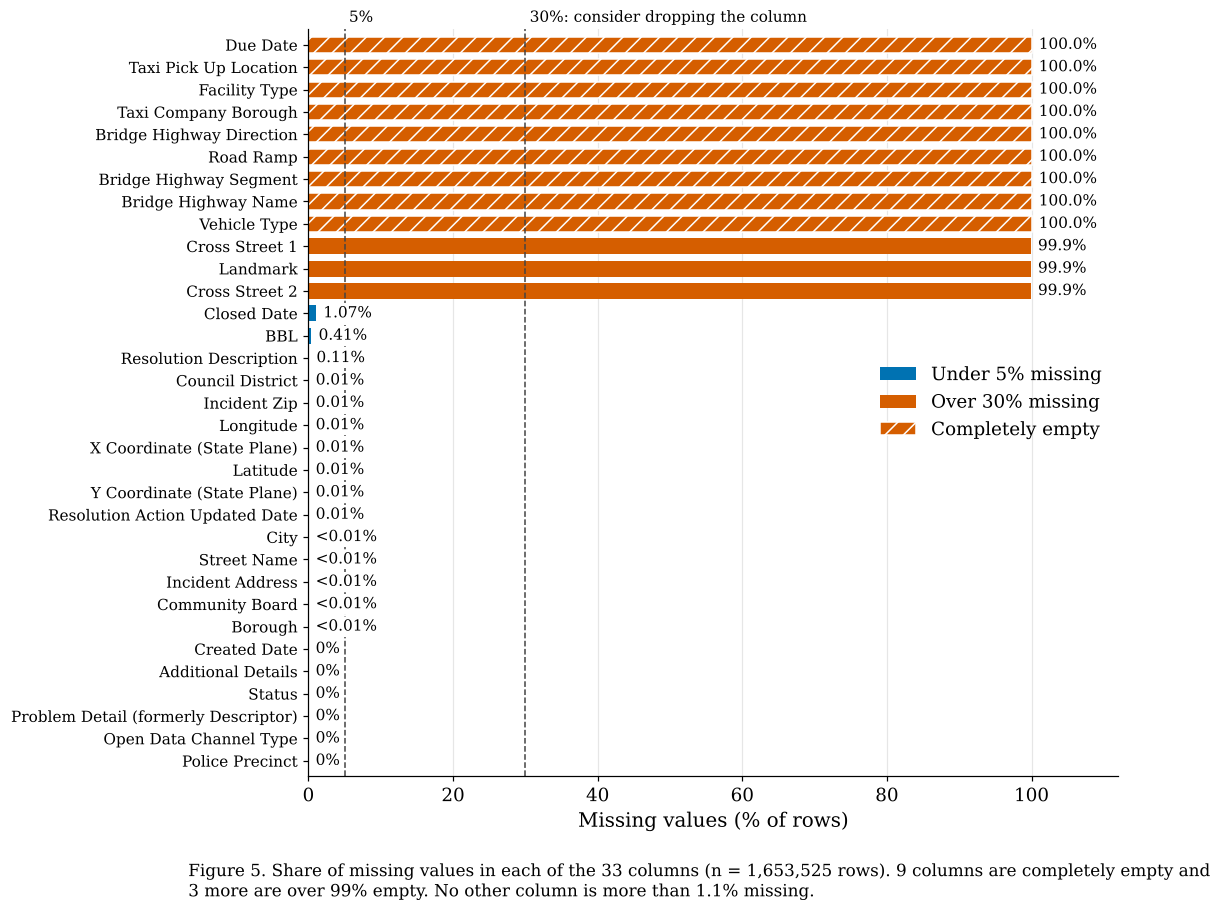

In [48]:
ORANGE = "#E69F00"


def band_colour(percent):
    """Colour by the three bands: under 5%, 5 to 30%, over 30%."""
    if percent > 30:
        return VERMILION
    if percent >= 5:
        return ORANGE
    return BLUE


names = list(missing_before.index)[::-1]
values = list(missing_before.values)[::-1]

fig, ax = plt.subplots(figsize=(9.5, 8.6))
bars = ax.barh(names, values, color=[band_colour(v) for v in values], height=0.72)

for bar, value in zip(bars, values):
    if value == 100:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
    ax.text(
        value + 1.0,
        bar.get_y() + bar.get_height() / 2,
        percent_label(value),
        va="center",
        fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
        zorder=4,
    )

for threshold in (5, 30):
    ax.axvline(threshold, color="#444444", linestyle="--", linewidth=1)
ax.text(5.6, 1.005, "5%", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")
ax.text(30.6, 1.005, "30%: consider dropping the column", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")

ax.set_xlim(0, 112)
ax.set_ylim(-0.7, len(names) - 0.3)
fig.subplots_adjust(bottom=0.09)
ax.set_xlabel("Missing values (% of rows)")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=BLUE, label="Under 5% missing"),
        Patch(facecolor=VERMILION, label="Over 30% missing"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Completely empty"),
    ],
    loc="center right",
)

n_empty = int((missing_before == 100).sum())
n_sparse = int(((missing_before > 99) & (missing_before < 100)).sum())
others_max = missing_before[missing_before < 99].max()
add_caption(
    fig,
    f"Figure 5. Share of missing values in each of the {columns_total} columns (n = {len(clean):,} rows). "
    f"{n_empty} columns are completely empty and {n_sparse} more are over 99% empty. "
    f"No other column is more than {others_max:.1f}% missing.",
    y=0.0,
)
fig.savefig(FIG_DIR / "05_missing_by_column.png")
plt.show()

**Reading Figure 5.** The columns split into two groups with nothing in between.
Twelve columns are essentially empty: nine are 100% blank, and three (`Cross Street 1`, `Cross Street 2`, `Landmark`) are about 99.9% blank.
Every other column is nearly complete, and none of them is anywhere near the 5% line.

### 6.2 Drop the columns that are completely empty

**Decision.** Drop every column whose values are all missing.

**Why.** A column with no values has nothing to learn from, and nothing can be imputed from nothing.
The nine columns are leftovers from other 311 complaint types (vehicles, taxis, bridges and highways) and have no meaning for a heating request.

In [49]:
all_null_cols = [col for col in clean.columns if clean[col].isna().all()]
columns_before = clean.shape[1]

clean = clean.drop(columns=all_null_cols)

print(f"Dropped {len(all_null_cols)} columns that are completely empty:")
for col in all_null_cols:
    print(f"    {col}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 9 columns that are completely empty:
    Facility Type
    Due Date
    Vehicle Type
    Taxi Company Borough
    Taxi Pick Up Location
    Bridge Highway Name
    Bridge Highway Direction
    Road Ramp
    Bridge Highway Segment
clean: 1,653,525 rows x 24 columns (was 33)


**Change made:** 9 completely empty columns dropped (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`,
`Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`).
No rows were removed. The 24 remaining columns all contain at least some data.

### 6.3 Drop the columns that are more than 30% missing

**Rule.** When more than 30% of a column is missing, the column is too incomplete to trust, and imputing it would mostly be inventing data.
The column is dropped. The code finds these columns from the data instead of using a hand-written list.

In [50]:
DROP_THRESHOLD = 30

missing_now = missing_percent(clean)
over_threshold = missing_now[missing_now > DROP_THRESHOLD]
columns_before = clean.shape[1]

print(f"Columns with more than {DROP_THRESHOLD}% missing: {len(over_threshold)}")
over_threshold.rename("missing (%)").round(3)

Columns with more than 30% missing: 3


Cross Street 1    99.891
Cross Street 2    99.890
Landmark          99.890
Name: missing (%), dtype: float64

In [51]:
dropped_for_missing = list(over_threshold.index)
clean = clean.drop(columns=dropped_for_missing)

print(f"Dropped: {dropped_for_missing}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped: ['Cross Street 1', 'Cross Street 2', 'Landmark']
clean: 1,653,525 rows x 21 columns (was 24)


**Change made: 3 columns dropped for being more than 30% missing.**

| Column | Missing | Note |
|---|---|---|
| `Cross Street 1` | 99.89% | filled in only for requests created 10 Aug to 6 Oct 2023 |
| `Cross Street 2` | 99.89% | same window |
| `Landmark` | 99.89% | same window |

Only about 1,810 of 1.65 million rows have a value in any of them, so they could not describe the typical request.
No rows were removed. `clean` now has 21 columns.

### 6.4 Columns that still have missing values

Nothing is dropped or filled here. This table lists every remaining column with a missing value, with the number of rows affected.

In [52]:
missing_table = pd.DataFrame(
    {
        "type": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "missing (%)": (clean.isna().mean() * 100).round(4),
    }
)
missing_table = missing_table[missing_table["missing rows"] > 0].sort_values("missing rows", ascending=False)
missing_table.index.name = "column"

complete = [col for col in clean.columns if col not in missing_table.index]
print(f"{len(missing_table)} of {clean.shape[1]} columns have missing values. Complete columns: {complete}")

missing_table.style.format({"missing rows": "{:,}", "missing (%)": "{:.4f}"})

15 of 21 columns have missing values. Complete columns: ['Created Date', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Status', 'Police Precinct', 'Open Data Channel Type']


,type,missing rows,missing (%)
column,,,
Closed Date,datetime64[ns],"17,654",1.0677
BBL,object,"6,795",0.4109
Resolution Description,object,"1,864",0.1127
Council District,object,190,0.0115
Incident Zip,object,190,0.0115
X Coordinate (State Plane),float64,188,0.0114
Y Coordinate (State Plane),float64,188,0.0114
Latitude,float64,188,0.0114
Longitude,float64,188,0.0114


### 6.5 Drop the open requests (missing target)

**Rule.** For the target variable, drop the rows where it is missing, because a model cannot be trained on answers that do not exist.

Here the target is the time between `Created Date` and `Closed Date`. `Closed Date` is blank exactly when a request has not closed yet,
so these rows have no resolution time. First, a check that the blanks really are the open requests:

In [53]:
open_mask = clean["Closed Date"].isna()
status_of_open = clean.loc[open_mask, "Status"].value_counts()

print(f"Rows with no Closed Date: {int(open_mask.sum()):,} ({open_mask.mean() * 100:.2f}% of rows)")
print()
print("Status of those rows:")
print(status_of_open.to_string())
print()
print(f"Rows with a Closed Date whose Status is Open or In Progress: {int((~open_mask & clean['Status'].isin(['Open', 'In Progress'])).sum())}")

Rows with no Closed Date: 17,654 (1.07% of rows)

Status of those rows:
Status
Open           17481
In Progress      173

Rows with a Closed Date whose Status is Open or In Progress: 0


**Decision.** Drop every request with no `Closed Date`. All of them are `Open` or `In Progress`, and no closed request is missing the date.

Section 7.4 checks the remaining status values as well.

**Why this needs a figure.** The open requests are not a random sample. They are mostly recent, so dropping them removes the requests
that had not had time to close. The figure shows how large that effect is and whether the rest of the data changes shape.

In [54]:
# Summaries of the data before the drop, for the figure.
created_year_before = clean["Created Year"] if "Created Year" in clean.columns else clean["Created Date"].dt.year

open_by_year = pd.DataFrame(
    {
        "all requests": created_year_before.value_counts().sort_index(),
        "open requests": created_year_before[open_mask].value_counts().sort_index(),
    }
).fillna(0)
open_by_year["open (%)"] = open_by_year["open requests"] / open_by_year["all requests"] * 100

BOROUGHS = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
borough_before = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_before = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

rows_before_open_drop = len(clean)
open_by_year.round(2)

,all requests,open requests,open (%)
Created Date,,,
2020,164573,149,0.09
2021,199148,168,0.08
2022,263693,324,0.12
2023,230973,302,0.13
2024,264410,2967,1.12
2025,315479,1532,0.49
2026,215249,12212,5.67


In [55]:
clean = clean[~open_mask].reset_index(drop=True)

borough_after = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_after = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

n_open_dropped = int(open_mask.sum())
assert clean["Closed Date"].notna().all()
assert rows_before_open_drop - len(clean) == n_open_dropped
print(f"{rows_before_open_drop:,} rows -> {len(clean):,} rows (removed {n_open_dropped:,} open requests)")

1,653,525 rows -> 1,635,871 rows (removed 17,654 open requests)


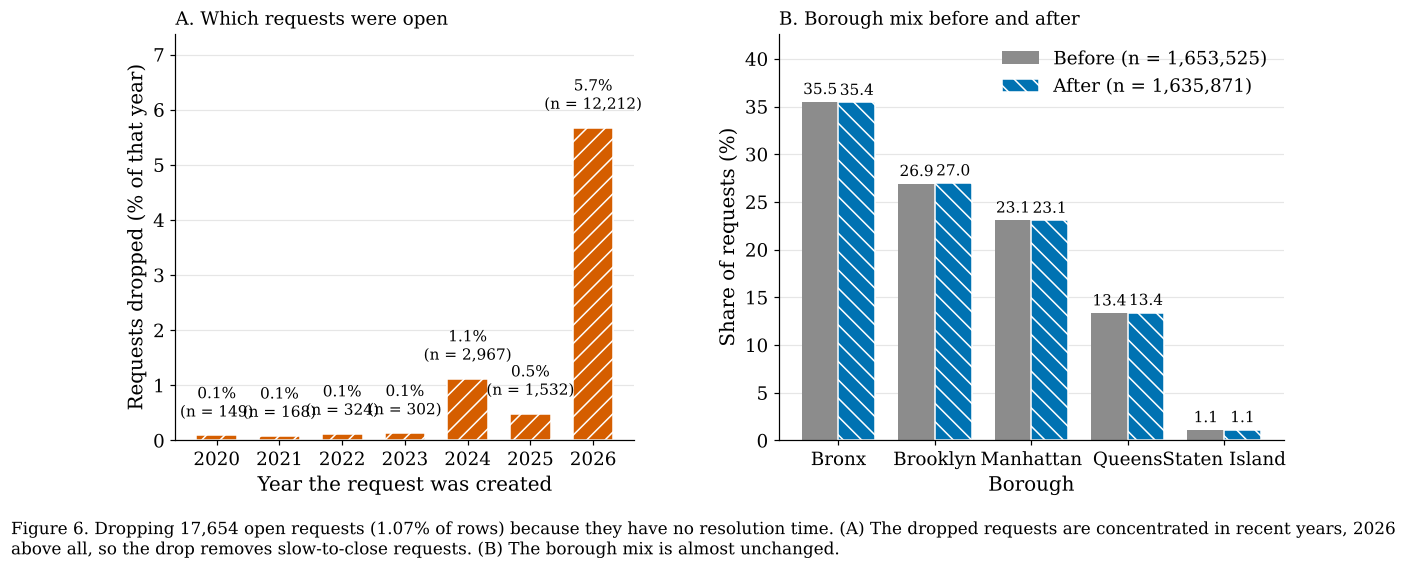

In [56]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.3})

# Panel A: what share of each year's requests were dropped. Zero baseline.
years = open_by_year.index.to_list()
shares = open_by_year["open (%)"].to_list()
bars = ax_a.bar([str(year) for year in years], shares, color=VERMILION, hatch="//", edgecolor="white", width=0.65)
for bar, share, year in zip(bars, shares, years):
    count = int(open_by_year.loc[year, "open requests"])
    ax_a.text(bar.get_x() + bar.get_width() / 2, share + 0.25, f"{share:.1f}%\n(n = {count:,})", ha="center", va="bottom", fontsize=10)

ax_a.set_ylim(0, max(shares) * 1.3)
ax_a.set_xlabel("Year the request was created")
ax_a.set_ylabel("Requests dropped (% of that year)")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which requests were open", loc="left", fontsize=12)

# Panel B: borough mix before and after, same zero baseline.
positions = np.arange(len(BOROUGHS))
bar_width = 0.38
ax_b.bar(positions - bar_width / 2, borough_before.values, bar_width, color=GREY)
ax_b.bar(positions + bar_width / 2, borough_after.values, bar_width, color=BLUE, hatch="\\\\", edgecolor="white")
for pos, before_value, after_value in zip(positions, borough_before.values, borough_after.values):
    ax_b.text(pos - bar_width / 2, before_value + 0.8, f"{before_value:.1f}", ha="center", fontsize=10)
    ax_b.text(pos + bar_width / 2, after_value + 0.8, f"{after_value:.1f}", ha="center", fontsize=10)

ax_b.set_xticks(positions)
ax_b.set_xticklabels([name.title() for name in BOROUGHS])
ax_b.set_ylim(0, borough_before.max() * 1.2)
ax_b.set_ylabel("Share of requests (%)")
ax_b.set_xlabel("Borough")
ax_b.grid(axis="x", visible=False)
ax_b.set_title("B. Borough mix before and after", loc="left", fontsize=12)
ax_b.legend(
    handles=[
        Patch(facecolor=GREY, label=f"Before (n = {rows_before_open_drop:,})"),
        Patch(facecolor=BLUE, hatch="\\\\", edgecolor="white", label=f"After (n = {len(clean):,})"),
    ],
    loc="upper right",
)

add_caption(
    fig,
    f"Figure 6. Dropping {n_open_dropped:,} open requests ({n_open_dropped / rows_before_open_drop * 100:.2f}% of rows) because they have no resolution time. "
    f"(A) The dropped requests are concentrated in recent years, 2026 above all, so the drop removes slow-to-close requests. "
    f"(B) The borough mix is almost unchanged.",
)
fig.savefig(FIG_DIR / "06_open_requests_dropped.png")
plt.show()

In [57]:
mix_change = pd.DataFrame({"before (%)": detail_before, "after (%)": detail_after})
mix_change["change (points)"] = mix_change["after (%)"] - mix_change["before (%)"]
mix_change.round(2)

,before (%),after (%),change (points)
Additional Details,,,
NO HEAT,57.86,57.91,0.05
NO HEAT AND NO HOT WATER,25.70,25.71,0.01
NO HOT WATER,16.10,16.03,-0.06
HEAT ON IN SUMMER,0.34,0.35,0.00


**Reading Figure 6.**
- **(A)** Open requests are rare in 2020 to 2023 (about 0.1% each year), then rise to 1.1% in 2024, 0.5% in 2025 and 5.7% in 2026. 2026 holds 12,212 of the 17,654 dropped rows.
  The requests dropped are the ones with the least time to close, so the drop removes slow cases and the target will read slightly faster than reality.
  The year is therefore not a neutral feature, which adds to the case for a time-based train/test split.
- **(B)** The borough mix moves by a fraction of a point, and the table shows the same for the type of problem. Apart from time, the dropped rows look like the rest.

**Change made: 17,654 rows dropped** (all `Open` or `In Progress`). Every remaining request has a `Closed Date`, so the target can be computed for all of them.
`clean` is now 1,635,871 rows by 21 columns. No columns were removed.

## 7. Cleaning step 4: packed and indirect fields

**Question this step answers:** *Does any column hold more than one piece of information, or hold information that only appears once it is computed from other columns?*

The one you expected is the **resolution time**: nothing stores it, but it is the difference between two timestamps.
It is the target, so it is created first.

### 7.1 Create the resolution time (the target)

**Definition.** `Resolution Hours` = `Closed Date` minus `Created Date`, in hours.

Hours fit this data: the median request takes about 43 hours, and 99% finish within a week, so days would be too coarse and minutes too fine.
Every remaining request has both timestamps (the open requests were dropped in 6.5), so every row gets a value.
The new column is only *created* here. Negative values and extreme values are handled in the target-cleaning step.

In [58]:
TARGET = "Resolution Hours"

if TARGET not in clean.columns:
    elapsed = clean["Closed Date"] - clean["Created Date"]
    clean[TARGET] = elapsed.dt.total_seconds() / 3600

target = clean[TARGET]
print(f"{TARGET} created: {target.notna().sum():,} values, {target.isna().sum():,} blank")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

Resolution Hours created: 1,635,871 values, 0 blank
clean: 1,635,871 rows x 22 columns


In [59]:
target.describe().to_frame(TARGET).T

,count,mean,std,min,25%,50%,75%,max
Resolution Hours,1635871.0,50.916073,192.969888,-20.312222,23.654722,42.841389,66.979167,33938.543889


In [60]:
print(f"Negative (closed before created): {(target < 0).sum():,}")
print(f"Zero (closed at the same instant): {(target == 0).sum():,}")
print(f"Over 30 days:                      {(target > 24 * 30).sum():,}")
print(f"Over 1 year:                       {(target > 24 * 365).sum():,}")

Negative (closed before created): 184
Zero (closed at the same instant): 107
Over 30 days:                      443
Over 1 year:                       115


**Change made: 1 column created, `Resolution Hours` (float64, hours).**

The mean (about 51 hours) sits above the median (about 43 hours), and the maximum is about 34,000 hours (nearly four years), so the distribution has a long right tail.
The counts above also show the impossible values waiting for the target-cleaning step: negative values, zeros, and very long durations.
No rows were removed.

### 7.2 Calendar fields packed inside `Created Date`

A timestamp holds several facts at once: the year, the month and the day of the week. A model cannot use them until they are separated,
and the target depends on all three (checked on requests resolved within 30 days):

- **Weekday.** Requests filed on a Friday or Saturday take about 16 hours longer (median about 51 h) than ones filed on a Tuesday (about 35 h).
  This is the clearest pattern, and it is not just winter demand.
- **Month.** It is not a simple winter effect. March to May is fastest (about 32 h) and December and January are slowest (about 48 h).
  A heating-season flag (October to May) separates only 40.2 h from 43.0 h, so the month is used instead of a flag.
- **Year.** Resolution time shifts between years (about 36 h in 2024, about 49 h in 2021).
  So the train/test split should be by time, and year cannot be treated as a clean feature.

Hour of day was left out on purpose; it shows a weaker signal.

Hour of day and a heat-season flag are still created in section 7.10, next to the workload features, so a tree model can combine them.

In [61]:
clean["Created Year"] = clean["Created Date"].dt.year
clean["Created Month"] = clean["Created Date"].dt.month
clean["Created Weekday"] = clean["Created Date"].dt.day_name()

clean[["Created Date", "Created Year", "Created Month", "Created Weekday"]].head()

,Created Date,Created Year,Created Month,Created Weekday
0,2026-10-01 17:53:22,2026,10,Thursday
1,2026-10-01 17:40:17,2026,10,Thursday
2,2026-10-01 17:05:48,2026,10,Thursday
3,2026-10-01 16:40:26,2026,10,Thursday
4,2026-10-01 15:05:30,2026,10,Thursday


In [62]:
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

check = clean.dropna(subset=[TARGET])
check = check[(check[TARGET] > 0) & (check[TARGET] < 24 * 30)]

by_weekday = check.groupby("Created Weekday")[TARGET].median().reindex(WEEKDAY_ORDER)
by_month = check.groupby("Created Month")[TARGET].median()
by_year = check.groupby("Created Year")[TARGET].median()

pd.DataFrame({"median hours by weekday": by_weekday.round(1)})

,median hours by weekday
Created Weekday,
Monday,40.4
Tuesday,34.9
Wednesday,35.1
Thursday,40.9
Friday,51.3
Saturday,51.3
Sunday,43.7


In [63]:
pd.DataFrame({"median hours by month": by_month.round(1)}).T

Created Month,1,2,3,4,5,6,7,8,9,10,11,12
median hours by month,47.9,43.8,32.2,31.8,31.7,34.4,43.3,42.9,41.0,38.1,45.8,48.4


In [64]:
pd.DataFrame({"median hours by year": by_year.round(1)}).T

Created Year,2020,2021,2022,2023,2024,2025,2026
median hours by year,46.6,49.3,49.0,38.4,36.4,39.4,43.9


**Change made: 3 columns created from `Created Date`.**

| New column | Values | Meaning |
|---|---|---|
| `Created Year` | 2020 to 2026 | year the request was filed |
| `Created Month` | 1 to 12 | month the request was filed |
| `Created Weekday` | Monday to Sunday | day of the week the request was filed |

The tables above confirm the pattern behind each one. The medians are computed only on requests resolved within 30 days, to keep the long tail from hiding the pattern.
No rows were removed.

### 7.3 One spelling per category in `Problem Detail` and `Additional Details`

**The problem.** Both columns spell each category two ways, for example `ENTIRE BUILDING` and `Entire Building`.
HPD switched to Title case only for requests created between 10 Aug and 6 Oct 2023, so a raw count splits one category in two,
and a model would treat the two spellings as different values. `Problem Detail` also holds one row reading `Water Supply`,
which is not a heating scope.

In [65]:
# Upper-case and trim both columns so each category has a single spelling.
DETAIL_COL = "Problem Detail (formerly Descriptor)"
EXTRA_COL = "Additional Details"
VALID_SCOPES = ["ENTIRE BUILDING", "APARTMENT ONLY"]

for col in [DETAIL_COL, EXTRA_COL]:
    canonical = clean[col].str.strip().str.upper()
    respelled = clean[col].notna() & (clean[col] != canonical)
    first = clean.loc[respelled, "Created Date"].min()
    last = clean.loc[respelled, "Created Date"].max()
    distinct_before = clean[col].nunique()
    clean[col] = canonical
    print(f"{col}: {distinct_before} spellings -> {clean[col].nunique()} categories; "
          f"{int(respelled.sum()):,} rows re-spelled, all created {first:%d %b %Y} to {last:%d %b %Y}")

Problem Detail (formerly Descriptor): 5 spellings -> 3 categories; 1,641 rows re-spelled, all created 10 Aug 2023 to 06 Oct 2023


Additional Details: 8 spellings -> 4 categories; 1,641 rows re-spelled, all created 10 Aug 2023 to 06 Oct 2023


In [66]:
# 'Water Supply' is not a heating scope, so it becomes a blank. The row itself stays.
not_a_scope = clean[DETAIL_COL].notna() & ~clean[DETAIL_COL].isin(VALID_SCOPES)
print(clean.loc[not_a_scope, DETAIL_COL].value_counts().to_string())
clean.loc[not_a_scope, DETAIL_COL] = np.nan

pd.concat(
    [clean[DETAIL_COL].value_counts(dropna=False), clean[EXTRA_COL].value_counts(dropna=False)],
    keys=[DETAIL_COL, EXTRA_COL],
).rename("rows").to_frame()

Problem Detail (formerly Descriptor)
WATER SUPPLY    1


rows
Problem Detail (formerly Descriptor) ENTIRE BUILDING           1069105
                                     APARTMENT ONLY             566765
                                     NaN                             1
Additional Details                   NO HEAT                    947267
                                     NO HEAT AND NO HOT WATER   420654
                                     NO HOT WATER               262285
                                     HEAT ON IN SUMMER            5665

**Decision.** Keep the upper-case spelling in both columns. `Problem Detail` now has 2 categories and `Additional Details` 4.
The single `Water Supply` value is blanked rather than dropped, because the request itself is a valid heating request.
No rows or columns were removed.

### 7.4 `Status` must agree with `Closed Date`

Section 6.5 dropped the rows with no `Closed Date` and checked that no `Open` or `In Progress` row had a closing date.
It did not check the other status values. A request is treated as closed only when **both** fields say so.

In [67]:
# Closed means Status == 'Closed' AND a Closed Date exists.
is_closed = (clean["Status"] == "Closed") & clean["Closed Date"].notna()
print(f"Rows that are not confirmed closed: {int((~is_closed).sum())}")
clean.loc[~is_closed, ["Created Date", "Closed Date", "Status", TARGET]]

Rows that are not confirmed closed: 2


,Created Date,Closed Date,Status,Resolution Hours
883213,2023-10-02 14:55:22,2023-10-03,Unspecified,9.077222
885211,2023-09-29 14:42:17,2023-10-04,Unspecified,105.295278


In [68]:
# Drop the unconfirmed rows; Status is then one value in every row, so it goes too.
rows_before_status_drop = len(clean)
clean = clean[is_closed].reset_index(drop=True)
n_status_dropped = rows_before_status_drop - len(clean)

assert (clean["Status"] == "Closed").all()
clean = clean.drop(columns=["Status"])
print(f"{rows_before_status_drop:,} rows -> {len(clean):,} rows (removed {n_status_dropped} rows whose Status is not 'Closed')")
print(f"Rows removed for a missing or unconfirmed target, 6.5 plus 7.4: {n_open_dropped + n_status_dropped:,}")

1,635,871 rows -> 1,635,869 rows (removed 2 rows whose Status is not 'Closed')
Rows removed for a missing or unconfirmed target, 6.5 plus 7.4: 17,656


**Decision.** Drop the 2 rows whose `Status` is `Unspecified` even though they carry a `Closed Date`.
Nothing confirms they were really closed, so their resolution time cannot be trusted. Together with section 6.5 that makes
17,656 rows removed for a missing or unconfirmed target. `Status` is then `Closed` in every row, so it is dropped as a constant column
(it was also only known after resolution).

### 7.5 Negative and zero resolution times

A negative `Resolution Hours` means the request closed before it was opened. That is the third disguise of missing data:
a legal-looking value that is impossible. A zero means it closed in the same second it was created.

In [69]:
# Flag both cases; blank the negative values so they never enter the target.
negative = clean[TARGET] < 0
clean["Is Negative Duration"] = negative
clean["Is Instant Close"] = clean[TARGET] == 0

print(f"Negative: {int(negative.sum())} rows")
print(f"    within one minute of zero (clock noise): {int((negative & (clean[TARGET] >= -1 / 60)).sum())}")
print(f"    range: {clean.loc[negative, TARGET].min():,.1f} h to {clean.loc[negative, TARGET].max():,.2f} h")
print(f"Zero:     {int(clean['Is Instant Close'].sum())} rows ({clean['Is Instant Close'].mean() * 100:.3f}%)")

clean.loc[negative, TARGET] = np.nan
n_modelling = int(clean[TARGET].notna().sum())
print(f"Rows with a usable target: {n_modelling:,}")

Negative: 184 rows
    within one minute of zero (clock noise): 0
    range: -20.3 h to -0.05 h
Zero:     107 rows (0.007%)
Rows with a usable target: 1,635,685


**Decision.**
- **184 negative values**: set `Resolution Hours` to blank and keep a flag (`Is Negative Duration`). None is within a minute of zero,
  so they are not clock noise that could be rounded to 0. The row stays in the data for counting, but it is excluded from the target and from modelling.
- **107 zero values**: kept, with a flag (`Is Instant Close`). They are 0.007% of rows, too few to move any statistic, and nothing shows they are errors.

The modelling set is now **1,635,685 rows** (1,635,869 rows minus the 184 blank targets).

### 7.6 The long right tail of `Resolution Hours`

**Question this step answers:** *How long is the tail, and should it be removed, capped or transformed?*

In [70]:
# Describe the tail before deciding anything.
valid = clean[TARGET].dropna()
q1, q3 = valid.quantile([0.25, 0.75])
iqr_fence = q3 + 1.5 * (q3 - q1)
P995 = valid.quantile(0.995)

tail_summary = pd.Series(
    {
        "median (h)": valid.median(),
        "mean (h)": valid.mean(),
        "90th pct (h)": valid.quantile(0.9),
        "99th pct (h)": valid.quantile(0.99),
        "99.5th pct (h)": P995,
        "max (h)": valid.max(),
        "IQR upper fence (h)": iqr_fence,
        "rows above the fence": (valid > iqr_fence).sum(),
        "rows over 72 h (%)": (valid > 72).mean() * 100,
        "rows over 30 days": (valid > 24 * 30).sum(),
        "rows over 1 year": (valid > 24 * 365).sum(),
        "skew, raw": valid.skew(),
        "skew, log1p": np.log1p(valid).skew(),
        "skew, capped at 99.5th pct": valid.clip(upper=P995).skew(),
    }
)
tail_summary.round(2).to_frame("value")

,value
median (h),42.85
mean (h),50.92
90th pct (h),95.04
99th pct (h),159.67
99.5th pct (h),176.77
max (h),33938.54
IQR upper fence (h),131.97
rows above the fence,45619.00
rows over 72 h (%),21.13
rows over 30 days,443.00


In [71]:
# Two modelling-ready versions of the target; the raw column is kept unchanged.
clean["Slow Over 72h"] = (clean[TARGET] > 72).astype("boolean")
clean.loc[clean[TARGET].isna(), "Slow Over 72h"] = pd.NA  # no target, no label
clean["Resolution Hours Capped"] = clean[TARGET].clip(upper=P995)
print(f"Cap at the 99.5th percentile: {P995:.1f} h; {(valid > P995).sum():,} values capped")

Cap at the 99.5th percentile: 176.8 h; 8,179 values capped


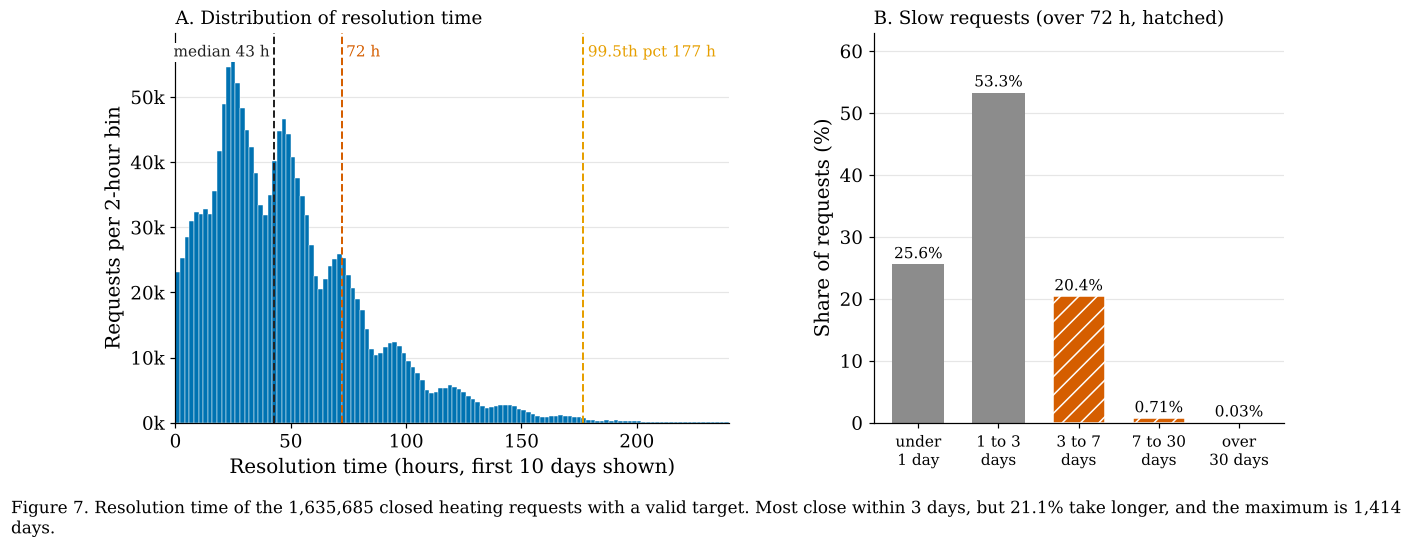

In [72]:
# Figure 7.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.35, 1], "wspace": 0.3})

# Panel A: the body of the distribution, in 2-hour bins, up to 10 days.
ax_a.hist(valid[valid <= 240], bins=np.arange(0, 242, 2), color=BLUE, edgecolor="white", linewidth=0.3)
for x, label, colour, side in [(valid.median(), f"median {valid.median():.0f} h", "#222222", "right"),
                               (72, "72 h", VERMILION, "left"),
                               (P995, f"99.5th pct {P995:.0f} h", ORANGE, "left")]:
    ax_a.axvline(x, color=colour, linestyle="--", linewidth=1.3)
    offset = -2 if side == "right" else 2
    ax_a.text(x + offset, 0.97, label, transform=ax_a.get_xaxis_transform(), fontsize=10, va="top", ha=side, color=colour,
              bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
ax_a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax_a.set_xlim(0, 240)
ax_a.set_xlabel("Resolution time (hours, first 10 days shown)")
ax_a.set_ylabel("Requests per 2-hour bin")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Distribution of resolution time", loc="left", fontsize=12)

# Panel B: share of requests in each duration band.
bands = pd.cut(valid, bins=[-0.001, 24, 72, 168, 720, np.inf],
               labels=["under\n1 day", "1 to 3\ndays", "3 to 7\ndays", "7 to 30\ndays", "over\n30 days"])
band_share = bands.value_counts(normalize=True, sort=False) * 100
band_colours = [GREY, GREY, VERMILION, VERMILION, VERMILION]
bars = ax_b.bar(band_share.index.astype(str), band_share.values, color=band_colours, width=0.65)
for bar, colour in zip(bars, band_colours):
    if colour == VERMILION:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
for bar, value in zip(bars, band_share.values):
    ax_b.text(bar.get_x() + bar.get_width() / 2, value + 1, percent_label(value), ha="center", fontsize=10)
ax_b.set_ylim(0, band_share.max() * 1.18)
ax_b.set_ylabel("Share of requests (%)")
ax_b.tick_params(axis="x", labelsize=10)
ax_b.grid(axis="x", visible=False)
ax_b.set_title("B. Slow requests (over 72 h, hatched)", loc="left", fontsize=12)

add_caption(
    fig,
    f"Figure 7. Resolution time of the {len(valid):,} closed heating requests with a valid target. "
    f"Most close within 3 days, but {band_share.iloc[2:].sum():.1f}% take longer, and the maximum is {valid.max() / 24:,.0f} days.",
)
fig.savefig(FIG_DIR / "07_resolution_time_tail.png")
plt.show()

**Question the figure answers:** *Does a log transformation fix the skew of the target, or does it go too far?*

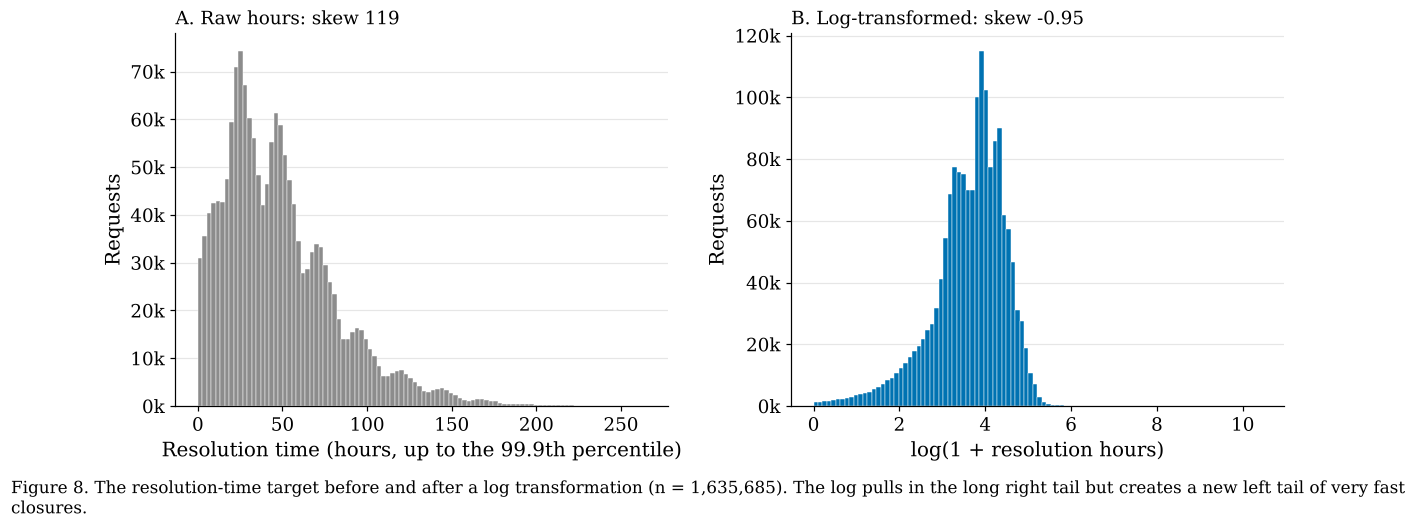

In [73]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.25})

shown = valid[valid <= valid.quantile(0.999)]
ax_a.hist(shown, bins=100, color=GREY, edgecolor="white", linewidth=0.3)
ax_a.set_xlabel("Resolution time (hours, up to the 99.9th percentile)")
ax_a.set_title(f"A. Raw hours: skew {valid.skew():.0f}", loc="left", fontsize=12)

ax_b.hist(np.log1p(valid), bins=100, color=BLUE, edgecolor="white", linewidth=0.3)
ax_b.set_xlabel("log(1 + resolution hours)")
ax_b.set_title(f"B. Log-transformed: skew {np.log1p(valid).skew():.2f}", loc="left", fontsize=12)

for ax in (ax_a, ax_b):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
    ax.set_ylabel("Requests")
    ax.grid(axis="x", visible=False)

add_caption(fig, f"Figure 8. The resolution-time target before and after a log transformation (n = {len(valid):,}). "
                 "The log pulls in the long right tail but creates a new left tail of very fast closures.")
fig.savefig(FIG_DIR / "08_log_transform.png")
plt.show()

**Reading Figure 8.** The raw target has a skew of 119: almost every request sits in the first 200 hours, with a thin tail running out to four years.
The log transform removes that tail but over-corrects: the skew becomes −0.95 and a new left tail appears from requests closed within minutes.
This is why the decision below does not rely on the log alone and uses a 72-hour label or a capped target instead.

**Question the figure answers:** *How far from a normal shape are the capped target and the log1p target?*

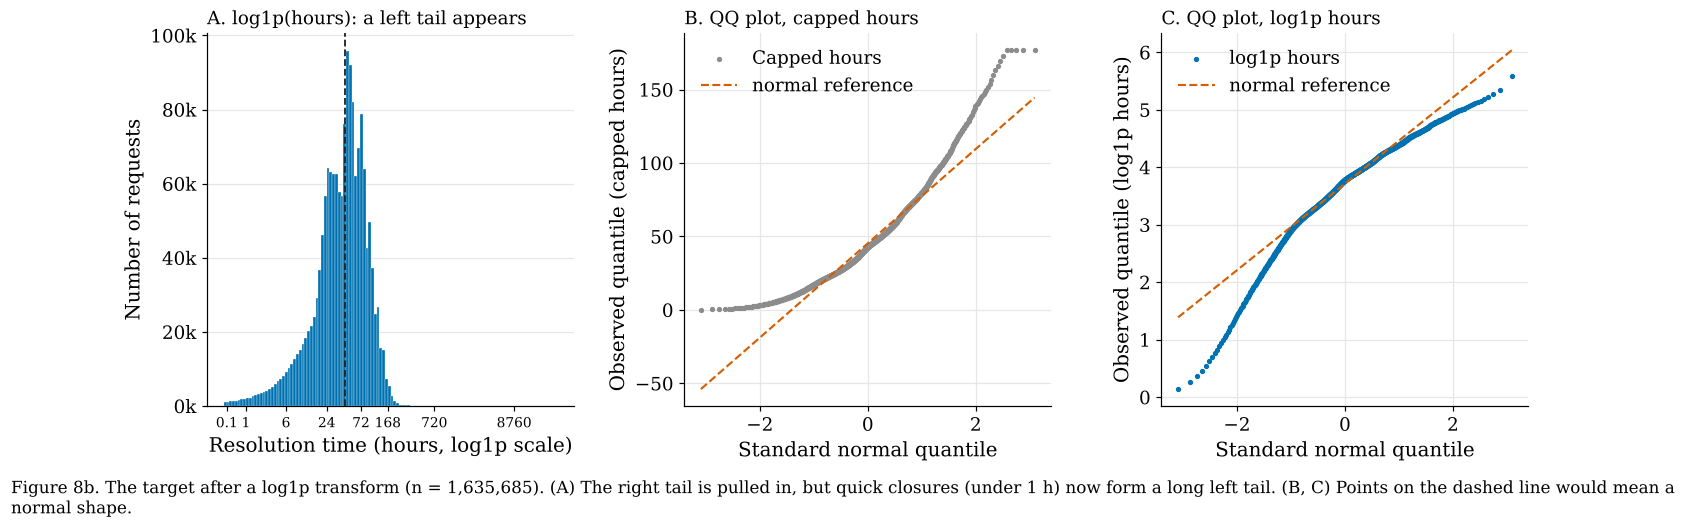

Requests closed in under 1 hour: 0.69%


In [74]:
# Figure 8b. log1p histogram and QQ plots of the target.
from statistics import NormalDist


def qq_points(values, n_points=999):
    """Observed quantiles against standard-normal quantiles, plus the line through the quartiles."""
    probabilities = np.linspace(0.001, 0.999, n_points)
    normal = NormalDist()
    theoretical = np.array([normal.inv_cdf(p) for p in probabilities])
    observed = np.quantile(values, probabilities)
    q1_obs, q3_obs = np.quantile(values, [0.25, 0.75])
    q1_th, q3_th = normal.inv_cdf(0.25), normal.inv_cdf(0.75)
    slope = (q3_obs - q1_obs) / (q3_th - q1_th)
    intercept = q1_obs - slope * q1_th
    return theoretical, observed, slope * theoretical + intercept


valid_hours = valid.to_numpy(dtype=float)   # plain numpy, so the plot works the same on CPU and GPU
capped_hours = np.minimum(valid_hours, float(P995))
log_hours = np.log1p(valid_hours)
HOUR_TICKS = [0.1, 1, 6, 24, 72, 168, 720, 8760]

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(15.5, 4.4), gridspec_kw={"wspace": 0.3})

# Panel A: the target on the log1p scale, with tick labels in hours.
ax_a.hist(log_hours, bins=120, color=BLUE, edgecolor="white", linewidth=0.2)
ax_a.set_xticks(np.log1p(HOUR_TICKS))
ax_a.set_xticklabels(["0.1", "1", "6", "24", "72", "168", "720", "8760"], fontsize=9)
ax_a.axvline(np.log1p(np.median(valid_hours)), color="#222222", linestyle="--", linewidth=1.2)
ax_a.set_xlabel("Resolution time (hours, log1p scale)")
ax_a.set_ylabel("Number of requests")
ax_a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. log1p(hours): a left tail appears", loc="left", fontsize=12)

# Panels B and C: QQ plots of the capped target and of log1p.
for ax, values, label, colour, title in [
    (ax_b, capped_hours, "Capped hours", GREY, "B. QQ plot, capped hours"),
    (ax_c, log_hours, "log1p hours", BLUE, "C. QQ plot, log1p hours"),
]:
    theoretical, observed, reference = qq_points(values)
    ax.scatter(theoretical, observed, s=6, color=colour, label=label)
    ax.plot(theoretical, reference, color=VERMILION, linestyle="--", linewidth=1.4, label="normal reference")
    ax.set_xlabel("Standard normal quantile")
    ax.set_ylabel(f"Observed quantile ({label.lower()})")
    ax.set_title(title, loc="left", fontsize=12)
    ax.legend(loc="upper left")

add_caption(
    fig,
    f"Figure 8b. The target after a log1p transform (n = {len(valid_hours):,}). (A) The right tail is pulled in, but quick closures "
    f"(under 1 h) now form a long left tail. (B, C) Points on the dashed line would mean a normal shape.",
)
fig.savefig(FIG_DIR / "08b_log1p_qq.png")
plt.show()

print(f"Requests closed in under 1 hour: {(valid_hours < 1).mean() * 100:.2f}%")

**Reading Figure 8b.** Neither version of the target is normal. The capped hours bend above the dashed line on the right and flatten at the 177 h cap,
so the right skew is still there. On the log1p scale the middle follows the line, but the 0.69% of requests closed within an hour fall well below it
on the left. This is the left tail Figure 8 showed, and it is why the decision below does not rely on `log1p` alone.

**Decision.**
- **Keep every long value.** Nothing marks them as entry errors, and slow cases are exactly what the project wants to predict.
- **Report medians**, not means: the mean sits about 8 hours above the median, pulled by a few hundred rows.
- **For modelling**, use either `Slow Over 72h` (classification; about 1 request in 5 is slow) or `Resolution Hours Capped`
  (regression, capped at the 99.5th percentile, 177 h; skew falls to about 1.1).
- **Do not rely on `log1p` alone.** It over-corrects: the skew goes from about +119 to about -0.95.

### 7.7 Text and numbers standing in for a missing value

The second disguise of missing data: a value that `isna()` cannot see. The rules below were found by searching every column for `Unspecified`
and checking codes against their valid ranges.

In [75]:
# Each rule marks the values that only pretend to be data.
NYC_ZIP = r"1(0[0-4]|1[0-6])\d\d"
outside_nyc = clean["Latitude"].notna() & ~(clean["Latitude"].between(40.45, 40.95) & clean["Longitude"].between(-74.3, -73.65))

placeholder_rules = {
    "Borough": clean["Borough"] == "Unspecified",
    "Police Precinct": clean["Police Precinct"] == "Unspecified",
    "Community Board": clean["Community Board"].str.contains("Unspecified", na=False),
    "Incident Zip": clean["Incident Zip"].notna() & ~clean["Incident Zip"].str.fullmatch(NYC_ZIP, na=False),
    "BBL": clean["BBL"] == "0000000000",
}

for col, mask in placeholder_rules.items():
    examples = clean.loc[mask, col].value_counts().head(4).to_dict()
    print(f"{col:16s} {int(mask.sum()):>5,} rows   e.g. {examples}")
    clean.loc[mask, col] = np.nan

print(f"{'Latitude/Longitude':16s} {int(outside_nyc.sum()):>5,} rows outside the NYC bounding box")
clean.loc[outside_nyc, ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]] = np.nan

Borough              4 rows   e.g. {'Unspecified': 4}
Police Precinct  2,103 rows   e.g. {'Unspecified': 2103}
Community Board    639 rows   e.g. {'Unspecified BRONX': 238, 'Unspecified QUEENS': 176, 'Unspecified BROOKLYN': 147, 'Unspecified MANHATTAN': 74}
Incident Zip         4 rows   e.g. {'12345': 3, '10803': 1}
BBL                323 rows   e.g. {'0000000000': 323}
Latitude/Longitude     0 rows outside the NYC bounding box


**Decision.** Replace each placeholder with a real blank, so it is counted as missing and never read as a category of its own.
- `Borough` `Unspecified`, `Police Precinct` `Unspecified`, and `Community Board` values such as `Unspecified BRONX` or `0 Unspecified` become blank.
- `Incident Zip` values outside NYC's ranges (`12345`, and `10803` in Westchester) become blank.
- `BBL` `0000000000` is not a real tax lot and becomes blank.
- The coordinate check finds no point outside NYC in this data; it stays in the notebook so a future extract is checked the same way.

No rows were removed. These columns stay well under the 5% line, so the blanks are left as blanks (no imputation).

### 7.8 One ID per building

`BBL` (borough, block and lot) identifies the building, but it is blank in about 0.4% of rows.
Building history is one of the strongest signals in this data (section 7.10), so a missing `BBL` should not erase a building's history.

In [76]:
# BBL where it exists, otherwise the normalised address plus zip code.
def building_id(frame):
    address = frame["Incident Address"].str.upper().str.replace(r"\s+", " ", regex=True).str.strip()
    zip_code = frame["Incident Zip"].where(frame["Incident Zip"].str.fullmatch(NYC_ZIP, na=False), "")
    bbl = frame["BBL"].where(frame["BBL"] != "0000000000")
    return bbl.fillna(address + "|" + zip_code)


clean["Building ID"] = building_id(clean)

per_building = clean["Building ID"].value_counts()
top_1 = per_building.head(int(len(per_building) * 0.01)).sum() / per_building.sum() * 100
top_10 = per_building.head(int(len(per_building) * 0.10)).sum() / per_building.sum() * 100
print(f"BBL blank: {clean['BBL'].isna().sum():,} rows; Building ID blank after the fallback: {clean['Building ID'].isna().sum():,}")
print(f"{len(per_building):,} buildings. The busiest 1% file {top_1:.0f}% of requests, the busiest 10% file {top_10:.0f}%.")

BBL blank: 7,060 rows; Building ID blank after the fallback: 3
95,119 buildings. The busiest 1% file 32% of requests, the busiest 10% file 74%.


**Decision.** Create `Building ID` = `BBL`, or the address and zip code where `BBL` is blank. `BBL` itself is kept unchanged.
Complaints are highly concentrated: a small share of buildings files most of the requests.

### 7.9 `Resolution Description` as an outcome category (EDA only)

`Resolution Description` is one of 43 fixed sentences HPD writes when it closes a request. Grouping them shows *how* requests end.
It is written at closing time, so it is **leakage**: it may be used to explain the data, never as a model feature.

In [77]:
# Map the template sentences to a short outcome label.
OUTCOME_RULES = [  # first match wins
    ("Duplicate of open building-wide complaint", r"duplicate"),
    ("Still open / owner notified", r"still open"),
    ("No access", r"not able to gain access|unable to complete|was not able to gain"),
    ("Violation issued", r"violations were issued|violation was issued|violations were previously issued"),
    ("Heat not required (temp above 55F)", r"not required"),
    ("Restored per tenant/phone", r"restored|verified that the following conditions were corrected|indicated that the condition was corrected|verified that the complaint was addressed"),
    ("Inspected, no violation", r"no violations were issued|did not violate"),
    ("Inspection result on HPDONLINE", r"conducted or attempted to conduct"),
    ("Administrative close", r"administratively"),
]

text = clean["Resolution Description"].fillna("").str.lower()
clean["Outcome (EDA only)"] = np.where(text == "", "Missing", "Other")
for label, pattern in reversed(OUTCOME_RULES):
    clean.loc[text.str.contains(pattern, regex=True), "Outcome (EDA only)"] = label

outcome_table = clean.groupby("Outcome (EDA only)")[TARGET].agg(rows="size", median_hours="median")
outcome_table["share (%)"] = outcome_table["rows"] / len(clean) * 100
outcome_table.sort_values("rows", ascending=False).round(1)

,rows,median_hours,share (%)
Outcome (EDA only),,,
Restored per tenant/phone,583609,42.1,35.7
Duplicate of open building-wide complaint,462554,43.7,28.3
No access,249743,52.7,15.3
Violation issued,157317,51.7,9.6
Inspection result on HPDONLINE,136814,7.7,8.4
"Inspected, no violation",38979,54.9,2.4
Still open / owner notified,4187,74.9,0.3
Missing,1639,28.4,0.1
Administrative close,1026,3.4,0.1


**Decision.** Keep `Outcome (EDA only)` for describing the data and for Tableau views, and exclude it from every model,
together with `Resolution Description` and `Resolution Action Updated Date`.

### 7.10 Workload, building history and time-of-day features

These are known the moment a request is filed, so a model may use them. Counts use **every** heating request except the exact duplicates,
including the open ones dropped in 6.5, because an open complaint still adds to that day's workload and to the building's record.

In [78]:
# The history every count is taken from.
history = heating.loc[~is_duplicate, ["Created Date", "Incident Address", "Incident Zip", "BBL"]].copy()
history["Created Date"] = pd.to_datetime(history["Created Date"], format=DATE_FORMAT)
history["Building ID"] = building_id(history)
history["day"] = history["Created Date"].dt.normalize()
print(f"History: {len(history):,} requests")

clean_day = clean["Created Date"].dt.normalize()

# Calendar.
clean["Created Hour"] = clean["Created Date"].dt.hour
clean["Heat Season"] = ~clean["Created Month"].isin([6, 7, 8, 9])  # NYC heat season is 1 Oct to 31 May
season_start = np.where(clean["Created Month"] >= 10, clean["Created Year"], clean["Created Year"] - 1)
clean["Season"] = np.where(
    clean["Heat Season"],
    pd.Series(season_start).astype(str) + "-" + pd.Series((season_start + 1) % 100).astype(str).str.zfill(2),
    "off-season",
)

# City workload. Heating requests filed citywide on the same day.
daily_volume = history.groupby("day").size()
clean["City Daily Volume"] = clean_day.map(daily_volume).to_numpy()

# Requests from the same building on the same day (a building-wide outage).
same_day = history.groupby(["Building ID", "day"]).size()
clean["Building Same Day"] = same_day.reindex(pd.MultiIndex.from_arrays([clean["Building ID"], clean_day])).to_numpy()

# Requests from the same building in the 365 days before this one.
# Sort (building, time) as one integer key, then count with two binary searches.
known = history["Building ID"].notna()
codes, uniques = pd.factorize(history.loc[known, "Building ID"])
start = pd.Timestamp("2020-01-01")
seconds = lambda s: ((s - start).dt.total_seconds()).astype("int64").to_numpy()
sorted_keys = np.sort(codes.astype("int64") * 10**10 + seconds(history.loc[known, "Created Date"]))

clean_codes = pd.Index(uniques).get_indexer(clean["Building ID"])
query = clean_codes.astype("int64") * 10**10 + seconds(clean["Created Date"])
prior = np.searchsorted(sorted_keys, query, side="left") - np.searchsorted(sorted_keys, query - 365 * 86400, side="left")
clean["Building Prior 365d"] = np.where(clean_codes >= 0, prior, np.nan)

new_features = ["Created Hour", "Heat Season", "Season", "City Daily Volume", "Building Same Day", "Building Prior 365d"]
clean[new_features].describe(include="all").T

History: 1,653,525 requests


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Created Hour,1635869.0,NaN,NaN,NaN,12.915306,6.073579,0.0,9.0,13.0,18.0,23.0
Heat Season,1635869,2,True,1546779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,1635869,9,2025-26,330209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City Daily Volume,1635869.0,NaN,NaN,NaN,1554.610732,1152.061185,34.0,780.0,1288.0,2041.0,6112.0
Building Same Day,1635866.0,NaN,NaN,NaN,3.272182,5.976222,1.0,1.0,1.0,3.0,124.0
Building Prior 365d,1635866.0,NaN,NaN,NaN,113.710858,378.81864,0.0,5.0,19.0,64.0,4178.0


In [79]:
# Does each new feature move the median resolution time?
with_target = clean.dropna(subset=[TARGET])

volume_band = pd.cut(with_target["City Daily Volume"], [0, 500, 1000, 2000, 4000, np.inf],
                     labels=["under 500", "500-1k", "1k-2k", "2k-4k", "over 4k"])
history_band = pd.cut(with_target["Building Prior 365d"], [-1, 0, 4, 19, 99, np.inf],
                      labels=["0", "1-4", "5-19", "20-99", "100+"])

by_volume = with_target.groupby(volume_band, observed=True)[TARGET].agg(rows="size", median_hours="median")
by_history = with_target.groupby(history_band, observed=True)[TARGET].agg(rows="size", median_hours="median")
by_season = with_target.groupby("Heat Season")[TARGET].agg(rows="size", median_hours="median")
pd.concat([by_volume, by_history, by_season], keys=["city daily volume", "building prior 365 days", "heat season"]).round(1)

rows  median_hours
city daily volume       under 500   214376          34.1
                        500-1k      388211          35.9
                        1k-2k       597768          43.4
                        2k-4k       355769          49.9
                        over 4k      79561          66.7
building prior 365 days 0           137241          51.9
                        1-4         270413          49.3
                        5-19        427801          45.8
                        20-99       507204          39.7
                        100+        293023          31.7
heat season             False        89068          40.3
                        True       1546617          43.0

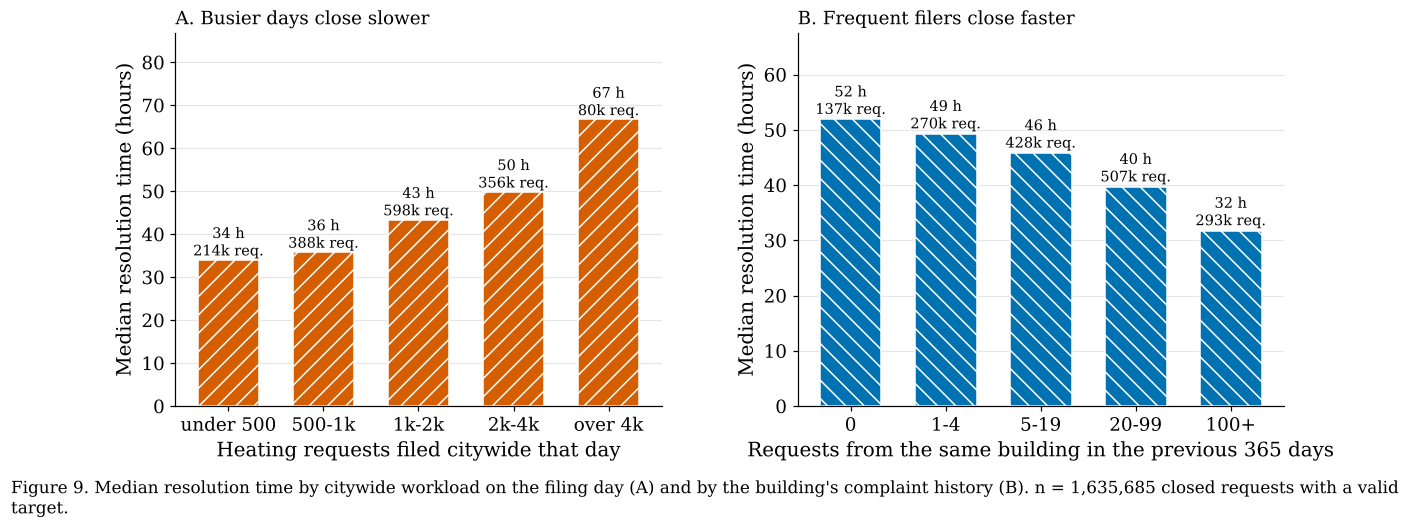

In [80]:
# Figure 9.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.28})

for ax, table, colour, hatch, xlabel, title in [
    (ax_a, by_volume, VERMILION, "//", "Heating requests filed citywide that day", "A. Busier days close slower"),
    (ax_b, by_history, BLUE, "\\\\", "Requests from the same building in the previous 365 days", "B. Frequent filers close faster"),
]:
    labels = table.index.astype(str)
    bars = ax.bar(labels, table["median_hours"], color=colour, hatch=hatch, edgecolor="white", width=0.65)
    for bar, (value, rows) in zip(bars, table[["median_hours", "rows"]].to_numpy()):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.0f} h\n{rows / 1000:,.0f}k req.", ha="center", fontsize=9.5)
    ax.set_ylim(0, table["median_hours"].max() * 1.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Median resolution time (hours)")
    ax.grid(axis="x", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(
    fig,
    "Figure 9. Median resolution time by citywide workload on the filing day (A) and by the building's complaint history (B). "
    f"n = {len(with_target):,} closed requests with a valid target.",
)
fig.savefig(FIG_DIR / "09_workload_and_history.png")
plt.show()

**Reading Figure 9.**
- **(A) Workload.** On quiet days the median is in the low-to-mid 30s of hours; on days with more than 4,000 heating requests it roughly doubles.
  HPD's capacity, not the individual request, sets much of the waiting time.
- **(B) History.** Buildings that complained 100+ times in the previous year close faster than buildings with no history.
  A likely reason (inferred, not tested): repeat buildings often already have an open building-wide complaint, and 28% of all requests close as a duplicate of one (7.9).

**Change made: 6 columns created** (`Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d`).
Hour of day and the heat-season flag each show a weak signal alone (section 7.2); they are created here so a tree model can use them together with workload. `Season` groups October to May across the new year (for example `2023-24`), which `Created Year` splits in two,
and it is the natural unit for a time-based train/test split. No rows were removed.

### 7.11 Weather (next step, not added yet)

The heat-season rule says landlords must heat when it is below 55°F in the day or at any temperature at night, so cold days
should bring more complaints and a heavier HPD workload. The next step is to join **NOAA GHCN-Daily minimum temperature for Central Park
(station USW00094728)** on the request's created date. It needs an outside download, so it is listed under "Not yet decided".

## 8. Shape of the cleaned dataset (so far)

In [81]:
print(f"Raw file:           22,671,531 rows x 44 columns")
print(f"Heating only:       {heating.shape[0]:,} rows x {heating.shape[1]} columns")
print(f"Cleaned so far:     {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Rows removed since filtering to heating: {heating.shape[0] - clean.shape[0]:,} "
      f"({n_duplicates:,} duplicates + {n_open_dropped:,} open requests + {n_status_dropped} with Status not 'Closed')")
print(f"Rows with a usable target (modelling set): {clean[TARGET].notna().sum():,}")

Raw file:           22,671,531 rows x 44 columns
Heating only:       1,656,653 rows x 44 columns
Cleaned so far:     1,635,869 rows x 36 columns
Rows removed since filtering to heating: 20,784 (3,128 duplicates + 17,654 open requests + 2 with Status not 'Closed')
Rows with a usable target (modelling set): 1,635,685


In [82]:
shape_summary = pd.DataFrame(
    {
        "dtype": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "distinct values": clean.nunique(),
    }
)
shape_summary.index.name = "column"
shape_summary

,dtype,missing rows,distinct values
column,,,
Created Date,datetime64[ns],0,1558682
Closed Date,datetime64[ns],0,553427
Problem Detail (formerly Descriptor),object,1,2
Additional Details,object,0,4
Incident Zip,object,190,207
Incident Address,object,3,99807
Street Name,object,3,5034
City,object,148,89
Resolution Description,object,1639,41


### How the columns got from 44 to 36

| Step | Columns | Change |
|---|---|---|
| Heating only (section 2) | 44 | start |
| ID dropped (4.1) | 43 | -1: `Unique Key` |
| Single-value columns (4.3) | 39 | -4: `Agency`, `Agency Name`, `Park Facility Name`, `Problem` |
| Copy columns (4.4) | 36 | -3: `Intersection Street 1`, `Intersection Street 2`, `Park Borough` |
| `Address Type`, `Location`, `Location Type` (4.5 to 4.7) | 33 | -3 |
| Completely empty (6.2) | 24 | -9 |
| Over 30% missing (6.3) | 21 | -3: `Cross Street 1`, `Cross Street 2`, `Landmark` |
| Open requests dropped (6.5) | 21 | no column change; 17,654 rows removed |
| Resolution time created (7.1) | 22 | +1: `Resolution Hours` |
| Calendar fields created (7.2) | 25 | +3: `Created Year`, `Created Month`, `Created Weekday` |
| Case variants unified (7.3) | 25 | no column change |
| `Status` checked against `Closed Date` (7.4) | 24 | -1: `Status`; 2 rows removed |
| Negative and zero targets (7.5) | 26 | +2: `Is Negative Duration`, `Is Instant Close` |
| Long tail (7.6) | 28 | +2: `Slow Over 72h`, `Resolution Hours Capped` |
| Placeholders to blank (7.7) | 28 | no column change |
| Building ID (7.8) | 29 | +1: `Building ID` |
| Outcome category (7.9) | 30 | +1: `Outcome (EDA only)` |
| Workload, history, calendar (7.10) | 36 | +6: `Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d` |

Rows went from 1,656,653 to 1,635,869 (3,128 exact duplicates, 17,654 open requests and 2 requests whose `Status` was not `Closed` removed).
184 of those rows have a blank target, so the modelling set is 1,635,685 rows. Still to do: the weather join and the final choice of target form (see "Not yet decided").

## 9. Decision table: every cleaning change

The output of the cleaning is a table of decisions: for each column or issue, what was decided and why.
This table covers every change made so far, in the order it was made, so a reader can pick up the data without asking the authors anything.

| Column / issue | Decision | Because |
|---|---|---|
| Rows from the 260 other complaint categories | keep only `HEAT/HOT WATER`; 22,671,531 rows down to 1,656,653 | the project predicts heating resolution time only; other categories have other agencies and processes. Matching on the upper-cased label keeps the 1,814 rows spelled `Heat/Hot Water`. |
| `Unique Key` | drop the column | a row ID; it also made `duplicated()` return 0 (3,128 without it) |
| Duplicate rows | drop 3,128 exact copies, keep the first | only visible once the ID was removed; 70% came from the mobile app (double-taps); the target distribution did not move |
| `Agency`, `Agency Name`, `Park Facility Name`, `Problem` | drop 4 columns | one value in every row (`Problem` had two spellings but one value once upper-cased) |
| `Intersection Street 1`, `Intersection Street 2`, `Park Borough` | drop 3 columns | identical to `Cross Street 1`, `Cross Street 2` and `Borough` in all 1,653,525 rows |
| `Address Type` | drop the column | `ADDRESS` in 1,653,522 of 1,653,525 rows (99.9998%) |
| `Location` | drop the column | the text `POINT (lon lat)`; equals `Longitude` and `Latitude` to within 5e-12 degrees |
| `Location Type` | drop the column | `RESIDENTIAL BUILDING` in 99.89% of rows; in the rest it only repeats `Problem Detail` |
| `Latitude`, `Longitude`, `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | strip thousands commas, cast to float64 | stored as text, so `describe()` skipped them (0 numeric columns before, 4 after) |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | cast to datetime64 with the exact format | stored as text; text dates sort alphabetically, and the target cannot be computed from text |
| `Incident Zip`, `Council District`, `BBL` | keep as text | labels for a place, not measurements; `Council District` has leading zeros |
| 9 empty columns (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`, `Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`) | drop | 100% missing; leftovers from other 311 complaint types |
| `Cross Street 1`, `Cross Street 2`, `Landmark` | drop | 99.89% missing (over the 30% rule); filled only for requests created 10 Aug to 6 Oct 2023 |
| 17,654 requests with no `Closed Date` | drop the rows | the target is missing, and a target is never imputed. All are `Open` or `In Progress`. 12,212 are from 2026, so the drop removes slow-to-close requests, and borough and problem-type mix barely move. Section 7.4 removes 2 more, so 17,656 in total. |
| Resolution time | create `Resolution Hours` = `Closed Date` minus `Created Date`, in hours | it is the target; median 42.8 h, mean 50.9 h, long right tail |
| Seasonality and time trend | create `Created Year`, `Created Month`, `Created Weekday` from `Created Date` | median resolution time varies with each: Friday and Saturday about 16 h slower than Tuesday; March to May fastest; year shifts (36 h in 2024, 49 h in 2021) |
| `Problem Detail`, `Additional Details` | upper-case and trim to one spelling; the one `Water Supply` value becomes blank | HPD used Title case only for requests created 10 Aug to 6 Oct 2023, so each category was counted twice |
| `Status` vs `Closed Date` | closed = `Status` is `Closed` AND a `Closed Date` exists; drop the 2 `Unspecified` rows that have a date; drop `Status` | nothing confirms those 2 were closed; `Status` is then one value, and it is only known after resolution |
| 184 negative `Resolution Hours` | set to blank, flag `Is Negative Duration`, exclude from the target | closed before created; none is within a minute of zero, so it is not clock noise |
| 107 zero `Resolution Hours` | keep, flag `Is Instant Close` | 0.007% of rows, too few to matter, and not shown to be errors |
| Long tail (443 rows over 30 days, max about 3.9 years, skew about 119) | keep every row; report medians; add `Slow Over 72h` and `Resolution Hours Capped` (99.5th percentile) | the values are real complaints, but a few hundred of them pull the mean |
| `log1p` of the target | do not use it alone | it over-corrects the skew (about -0.95) |
| `Borough`, `Police Precinct`, `Community Board` `Unspecified`; zips outside NYC; `BBL` `0000000000`; coordinates outside NYC | set to blank | text and codes standing in for a missing value (no coordinate is outside NYC in this extract) |
| Missing `BBL` (about 0.4%) | create `Building ID` = `BBL`, else address + zip | keeps each building's complaint history |
| `Resolution Description` | map the template sentences to `Outcome (EDA only)`; never a model feature | it is written at closing time, so it is leakage |
| New features | create `Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d` | workload and building history are the strongest signals found (Figure 9) |
| Weather | join NOAA daily minimum temperature next | cold days are the likely driver of workload |
| Modelling set | 1,635,685 rows | 1,656,653 − 3,128 duplicates − 17,656 open or unconfirmed − 184 negative targets |

In [83]:
DROPPED_FROM_RAW = {
    "Unique Key",
    "Agency", "Agency Name", "Park Facility Name", "Problem (formerly Complaint Type)",
    "Intersection Street 1", "Intersection Street 2", "Park Borough",
    "Address Type", "Location", "Location Type",
    "Facility Type", "Due Date", "Vehicle Type", "Taxi Company Borough", "Taxi Pick Up Location",
    "Bridge Highway Name", "Bridge Highway Direction", "Road Ramp", "Bridge Highway Segment",
    "Cross Street 1", "Cross Street 2", "Landmark",
    "Status",  # dropped in 7.4
}
CREATED = {
    "Resolution Hours", "Created Year", "Created Month", "Created Weekday",
    # created in 7.5 to 7.10
    "Is Negative Duration", "Is Instant Close", "Slow Over 72h", "Resolution Hours Capped",
    "Building ID", "Outcome (EDA only)",
    "Created Hour", "Heat Season", "Season", "City Daily Volume", "Building Same Day", "Building Prior 365d",
}

actually_dropped = set(heating.columns) - set(clean.columns)
actually_created = set(clean.columns) - set(heating.columns)

# The table above must match what the notebook really did.
assert actually_dropped == DROPPED_FROM_RAW
assert actually_created == CREATED
# The row counts in the table must match too.
assert len(clean) == heating.shape[0] - n_duplicates - n_open_dropped - n_status_dropped == 1_635_869
assert clean[TARGET].notna().sum() == 1_635_685

print(f"Columns dropped: {len(actually_dropped)}    Columns created: {len(actually_created)}")
print(f"Columns: {heating.shape[1]} - {len(actually_dropped)} + {len(actually_created)} = {clean.shape[1]}")
print(f"Rows: {heating.shape[0]:,} - {n_duplicates:,} duplicates - {n_open_dropped:,} open requests "
      f"- {n_status_dropped} unconfirmed = {clean.shape[0]:,}")
print(f"Modelling rows (valid target): {clean[TARGET].notna().sum():,}")

Columns dropped: 24    Columns created: 16
Columns: 44 - 24 + 16 = 36
Rows: 1,656,653 - 3,128 duplicates - 17,654 open requests - 2 unconfirmed = 1,635,869
Modelling rows (valid target): 1,635,685


**Question the figure answers:** *How many rows does each duplicate and target rule touch?*

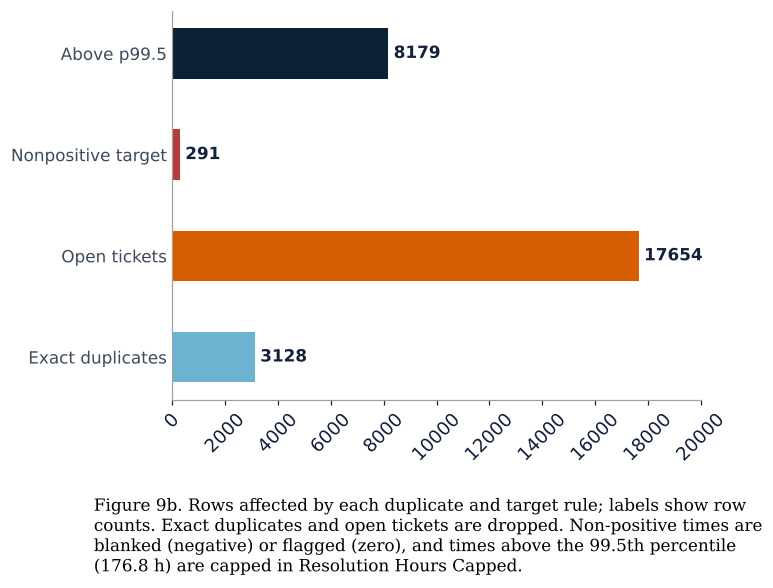

In [84]:
# Figure 9b. Rows affected by each duplicate and target rule.
SLIDE_FONT = {"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]}

is_negative = clean["Is Negative Duration"].fillna(False).astype(bool)
is_zero = clean["Is Instant Close"].fillna(False).astype(bool)
removal_counts = {   # top to bottom, as on the slide
    "Above p99.5": int((valid > P995).sum()),
    "Nonpositive target": int(is_negative.sum()) + int(is_zero.sum()),
    "Open tickets": int(n_open_dropped),
    "Exact duplicates": int(n_duplicates),
}
removal_colours = ["#0B2135", "#B83B3B", VERMILION, "#6BB3D1"]

with plt.rc_context(SLIDE_FONT):
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    labels = list(removal_counts)[::-1]          # barh draws bottom first
    counts = [removal_counts[k] for k in labels]
    colours = removal_colours[::-1]
    bars = ax.barh(labels, counts, color=colours, height=0.5)
    for bar, count in zip(bars, counts):
        ax.text(count + 200, bar.get_y() + bar.get_height() / 2, f"{count}", va="center", ha="left",
                fontsize=11, fontweight="bold", color="#14213D")
    upper = int(np.ceil(max(counts) * 1.1 / 2000) * 2000)
    ax.set_xlim(0, upper)
    ax.set_xticks(range(0, upper + 1, 2000))
    ax.tick_params(axis="x", labelrotation=45, labelsize=12, colors="#14213D")
    ax.tick_params(axis="y", length=0, labelsize=11, colors="#3C4A5A")
    ax.grid(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#A0A0A0")

add_caption(fig, f"Figure 9b. Rows affected by each duplicate and target rule; labels show row counts. Exact duplicates and open tickets "
                 f"are dropped. Non-positive times are blanked (negative) or flagged (zero), and times above the 99.5th percentile "
                 f"({P995:.1f} h) are capped in Resolution Hours Capped.", y=-0.08)
fig.savefig(FIG_DIR / "09b_cleaning_removals.png")
plt.show()

**Reading Figure 9b.** Open tickets are the largest group (17,654), followed by the 8,179 values above the 99.5th percentile, the 3,128 exact
duplicates and 291 non-positive times (184 negative, 107 zero). Only the duplicates and the open tickets (plus the 2 unconfirmed closures from 7.4) leave
the dataset. The rest stay as rows: negative times lose their target, zero times are flagged, and long times are capped only in `Resolution Hours Capped`.

### Not yet decided

The table above is complete for the cleaning done in this notebook. These items are still open:

| Column / issue | Why it is open |
|---|---|
| Weather | NOAA daily minimum temperature still has to be downloaded and joined on the created date (7.11) |
| Final target form | classification on `Slow Over 72h` is proposed in section 14; regression on `Resolution Hours Capped` is the alternative |
| Remaining small gaps (`Incident Zip`, `Council District`, `Police Precinct`, coordinates, under 0.2% each) | left blank for now; simple imputation is allowed under 5% if a model needs complete rows |
| `Closed Date`, `Resolution Description`, `Resolution Action Updated Date`, `Outcome (EDA only)` | only known after resolution, so they must not be model features |

## 10. What drives resolution time

**Question this section answers:** *Which properties of a request, known when it is filed, go with a fast or a slow resolution?*

Every figure uses the cleaned requests with a valid target (`eda` below). Medians are used throughout, because the long tail pulls the mean (section 7.6).
Figures 7 and 9 in section 7 already cover the distribution of the target, citywide workload and building history.

In [85]:
eda = clean.dropna(subset=[TARGET]).copy()
eda["Slow"] = eda["Slow Over 72h"].astype(bool)
print(f"{len(eda):,} requests, median {eda[TARGET].median():.1f} h, {eda['Slow'].mean() * 100:.1f}% slower than 72 h")

1,635,685 requests, median 42.8 h, 21.1% slower than 72 h


### 10.1 Borough

**Question the figure answers:** *Does the borough change how long a request takes?*

In [86]:
by_borough = eda.groupby("Borough")[[TARGET, "Slow"]].agg({TARGET: "median", "Slow": "mean"})
by_borough["rows"] = eda.groupby("Borough").size()
by_borough["Slow"] *= 100
by_borough = by_borough.sort_values(TARGET)
by_borough.round(1)

column,Resolution Hours,Slow,rows
Borough,,,
BRONX,36.5,14.6,579430
BROOKLYN,45.4,24.2,441347
STATEN ISLAND,45.9,25.1,18334
MANHATTAN,45.9,24.3,377307
QUEENS,46.9,26.4,219260


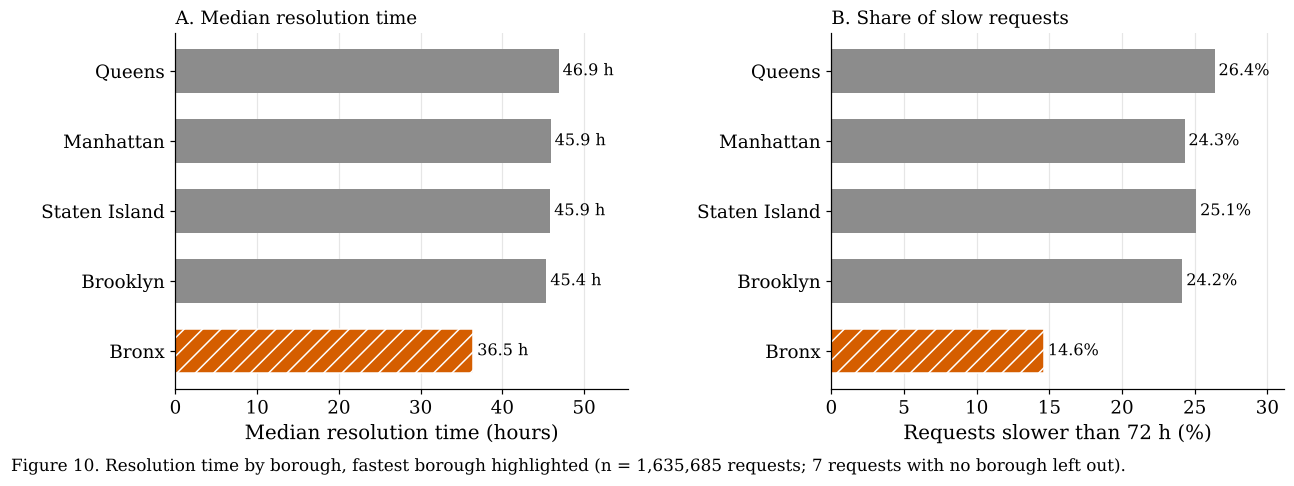

In [87]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"wspace": 0.45})
fastest = by_borough.index[0]

for ax, col, fmt, xlabel, title in [
    (ax_a, TARGET, "{:.1f} h", "Median resolution time (hours)", "A. Median resolution time"),
    (ax_b, "Slow", "{:.1f}%", "Requests slower than 72 h (%)", "B. Share of slow requests"),
]:
    values = by_borough[col]
    colours = [VERMILION if b == fastest else GREY for b in values.index]
    bars = ax.barh([b.title() for b in values.index], values, color=colours, height=0.62)
    bars[0].set_hatch("//")
    bars[0].set_edgecolor("white")
    for bar, value in zip(bars, values):
        ax.text(value + values.max() * 0.01, bar.get_y() + bar.get_height() / 2, fmt.format(value), va="center", fontsize=10.5)
    ax.set_xlim(0, values.max() * 1.18)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(fig, f"Figure 10. Resolution time by borough, fastest borough highlighted (n = {len(eda):,} requests; "
                 f"{eda['Borough'].isna().sum()} requests with no borough left out).")
fig.savefig(FIG_DIR / "10_borough.png")
plt.show()

**Reading Figure 10.** The Bronx is the clear exception. Its median is 36.5 h and only 14.6% of its requests take longer than 72 h,
while the other four boroughs sit close together at 45 to 47 h and 24 to 26% slow. The Bronx is also the borough with the most requests (579,430),
so being busy does not slow a borough down on its own. Borough is worth keeping as a feature, and a Bronx flag captures most of its effect.

**Question the figure answers:** *Does the borough with the most requests also have the slowest median?*

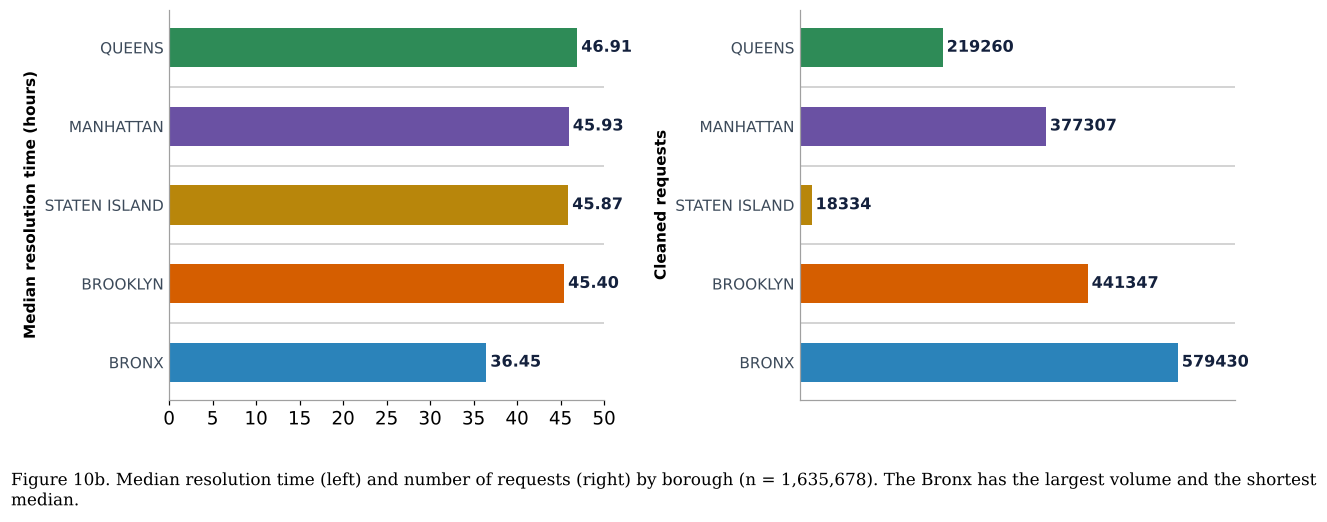

In [88]:
# Figure 10b. Median resolution time and request volume by borough.
SLIDE_FONT = {"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]}
SLIDE_BOROUGH_COLOURS = {"QUEENS": "#2E8B57", "MANHATTAN": "#6A51A3", "STATEN ISLAND": "#B8860B",
                         "BROOKLYN": VERMILION, "BRONX": "#2B83BA"}

boroughs = [str(b) for b in by_borough.index.to_list()]           # fastest first, so barh puts it at the bottom
medians = [float(v) for v in by_borough[TARGET].to_list()]
volumes = [int(v) for v in by_borough["rows"].to_list()]
colours = [SLIDE_BOROUGH_COLOURS[b] for b in boroughs]

with plt.rc_context(SLIDE_FONT):
    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"wspace": 0.45})
    for ax, values, fmt, ylabel in [
        (ax_a, medians, "{:.2f}", "Median resolution time (hours)"),
        (ax_b, volumes, "{:d}", "Cleaned requests"),
    ]:
        bars = ax.barh(boroughs, values, color=colours, height=0.5)
        for bar, value in zip(bars, values):
            ax.text(value + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, fmt.format(value),
                    va="center", ha="left", fontsize=10.5, fontweight="bold", color="#14213D")
        for y in np.arange(0.5, len(boroughs) - 0.5):           # thin separators between the bars
            ax.axhline(y, color="#C8C8C8", linewidth=1)
        ax.set_ylabel(ylabel, fontweight="bold", fontsize=10)
        ax.tick_params(axis="y", length=0, labelsize=10, colors="#3C4A5A")
        ax.grid(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color("#A0A0A0")
    ax_a.set_xlim(0, 50)
    ax_a.set_xticks(range(0, 51, 5))
    ax_b.set_xlim(0, max(volumes) * 1.15)
    ax_b.set_xticks([])

add_caption(fig, f"Figure 10b. Median resolution time (left) and number of requests (right) by borough (n = {sum(volumes):,}). "
                 f"The Bronx has the largest volume and the shortest median.", y=-0.03)
fig.savefig(FIG_DIR / "10b_borough_median_and_volume.png")
plt.show()

**Reading Figure 10b.** The Bronx files the most heating requests (579,430) and still has the shortest median (36.5 h). Staten Island files the fewest
(18,334) but is as slow as Queens, Manhattan and Brooklyn. Request volume alone does not explain how fast a borough closes its requests.

### 10.2 Day of the week and hour of the day

**Question the figure answers:** *When during the week is a request filed if it is going to wait longest?*

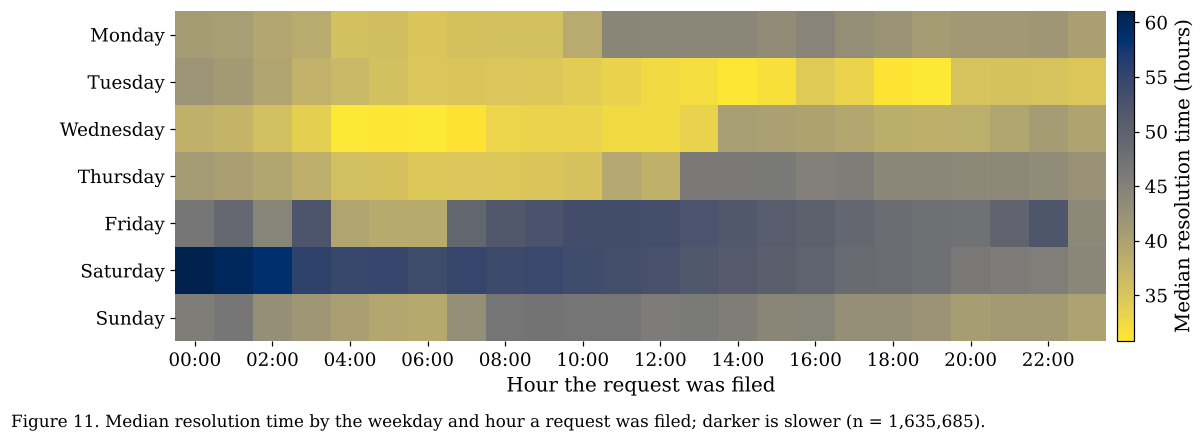

Created Weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
min,35.0,30.8,30.8,34.7,38.7,44.0,38.9
max,44.3,41.9,40.8,46.4,53.7,61.0,47.1


In [89]:
weekday_hour = eda.pivot_table(index="Created Weekday", columns="Created Hour", values=TARGET, aggfunc="median").reindex(WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(13, 3.9))
image = ax.imshow(weekday_hour.values, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAY_ORDER)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour the request was filed")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(image, ax=ax, pad=0.01)
bar.set_label("Median resolution time (hours)")

add_caption(fig, f"Figure 11. Median resolution time by the weekday and hour a request was filed; darker is slower (n = {len(eda):,}).", y=-0.06)
fig.savefig(FIG_DIR / "11_weekday_hour.png")
plt.show()

weekday_hour.agg(["min", "max"], axis=1).round(1).T

**Reading Figure 11.** Requests filed on Tuesday and Wednesday close fastest (about 31 h at best), and those filed late on Friday and on Saturday wait longest
(up to about 61 h for Saturday just after midnight). A likely reason, not tested here, is that a request filed just before the weekend waits for
weekday inspection staff. The weekday matters far more than the hour: within a single day the median moves by about 10 to 17 hours.

**Question the figure answers:** *When are requests submitted most frequently?*

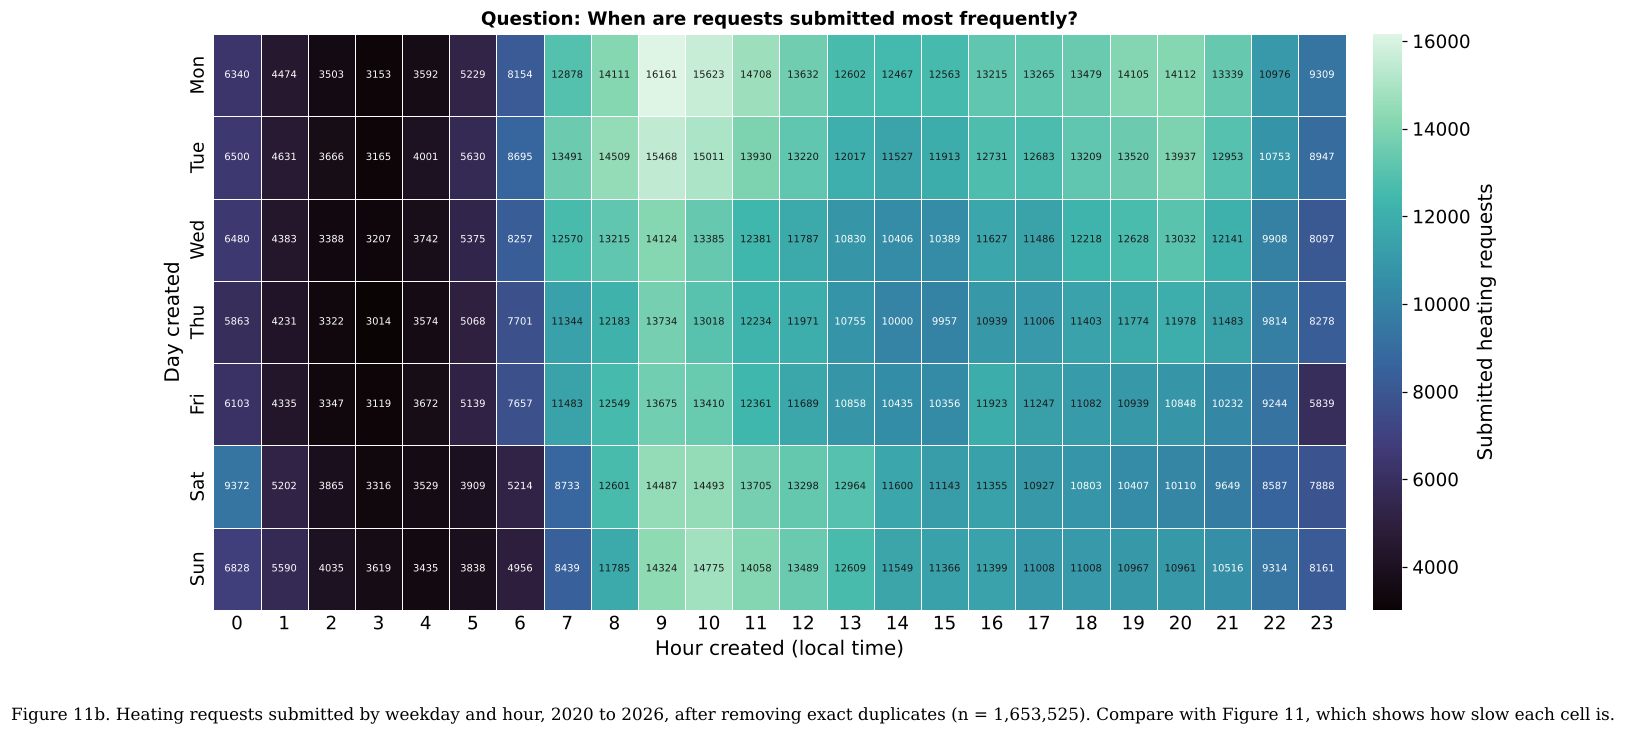

Busiest:  Monday 09:00, 16,161 requests
Quietest: Thursday 03:00, 3,014 requests


In [90]:
# Figure 11b. When heating requests are submitted, by weekday and hour.
from matplotlib.colors import LinearSegmentedColormap

SLIDE_FONT = {"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]}
MAKO = LinearSegmentedColormap.from_list(  # the "mako" palette, so seaborn is not needed
    "mako", ["#0B0405", "#2E1E3C", "#413D7B", "#37659E", "#348FA7", "#40B7AD", "#8AD9B1", "#DEF5E5"])

created = history["Created Date"]
submissions = (
    history.groupby([created.dt.dayofweek.rename("weekday"), created.dt.hour.rename("hour")])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)
grid = submissions.to_numpy(dtype=float)   # plain numpy, so the plot works the same on CPU and GPU
DAY_SHORT = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

with plt.rc_context(SLIDE_FONT):
    fig, ax = plt.subplots(figsize=(16, 6.8))
    mesh = ax.pcolormesh(grid, cmap=MAKO, edgecolors="white", linewidth=0.5)
    ax.invert_yaxis()
    low, high = grid.min(), grid.max()
    for row in range(7):
        for col in range(24):
            value = grid[row, col]
            shade = (value - low) / (high - low)
            ax.text(col + 0.5, row + 0.5, f"{int(value)}", ha="center", va="center", fontsize=6.5,
                    color="#1A1A1A" if shade > 0.6 else "white")
    ax.set_xticks(np.arange(24) + 0.5)
    ax.set_xticklabels([str(h) for h in range(24)])
    ax.set_yticks(np.arange(7) + 0.5)
    ax.set_yticklabels(DAY_SHORT, rotation=90, va="center")
    ax.tick_params(length=0)
    ax.set_xlabel("Hour created (local time)")
    ax.set_ylabel("Day created")
    ax.set_title("Question: When are requests submitted most frequently?", fontweight="bold", fontsize=12)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    colour_bar = fig.colorbar(mesh, ax=ax, pad=0.02)
    colour_bar.set_label("Submitted heating requests")
    colour_bar.outline.set_visible(False)

add_caption(fig, f"Figure 11b. Heating requests submitted by weekday and hour, 2020 to 2026, after removing exact duplicates "
                 f"(n = {int(grid.sum()):,}). Compare with Figure 11, which shows how slow each cell is.", y=-0.02)
fig.savefig(FIG_DIR / "11b_submissions_weekday_hour.png")
plt.show()

busiest = np.unravel_index(grid.argmax(), grid.shape)
quietest = np.unravel_index(grid.argmin(), grid.shape)
print(f"Busiest:  {WEEKDAY_ORDER[busiest[0]]} {busiest[1]:02d}:00, {int(grid.max()):,} requests")
print(f"Quietest: {WEEKDAY_ORDER[quietest[0]]} {quietest[1]:02d}:00, {int(grid.min()):,} requests")

**Reading Figure 11b.** Submissions peak on Monday and Tuesday mornings: Monday at 09:00 is the busiest cell (16,161 requests), and both days stay
above 15,000 from 09:00 to 10:00. The quietest hour is around 03:00 (about 3,000 requests on weekdays). Monday morning absorbs the weekend's backlog,
which tells the agency when intake coverage matters most. The busiest cells are not the slowest ones in Figure 11, which peak on Friday and Saturday.

**Question the figure answers:** *Does the time of year change which hours of the day are slow?*

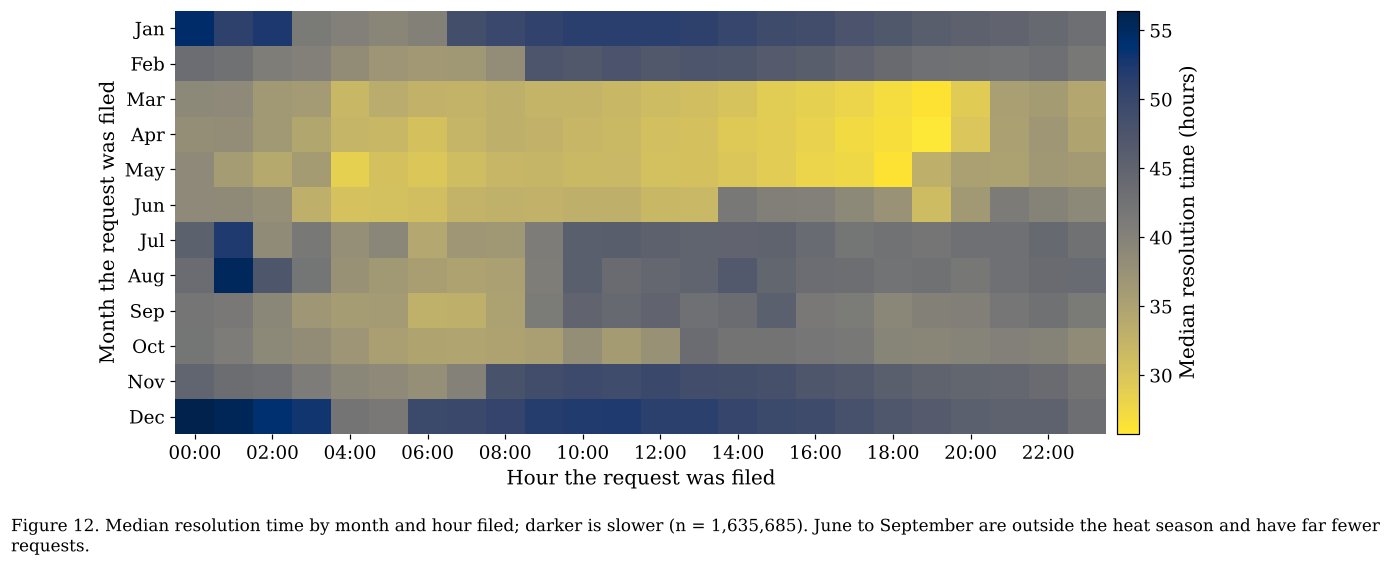

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
min,39.4,36.3,26.3,25.7,26.3,30.5,34.2,34.9,32.9,34.6,37.9,41.5
max,54.5,47.7,38.9,38.1,38.8,41.6,52.1,55.3,45.6,43.6,49.6,56.4


In [91]:
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_hour = eda.pivot_table(index="Created Month", columns="Created Hour", values=TARGET, aggfunc="median").reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(13, 5))
image = ax.imshow(month_hour.values, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(12))
ax.set_yticklabels(MONTH_NAMES)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour the request was filed")
ax.set_ylabel("Month the request was filed")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, pad=0.01).set_label("Median resolution time (hours)")

add_caption(fig, f"Figure 12. Median resolution time by month and hour filed; darker is slower (n = {len(eda):,}). "
                 "June to September are outside the heat season and have far fewer requests.", y=-0.04)
fig.savefig(FIG_DIR / "12_month_hour.png")
plt.show()
month_hour.agg(["min", "max"], axis=1).round(1).set_axis(MONTH_NAMES).T

**Reading Figure 12.** The month sets the level more than the hour does. Requests filed from March to May close fastest at every hour (medians as low as about 26 hours),
while December and January are the slowest months, reaching 54 to 56 hours for requests filed just after midnight. June to September look noisy because few heating requests are filed then.
Month and hour interact (the slow overnight band appears only in winter), which again points to a tree-based model.

### 10.3 Over time

**Question the figure answers:** *Does resolution time rise and fall with the number of complaints from season to season?*

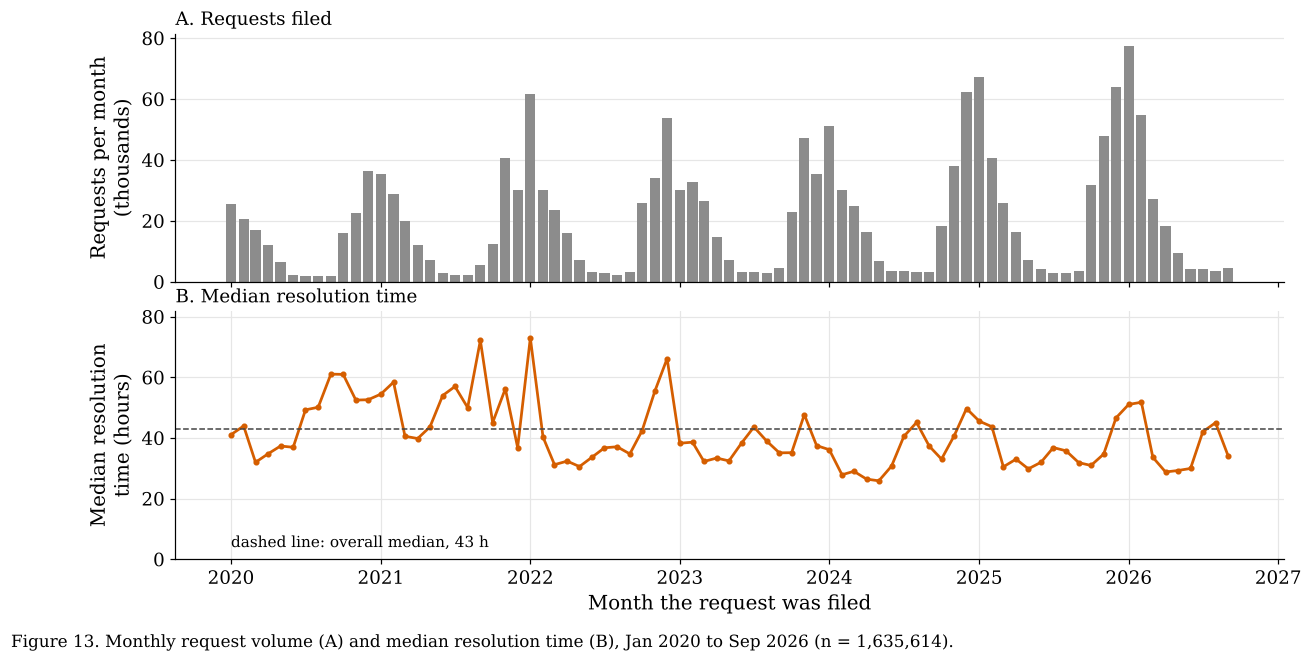

Correlation of monthly volume with monthly median time: 0.30


,median hours,requests
Created Date,,
2022-01-01,72.9,61784
2021-09-01,72.2,5329
2022-12-01,66.2,53686
2020-09-01,61.0,1921
2020-10-01,61.0,15928


In [92]:
monthly = eda.set_index("Created Date").resample("MS").agg({TARGET: "median", "Slow": "size"})
monthly.columns = ["median hours", "requests"]
monthly = monthly[(monthly["requests"] > 0) & (monthly.index < "2026-10-01")]  # the data stops on 1 Oct 2026

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True, gridspec_kw={"hspace": 0.12})
ax_a.bar(monthly.index, monthly["requests"] / 1000, width=25, color=GREY)
ax_a.set_ylabel("Requests per month\n(thousands)")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Requests filed", loc="left", fontsize=12)

ax_b.plot(monthly.index, monthly["median hours"], color=VERMILION, linewidth=1.8, marker="o", markersize=3)
ax_b.axhline(eda[TARGET].median(), color="#444444", linestyle="--", linewidth=1)
ax_b.text(monthly.index[0], 4, f"dashed line: overall median, {eda[TARGET].median():.0f} h", fontsize=10)
ax_b.set_ylim(0, monthly["median hours"].max() * 1.12)
ax_b.set_ylabel("Median resolution\ntime (hours)")
ax_b.set_xlabel("Month the request was filed")
ax_b.set_title("B. Median resolution time", loc="left", fontsize=12)

add_caption(fig, f"Figure 13. Monthly request volume (A) and median resolution time (B), Jan 2020 to Sep 2026 (n = {int(monthly["requests"].sum()):,}).", y=0.0)
fig.savefig(FIG_DIR / "13_monthly_trend.png")
plt.show()

print(f"Correlation of monthly volume with monthly median time: {monthly['requests'].corr(monthly['median hours']):.2f}")
monthly.sort_values("median hours", ascending=False).head(5).round(1)

**Reading Figure 13.** Complaints follow the heat season every year, from about 2,000 a month in summer to a peak of about 77,000 in January 2026.
Resolution time rises with the busiest winters (72.9 h in January 2022 and 66.2 h in December 2022), but the monthly correlation with volume is only 0.30,
because summer months with few requests give noisy medians (for example 72.2 h in September 2021 from 5,329 requests). Since 2023 the medians have mostly stayed
between 25 and 52 h. October 2026 is left out because the data stops on 1 October. The shift between years supports a time-based train/test split.

**Question the figure answers:** *Did every borough follow the same rise and fall from month to month?* Months with fewer than 200
requests in a borough are left out, so summer medians do not swing on a handful of requests.

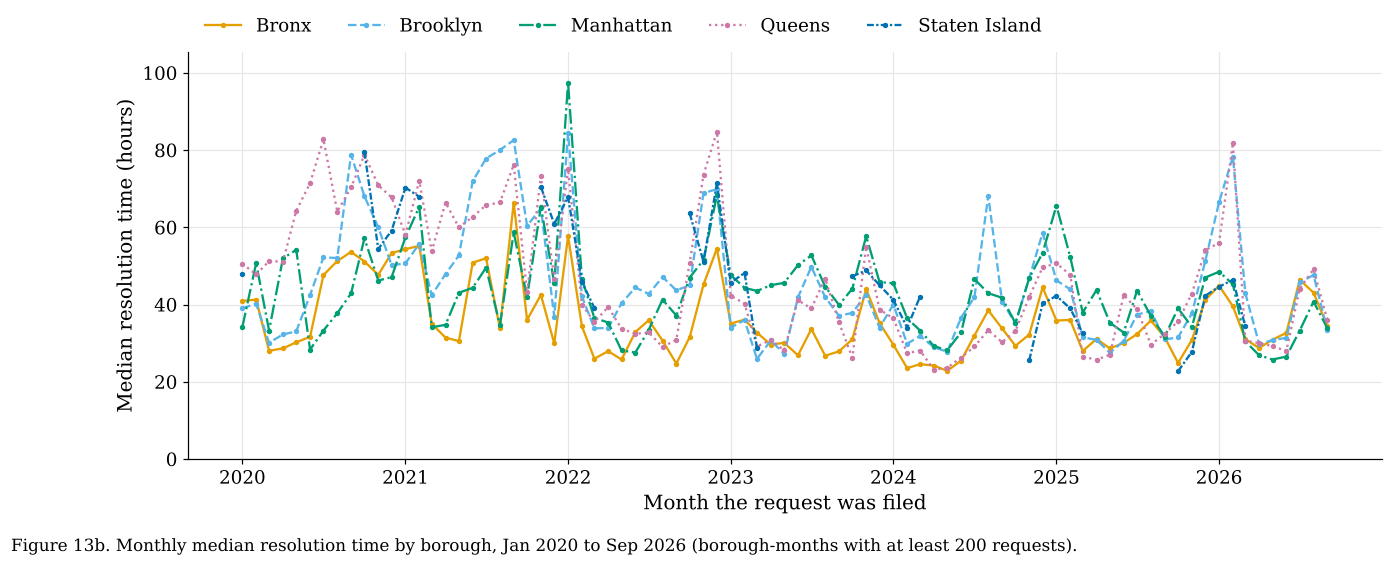

Manhattan      Jan 2022  97.5 h
Queens         Dec 2022  84.8 h
Brooklyn       Jan 2022  84.3 h
Queens         Jul 2020  82.8 h
Brooklyn       Sep 2021  82.6 h


In [93]:
# Figure 13b. Monthly median resolution time by borough.
MIN_MONTH_ROWS = 200
TREND_COLOURS = {"BRONX": "#E69F00", "BROOKLYN": "#56B4E9", "MANHATTAN": "#009E73", "QUEENS": "#CC79A7", "STATEN ISLAND": "#0072B2"}
TREND_STYLES = {"BRONX": "-", "BROOKLYN": "--", "MANHATTAN": "-.", "QUEENS": ":", "STATEN ISLAND": (0, (3, 1, 1, 1))}

before_cutoff = (eda["Created Date"] < pd.Timestamp("2026-10-01")).fillna(False).astype(bool)  # the data stops on 1 Oct 2026
monthly_borough = (
    eda[before_cutoff]
    .groupby(["Borough", "Created Year", "Created Month"])[TARGET]
    .agg(["size", "median"])
    .reset_index()
)
# Small table from here on: move it to plain Python lists.
trend_rows = zip(monthly_borough["Borough"].to_list(), monthly_borough["Created Year"].to_list(),
                 monthly_borough["Created Month"].to_list(), monthly_borough["size"].to_list(),
                 monthly_borough["median"].to_list())
trend = {}
for borough, year, month, rows, median in trend_rows:
    if rows >= MIN_MONTH_ROWS:
        trend[(str(borough), pd.Timestamp(int(year), int(month), 1))] = float(median)
all_months = list(pd.date_range("2020-01-01", "2026-09-01", freq="MS"))

fig, ax = plt.subplots(figsize=(14, 4.8))
for borough in BOROUGHS:
    # Every month is listed, so a left-out month breaks the line instead of being bridged.
    values = [trend.get((borough, month), np.nan) for month in all_months]
    ax.plot(all_months, values, color=TREND_COLOURS[borough], linestyle=TREND_STYLES[borough],
            marker="o", markersize=2.5, linewidth=1.5, label=borough.title())
ax.set_ylim(0, max(trend.values()) * 1.08)
ax.set_xlabel("Month the request was filed")
ax.set_ylabel("Median resolution time (hours)")
ax.legend(ncol=5, loc="lower left", bbox_to_anchor=(0, 1.0))

add_caption(fig, f"Figure 13b. Monthly median resolution time by borough, Jan 2020 to Sep 2026 "
                 f"(borough-months with at least {MIN_MONTH_ROWS} requests).")
fig.savefig(FIG_DIR / "13b_monthly_by_borough.png")
plt.show()

peaks = sorted(trend.items(), key=lambda item: item[1], reverse=True)[:5]
for (borough, month), median in peaks:
    print(f"{borough.title():14s} {month:%b %Y}  {median:.1f} h")

**Reading Figure 13b.** The boroughs spike together in the same winter months: January 2022 (Manhattan reaches 97.5 h), December 2022 (Queens 84.8 h)
and January 2026 are slow everywhere, which is the citywide workload effect of Figure 9. The Bronx is the lowest or close to the lowest line in most
months, so the borough effect and the time effect add up rather than cancel. Staten Island has gaps because it rarely reaches 200 requests a month.
This shared drift supports evaluating the model on a later time period.

### 10.4 What the request says

**Question the figure answers:** *Do building-wide outages and no-heat requests close at a different speed from apartment-only or hot-water requests?*

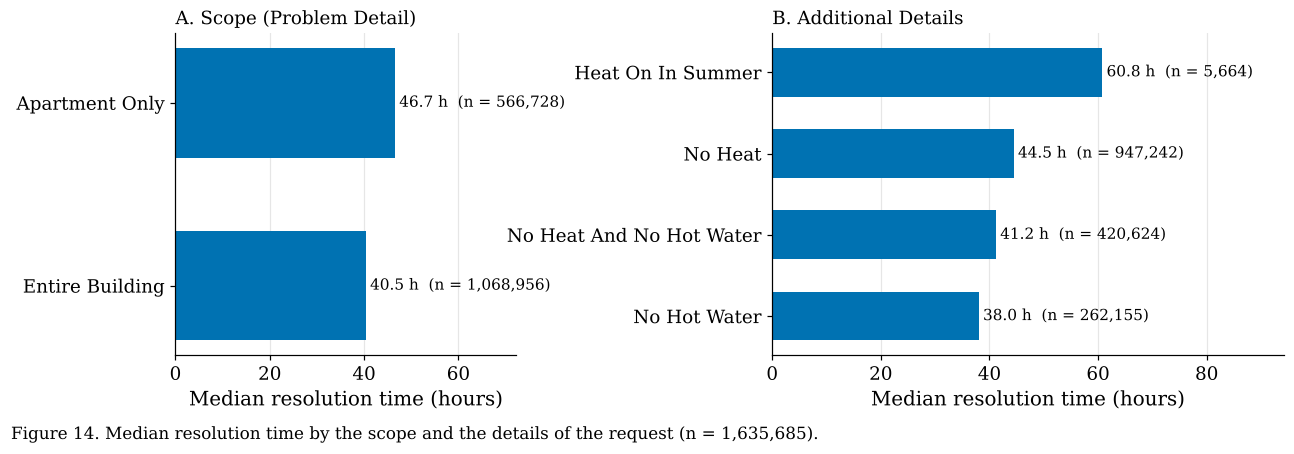

In [94]:
scope = eda.groupby(DETAIL_COL)[TARGET].agg(rows="size", median_hours="median")
details = eda.groupby(EXTRA_COL)[TARGET].agg(rows="size", median_hours="median")

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.6})
for ax, table, title in [(ax_a, scope.sort_values("median_hours"), "A. Scope (Problem Detail)"),
                         (ax_b, details.sort_values("median_hours"), "B. Additional Details")]:
    bars = ax.barh([s.title() for s in table.index], table["median_hours"], color=BLUE, height=0.6)
    for bar, (value, rows) in zip(bars, table[["median_hours", "rows"]].to_numpy()):
        ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  (n = {int(rows):,})", va="center", fontsize=10)
    ax.set_xlim(0, table["median_hours"].max() * 1.55)
    ax.set_xlabel("Median resolution time (hours)")
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(fig, f"Figure 14. Median resolution time by the scope and the details of the request (n = {len(eda):,}).", y=-0.06)
fig.savefig(FIG_DIR / "14_request_content.png")
plt.show()

**Reading Figure 14.** Building-wide requests close faster than apartment-only ones (40.5 h against 46.7 h), and hot-water-only requests are the fastest
(38.0 h). `Heat On In Summer` is the slowest group (60.8 h), but it is small (5,664 requests). Both columns are known at filing time, so both are usable features.

### 10.5 How requests end (EDA only)

**Question the figure answers:** *Which closing outcomes take longest?* This uses `Outcome (EDA only)`, which is written at closing time,
so it explains the data but must never be a model feature.

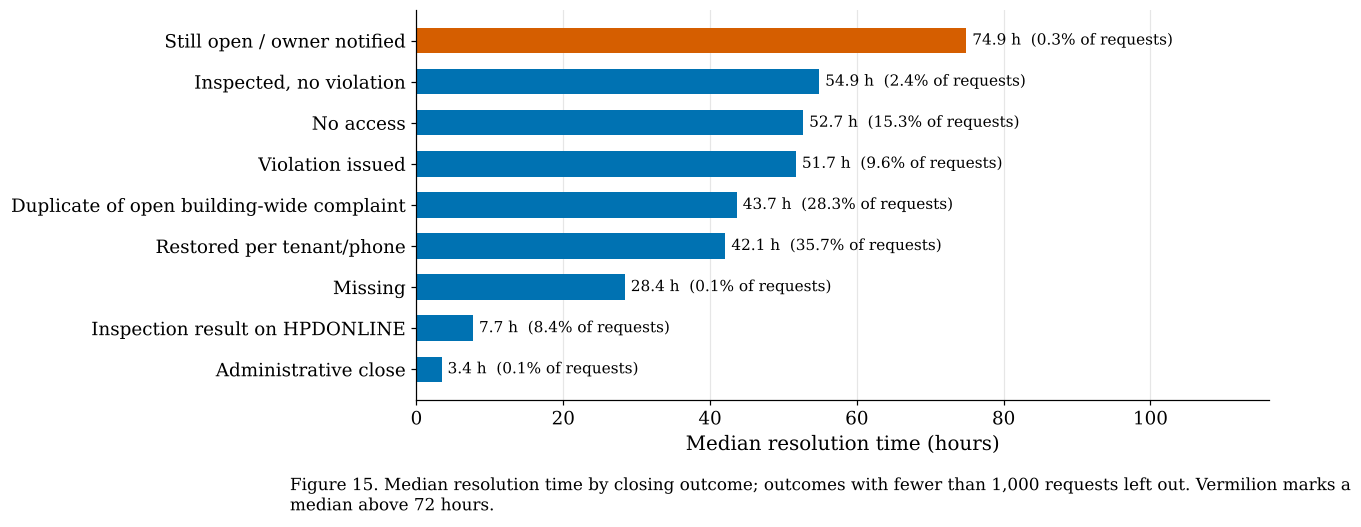

In [95]:
outcomes = eda.groupby("Outcome (EDA only)")[TARGET].agg(rows="size", median_hours="median")
outcomes = outcomes[outcomes["rows"] >= 1000].sort_values("median_hours")
outcomes["share (%)"] = outcomes["rows"] / len(eda) * 100

fig, ax = plt.subplots(figsize=(10, 4.6))
colours = [VERMILION if v > 72 else BLUE for v in outcomes["median_hours"]]
bars = ax.barh(outcomes.index, outcomes["median_hours"], color=colours, height=0.62)
for bar, (value, share) in zip(bars, outcomes[["median_hours", "share (%)"]].to_numpy()):
    ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  ({share:.1f}% of requests)", va="center", fontsize=10)
ax.set_xlim(0, outcomes["median_hours"].max() * 1.55)
ax.set_xlabel("Median resolution time (hours)")
ax.grid(axis="y", visible=False)

add_caption(fig, "Figure 15. Median resolution time by closing outcome; outcomes with fewer than 1,000 requests left out. "
                 "Vermilion marks a median above 72 hours.")
fig.savefig(FIG_DIR / "15_outcomes.png")
plt.show()

**Reading Figure 15.** Most requests end in one of two ways: the tenant or a phone check confirms heat was restored (35.7%, 42.1 h), or the request is closed as a
duplicate of an open building-wide complaint (28.3%, 43.7 h). Requests where the inspector could not get in (15.3%) or issued a violation (9.6%) take about 10 hours longer.
Requests that point to the inspection result on HPDONLINE close in 7.7 h. This shows that the slow cases are the ones needing a site visit, but the outcome is only known
after closing, so it stays out of every model.

### 10.6 Which features move together with resolution time

**Question the figure answers:** *Of the features known at filing time, which ones have the strongest relationship with resolution time?*

Spearman's rank correlation is used, because the target is skewed and the relationships are not straight lines.
It is computed as the ordinary correlation of the ranks, which gives the same number without needing SciPy.

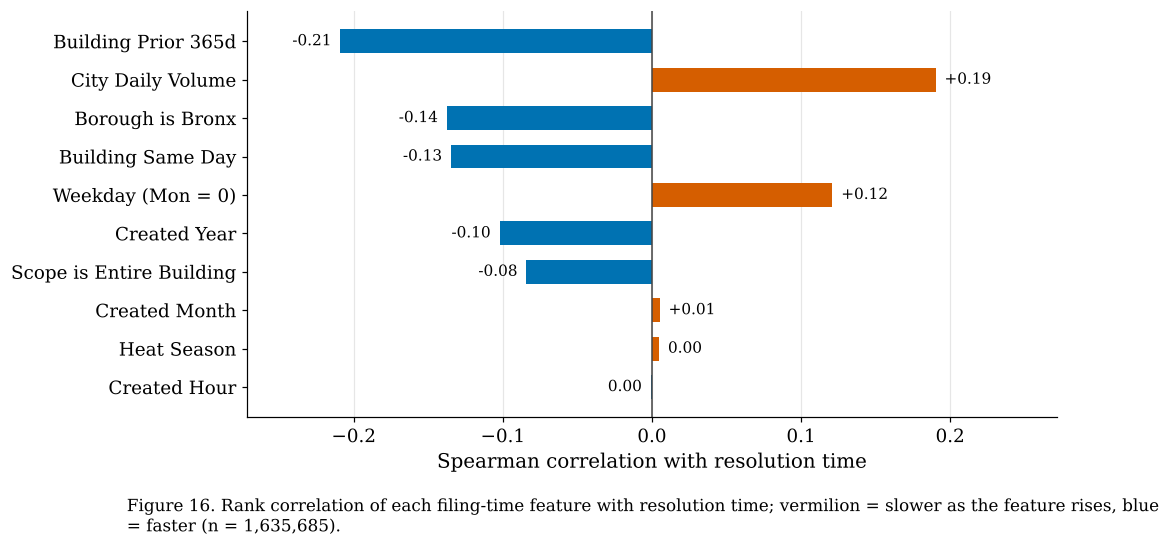

,Spearman
Building Prior 365d,-0.209
City Daily Volume,0.190
Borough is Bronx,-0.138
Building Same Day,-0.135
Weekday (Mon = 0),0.121
Created Year,-0.102
Scope is Entire Building,-0.084
Created Month,0.005
Heat Season,0.005
Created Hour,-0.001


In [96]:
features = pd.DataFrame(
    {
        "Building Prior 365d": eda["Building Prior 365d"],
        "City Daily Volume": eda["City Daily Volume"],
        "Building Same Day": eda["Building Same Day"],
        "Borough is Bronx": (eda["Borough"] == "BRONX").astype(int),
        "Weekday (Mon = 0)": eda["Created Date"].dt.dayofweek,
        "Created Hour": eda["Created Hour"],
        "Created Month": eda["Created Month"],
        "Created Year": eda["Created Year"],
        "Scope is Entire Building": (eda[DETAIL_COL] == "ENTIRE BUILDING").astype(int),
        "Heat Season": eda["Heat Season"].astype(int),
    }
)
ranks = features.rank()
spearman = ranks.corrwith(eda[TARGET].rank()).sort_values(key=abs)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
colours = [VERMILION if v > 0 else BLUE for v in spearman]
bars = ax.barh(spearman.index, spearman.values, color=colours, height=0.62)
for bar, value in zip(bars, spearman.values):
    ax.text(value + (0.006 if value >= 0 else -0.006), bar.get_y() + bar.get_height() / 2, f"{value:+.2f}" if abs(value) >= 0.005 else "0.00",
            va="center", ha="left" if value >= 0 else "right", fontsize=10)
ax.axvline(0, color="#444444", linewidth=1)
limit = spearman.abs().max() * 1.3
ax.set_xlim(-limit, limit)
ax.set_xlabel("Spearman correlation with resolution time")
ax.grid(axis="y", visible=False)

add_caption(fig, f"Figure 16. Rank correlation of each filing-time feature with resolution time; vermilion = slower as the feature rises, "
                 f"blue = faster (n = {len(eda):,}).")
fig.savefig(FIG_DIR / "16_feature_correlation.png")
plt.show()
spearman.round(3).to_frame("Spearman")[::-1]

**Reading Figure 16.** The strongest single signals are building history (−0.21: frequent-filer buildings close faster) and citywide workload (+0.19: busy days are slower),
followed by the Bronx (−0.14), same-day complaints from the same building (−0.13) and the weekday (+0.12). Month, heat season and hour are close to 0 on their own.
No feature is strong alone (all |ρ| ≤ 0.21), so a model has to combine them, which points to a tree-based model, with a logistic regression as the baseline.

### 10.7 Intake channel and weekday

**Question the figure answers:** *Does the weekday effect look the same for requests made online, by phone and by mobile app?*

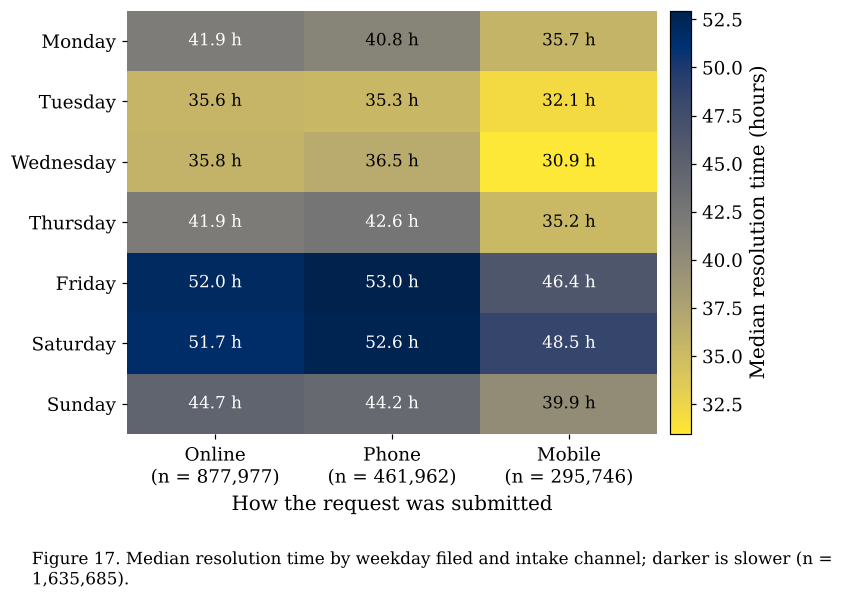

Open Data Channel Type,ONLINE,PHONE,MOBILE
Created Weekday,,,
Monday,41.9,40.8,35.7
Tuesday,35.6,35.3,32.1
Wednesday,35.8,36.5,30.9
Thursday,41.9,42.6,35.2
Friday,52.0,53.0,46.4
Saturday,51.7,52.6,48.5
Sunday,44.7,44.2,39.9


In [97]:
CHANNEL_COL = "Open Data Channel Type"
channel_weekday = eda.pivot_table(index="Created Weekday", columns=CHANNEL_COL, values=TARGET, aggfunc="median").reindex(WEEKDAY_ORDER)
channel_weekday = channel_weekday[eda[CHANNEL_COL].value_counts().index]  # largest channel first

fig, ax = plt.subplots(figsize=(7.5, 5))
image = ax.imshow(channel_weekday.values, aspect="auto", cmap="cividis_r")
for (row, col), value in np.ndenumerate(channel_weekday.values):
    ax.text(col, row, f"{value:.1f} h", ha="center", va="center", fontsize=11,
            color="white" if value > channel_weekday.values.mean() else "black")
ax.set_xticks(range(channel_weekday.shape[1]))
ax.set_xticklabels([f"{c.title()}\n(n = {eda[CHANNEL_COL].eq(c).sum():,})" for c in channel_weekday.columns])
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAY_ORDER)
ax.set_xlabel("How the request was submitted")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, pad=0.02).set_label("Median resolution time (hours)")

add_caption(fig, f"Figure 17. Median resolution time by weekday filed and intake channel; darker is slower (n = {len(eda):,}).", y=-0.1)
fig.savefig(FIG_DIR / "17_weekday_channel.png")
plt.show()
channel_weekday.round(1)

**Reading Figure 17.** The weekday pattern holds in every channel: Friday and Saturday are the slowest rows and Tuesday and Wednesday the fastest,
whether the request came online, by phone or by mobile app. Mobile requests close a few hours faster on every day (30.9 to 48.5 h, against 35 to 53 h online and by phone).
The two effects mostly add up rather than interact, so both weekday and channel are useful features; why the app is faster (who uses it, or what it captures) is not tested here.

### 10.8 Where slow requests cluster

**Question the figure answers:** *Are there parts of the city where heating requests take unusually long?*

Every request with coordinates is placed on a grid of cells about 1 km across (0.01° of latitude and longitude), and each cell shows its median.
Cells with fewer than 50 requests are left out, because their medians are unstable. No sampling is used.

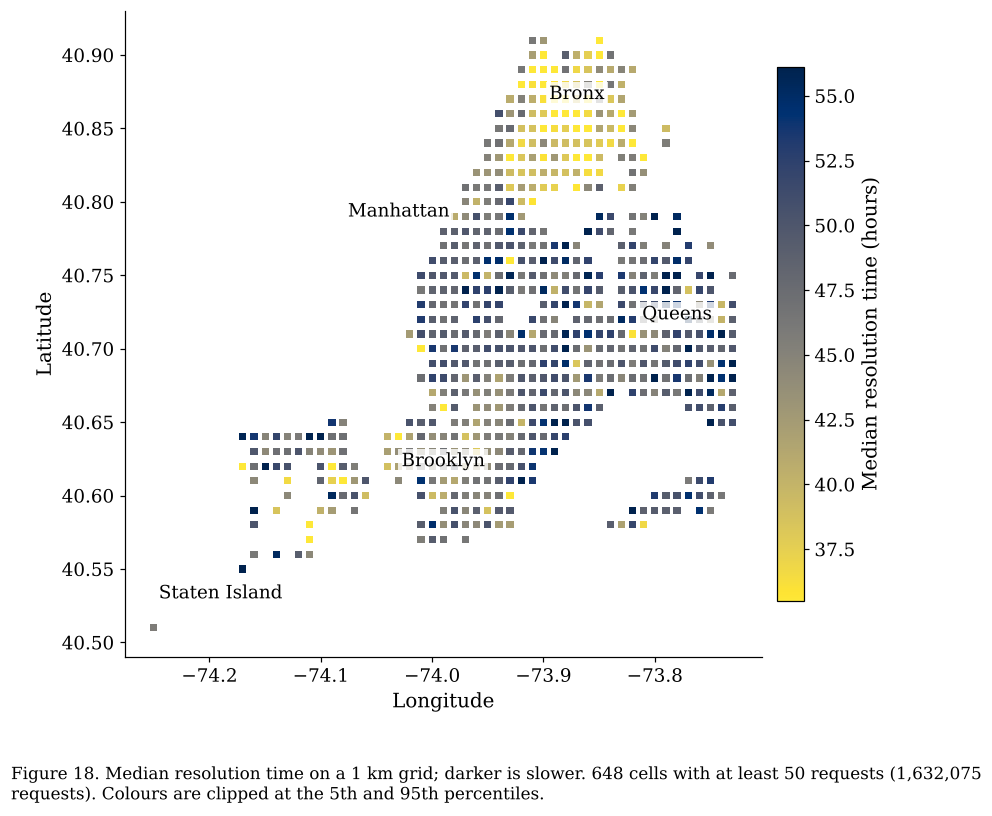

Cells: 648; median of cell medians 47.2 h; slowest 10% of cells above 54.0 h


,lat,lon,requests,median_hours
673,40.78,-73.86,50,74.5
596,40.75,-73.78,71,67.6
548,40.74,-73.94,50,67.4
41,40.55,-74.17,69,64.8
253,40.64,-74.11,180,64.4


In [98]:
MIN_CELL_REQUESTS = 50
geo = eda.dropna(subset=["Latitude", "Longitude"])
grid = (
    geo.assign(lat=geo["Latitude"].round(2), lon=geo["Longitude"].round(2))
    .groupby(["lat", "lon"])[TARGET].agg(requests="size", median_hours="median")
    .reset_index()
)
grid = grid[grid["requests"] >= MIN_CELL_REQUESTS]

fig, ax = plt.subplots(figsize=(9, 9))
points = ax.scatter(grid["lon"], grid["lat"], c=grid["median_hours"], cmap="cividis_r", marker="s", s=22,
                    vmin=grid["median_hours"].quantile(0.05), vmax=grid["median_hours"].quantile(0.95), linewidths=0)
ax.set_aspect(1 / np.cos(np.radians(40.7)))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(False)
fig.colorbar(points, ax=ax, shrink=0.7, pad=0.02).set_label("Median resolution time (hours)")
for name, (lon, lat) in {"Bronx": (-73.87, 40.87), "Manhattan": (-74.03, 40.79), "Brooklyn": (-73.99, 40.62),
                         "Queens": (-73.78, 40.72), "Staten Island": (-74.19, 40.53)}.items():
    ax.text(lon, lat, name, fontsize=12, ha="center", bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 2})

add_caption(fig, f"Figure 18. Median resolution time on a 1 km grid; darker is slower. {len(grid):,} cells with at least {MIN_CELL_REQUESTS} requests "
                 f"({grid['requests'].sum():,} requests). Colours are clipped at the 5th and 95th percentiles.", y=0.06)
fig.savefig(FIG_DIR / "18_geographic_grid.png")
plt.show()

print(f"Cells: {len(grid):,}; median of cell medians {grid['median_hours'].median():.1f} h; "
      f"slowest 10% of cells above {grid['median_hours'].quantile(0.9):.1f} h")
grid.nlargest(5, "median_hours").round({"median_hours": 1})

**Reading Figure 18.** The fast area is the Bronx: most of its cells are below 40 hours. Slower cells are spread across Queens, Brooklyn, upper Manhattan and Staten Island
rather than forming one hot spot; the slowest 10% of the 648 cells have medians above 54 hours, and the slowest single cell reaches 74.5 hours.
Location therefore matters mostly at the borough and neighbourhood level, which supports using borough, zip code or community board, and coordinates, as model features.

**Question the figure answers:** *Which community boards are the slowest and the fastest, among boards with enough requests to trust their median?*

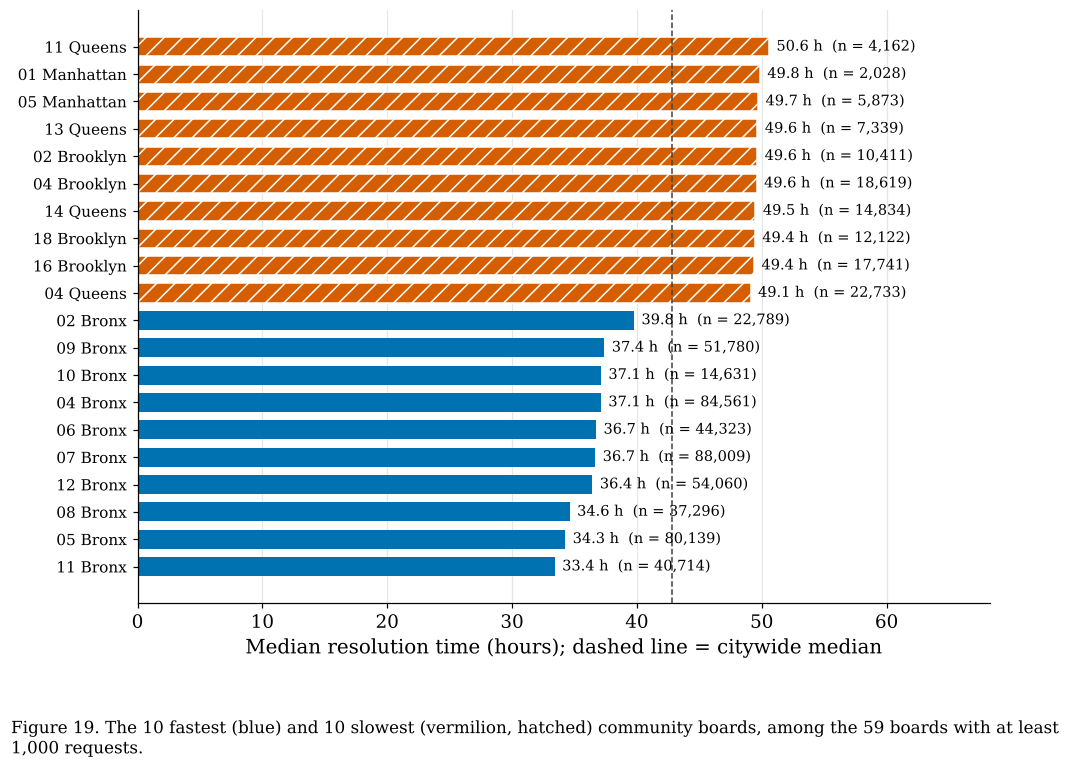

Spread between the fastest and slowest board: 33.4 h to 50.6 h


In [99]:
MIN_BOARD_REQUESTS = 1000
boards = eda.dropna(subset=["Community Board"]).groupby("Community Board")[TARGET].agg(requests="size", median_hours="median")
boards = boards[boards["requests"] >= MIN_BOARD_REQUESTS].sort_values("median_hours")
board_extremes = pd.concat([boards.head(10), boards.tail(10)])

fig, ax = plt.subplots(figsize=(10, 7))
colours = [BLUE] * 10 + [VERMILION] * 10
bars = ax.barh(board_extremes.index.str.title(), board_extremes["median_hours"], color=colours, height=0.7)
for bar in bars[10:]:
    bar.set_hatch("//")
    bar.set_edgecolor("white")
for bar, (value, rows) in zip(bars, board_extremes[["median_hours", "requests"]].to_numpy()):
    ax.text(value + 0.6, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  (n = {int(rows):,})", va="center", fontsize=9.5)
ax.axvline(eda[TARGET].median(), color="#444444", linestyle="--", linewidth=1)
ax.set_xlim(0, board_extremes["median_hours"].max() * 1.35)
ax.set_xlabel("Median resolution time (hours); dashed line = citywide median")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", visible=False)

add_caption(fig, f"Figure 19. The 10 fastest (blue) and 10 slowest (vermilion, hatched) community boards, among the {len(boards)} boards "
                 f"with at least {MIN_BOARD_REQUESTS:,} requests.")
fig.savefig(FIG_DIR / "19_community_boards.png")
plt.show()
print(f"Spread between the fastest and slowest board: {boards['median_hours'].iloc[0]:.1f} h to {boards['median_hours'].iloc[-1]:.1f} h")

**Reading Figure 19.** All ten fastest community boards are in the Bronx (33.4 to 39.8 hours), and they are also some of the busiest, with up to 88,009 requests each.
The ten slowest boards are in Queens, Brooklyn and Manhattan and sit close together at 49.1 to 50.6 hours. Community board therefore separates the Bronx clearly
but adds little detail elsewhere, so borough plus a few location features should capture most of the geographic signal.

**Question the figure answers:** *Do zip codes with more heating requests close them faster or slower?*

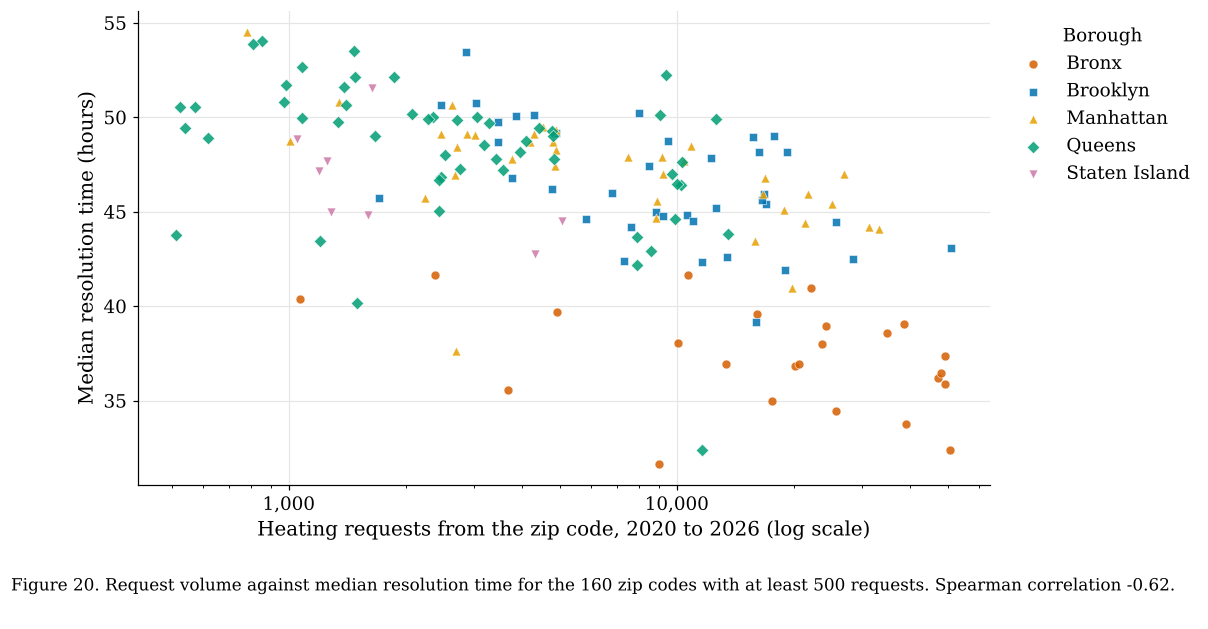

,count,min,50%,max
borough,,,,
BRONX,24.0,31.7,37.2,41.6
BROOKLYN,38.0,39.1,46.0,53.5
MANHATTAN,37.0,37.6,47.7,54.5
QUEENS,53.0,32.4,49.0,54.0
STATEN ISLAND,8.0,42.8,46.1,51.6


In [100]:
MIN_ZIP_REQUESTS = 500
zips = (
    eda.dropna(subset=["Incident Zip", "Borough"])
    .groupby("Incident Zip")
    .agg(requests=(TARGET, "size"), median_hours=(TARGET, "median"), borough=("Borough", lambda b: b.mode().iloc[0]))
)
zips = zips[zips["requests"] >= MIN_ZIP_REQUESTS]
zip_rho = zips["requests"].rank().corr(zips["median_hours"].rank())

BOROUGH_COLOURS = {"BRONX": VERMILION, "BROOKLYN": BLUE, "MANHATTAN": ORANGE, "QUEENS": "#009E73", "STATEN ISLAND": "#CC79A7"}
BOROUGH_MARKERS = {"BRONX": "o", "BROOKLYN": "s", "MANHATTAN": "^", "QUEENS": "D", "STATEN ISLAND": "v"}

fig, ax = plt.subplots(figsize=(10, 5.6))
for borough, group in zips.groupby("borough"):
    ax.scatter(group["requests"], group["median_hours"], s=34, alpha=0.85, color=BOROUGH_COLOURS[borough],
               marker=BOROUGH_MARKERS[borough], label=borough.title(), edgecolors="white", linewidths=0.4)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Heating requests from the zip code, 2020 to 2026 (log scale)")
ax.set_ylabel("Median resolution time (hours)")
ax.legend(title="Borough", loc="upper left", bbox_to_anchor=(1.01, 1))

add_caption(fig, f"Figure 20. Request volume against median resolution time for the {len(zips)} zip codes with at least {MIN_ZIP_REQUESTS} requests. "
                 f"Spearman correlation {zip_rho:+.2f}.")
fig.savefig(FIG_DIR / "20_zip_volume.png")
plt.show()
zips.groupby("borough")["median_hours"].describe()[["count", "min", "50%", "max"]].round(1)

**Reading Figure 20.** Across the 160 zip codes with at least 500 requests, busier zip codes close faster (Spearman −0.62). The Bronx zip codes (31.7 to 41.6 hours) drive
much of this, but the downward drift is also visible within Queens and Brooklyn. It is the same pattern as building history in Figure 9B: places HPD deals with often are handled faster.

## 11. Interactive dashboard

One interactive view of the main findings. The drop-down at the top filters every panel to one borough, and the title updates with that
borough's request count, median and share of slow requests. Hover over any bar or point for the exact numbers.

It needs `plotly` (`pip install plotly`). The dashboard is also saved as `figures/dashboard.html`, which opens in any browser without Python.
The main dashboard is built in Tableau from the cleaned file exported in section 12; this view tells the same story inside the notebook.

In [101]:
try:
    import plotly.graph_objects as go
    import plotly.io as pio
    from plotly.subplots import make_subplots
    pio.renderers.default = "plotly_mimetype+notebook_connected"  # interactive in Jupyter, VS Code and saved HTML
except ImportError:
    go = None
    print("plotly is not installed: run `pip install plotly` and re-run this section.")

In [102]:
SELECTIONS = ["All boroughs"] + BOROUGHS
VOLUME_BANDS = ["under 500", "500-1k", "1k-2k", "2k-4k", "over 4k"]
HISTORY_BANDS = ["0", "1-4", "5-19", "20-99", "100+"]

dash = eda[["Created Date", "Borough", "Created Weekday", "City Daily Volume", "Building Prior 365d", TARGET, "Slow"]].copy()
dash["month"] = dash["Created Date"].dt.to_period("M").dt.to_timestamp()
dash.loc[dash["month"] >= "2026-10-01", "month"] = pd.NaT  # partial month left out of the monthly line only
dash["volume band"] = pd.cut(dash["City Daily Volume"], [0, 500, 1000, 2000, 4000, np.inf], labels=VOLUME_BANDS)
dash["history band"] = pd.cut(dash["Building Prior 365d"], [-1, 0, 4, 19, 99, np.inf], labels=HISTORY_BANDS)


def panel_data(frame):
    """The four aggregates the dashboard draws, for one selection."""
    return {
        "monthly": frame.groupby("month")[TARGET].median(),
        "weekday": frame.groupby("Created Weekday")[TARGET].median().reindex(WEEKDAY_ORDER),
        "volume": frame.groupby("volume band", observed=True)["Slow"].mean().reindex(VOLUME_BANDS) * 100,
        "history": frame.groupby("history band", observed=True)[TARGET].median().reindex(HISTORY_BANDS),
        "title": (f"{len(frame):,} requests  ·  median {frame[TARGET].median():.1f} h  ·  "
                  f"{frame['Slow'].mean() * 100:.1f}% slower than 72 h"),
    }


panels = {name: panel_data(dash if name == "All boroughs" else dash[dash["Borough"] == name]) for name in SELECTIONS}
print("\n".join(f"{name:14s} {p['title']}" for name, p in panels.items()))

All boroughs   1,635,685 requests  ·  median 42.8 h  ·  21.1% slower than 72 h
BRONX          579,430 requests  ·  median 36.5 h  ·  14.6% slower than 72 h
BROOKLYN       441,347 requests  ·  median 45.4 h  ·  24.2% slower than 72 h
MANHATTAN      377,307 requests  ·  median 45.9 h  ·  24.3% slower than 72 h
QUEENS         219,260 requests  ·  median 46.9 h  ·  26.4% slower than 72 h
STATEN ISLAND  18,334 requests  ·  median 45.9 h  ·  25.1% slower than 72 h


In [103]:
if go is not None:
    fig = make_subplots(
        rows=2, cols=2, vertical_spacing=0.16, horizontal_spacing=0.09,
        subplot_titles=[
            "Median resolution time by month (hours)",
            "Median resolution time by weekday filed (hours)",
            "Share slower than 72 h by citywide requests that day (%)",
            "Median resolution time by building's requests in prior year (hours)",
        ],
    )
    for k, name in enumerate(SELECTIONS):
        p = panels[name]
        visible = k == 0
        fig.add_trace(go.Scatter(x=p["monthly"].index, y=p["monthly"].values, mode="lines", line={"color": VERMILION, "width": 2},
                                 name="monthly", visible=visible, hovertemplate="%{x|%b %Y}: %{y:.1f} h<extra></extra>"), 1, 1)
        fig.add_trace(go.Bar(x=[d[:3] for d in WEEKDAY_ORDER], y=p["weekday"].values, marker_color=BLUE,
                             name="weekday", visible=visible, hovertemplate="%{x}: %{y:.1f} h<extra></extra>"), 1, 2)
        fig.add_trace(go.Bar(x=VOLUME_BANDS, y=p["volume"].values, marker_color=VERMILION,
                             name="workload", visible=visible, hovertemplate="%{x}: %{y:.1f}%<extra></extra>"), 2, 1)
        fig.add_trace(go.Bar(x=HISTORY_BANDS, y=p["history"].values, marker_color=BLUE,
                             name="history", visible=visible, hovertemplate="%{x} prior requests: %{y:.1f} h<extra></extra>"), 2, 2)

    buttons = []
    for k, name in enumerate(SELECTIONS):
        visible = [j // 4 == k for j in range(4 * len(SELECTIONS))]
        buttons.append({"label": name.title(), "method": "update",
                        "args": [{"visible": visible}, {"title.text": f"<b>HPD heat complaints, {name.title()}</b><br><sup>{panels[name]['title']}</sup>"}]})

    fig.update_layout(
        title={"text": f"<b>HPD heat complaints, All Boroughs</b><br><sup>{panels['All boroughs']['title']}</sup>", "x": 0.01},
        updatemenus=[{"buttons": buttons, "x": 1.0, "xanchor": "right", "y": 1.13, "yanchor": "top", "showactive": True}],
        template="simple_white", font={"family": "Times New Roman, DejaVu Serif, serif", "size": 13},
        height=720, showlegend=False, margin={"t": 120, "l": 60, "r": 30, "b": 50},
    )
    fig.update_yaxes(rangemode="tozero", gridcolor="#E6E6E6", showgrid=True)
    fig.write_html(FIG_DIR / "dashboard.html", include_plotlyjs=True)
    fig.show()

**How to read the dashboard.** The top-left panel shows the seasonal cycle and the slow winter of 2021-22. The top-right panel repeats the weekday pattern from section 7.2.
The bottom-left panel shows workload pushing up the share of slow requests, and the bottom-right panel shows frequent-filer buildings closing faster (Figure 9).
Switching boroughs shows whether each pattern holds everywhere or is driven by one borough.

## 12. Export for the Tableau dashboard

The cleaned dataset is written as one CSV that Tableau opens directly. It keeps the target, the flags, the features and the fields needed for maps and filters,
and leaves out long free text. `Outcome (EDA only)` is included for descriptive views only.

**Suggested Tableau views:**
1. Map of median resolution time by zip code or community board (`Latitude`/`Longitude` or `Incident Zip`).
2. Monthly line of median `Resolution Hours` with a `Borough` filter (Figure 13).
3. Weekday by hour heat map (Figure 11).
4. Slow share by `City Daily Volume` band and by `Building Prior 365d` band (Figure 9).
5. Distribution of `Resolution Hours` with the 72-hour line (Figure 7).
6. Outcome bar chart, labelled as after-the-fact information (Figure 15).

In [104]:
TABLEAU_COLS = [
    "Created Date", "Closed Date", TARGET, "Resolution Hours Capped", "Slow Over 72h",
    "Is Negative Duration", "Is Instant Close",
    DETAIL_COL, EXTRA_COL, "Open Data Channel Type",
    "Borough", "Incident Zip", "Community Board", "Council District", "Police Precinct", "BBL", "Building ID",
    "Incident Address", "Latitude", "Longitude",
    "Created Year", "Created Month", "Created Weekday", "Created Hour", "Heat Season", "Season",
    "City Daily Volume", "Building Same Day", "Building Prior 365d", "Outcome (EDA only)",
]
TABLEAU_CSV = DATA_DIR / "heating_clean_tableau.csv"

clean[TABLEAU_COLS].to_csv(TABLEAU_CSV, index=False, date_format="%Y-%m-%d %H:%M:%S")
print(f"Wrote {TABLEAU_CSV}: {len(clean):,} rows x {len(TABLEAU_COLS)} columns, {TABLEAU_CSV.stat().st_size / 1e6:,.0f} MB")

Wrote data/heating_clean_tableau.csv: 1,635,869 rows x 30 columns, 512 MB


## 13. Key findings

1. **The target is heavily skewed.** The median request closes in 42.8 hours, but the mean is 50.9 hours and the slowest take almost four years (skew 119).
   One request in five (21.1%) takes longer than 72 hours. Medians and a slow/not-slow label describe it better than the mean (Figure 7).
2. **Workload is the clearest driver.** On days with under 500 heating requests citywide the median is 34 hours; above 4,000 it is 67 hours (Figure 9A).
3. **Building history speeds things up.** Buildings with 100 or more requests in the previous year close in 32 hours, against 52 hours for buildings with none,
   likely because many repeat requests close as duplicates of an open building-wide complaint (Figures 9B and 15).
4. **Timing matters more than place.** Requests filed late on Friday and on Saturday wait up to 61 hours, against about 31 hours on Tuesday and Wednesday (Figures 11 and 17).
5. **The Bronx is the exception among boroughs.** It closes fastest (36.5 hours, 14.6% slow) despite having the most requests; the other four sit at 45 to 47 hours (Figures 10 and 18).
6. **What the tenant reports matters.** Whole-building outages close faster than single-apartment ones (40.5 against 46.7 hours) (Figure 14).
7. **No single feature is enough.** The strongest rank correlation with resolution time is 0.21, so a model must combine several weak signals (Figure 16).
8. **Season matters more than the hour.** Requests filed in March to May close in about 26 to 39 hours whatever the hour; December and January reach 54 to 56 hours (Figure 12).
9. **Familiar places close faster at every scale.** The pattern seen for buildings also holds for zip codes: busier zip codes have lower medians (Spearman −0.62),
   and all ten fastest community boards are in the Bronx (Figures 19 and 20).

**Next steps for modelling.** Add the NOAA daily minimum temperature (section 7.11), fit both pipelines on the training seasons,
tune the class weight or resampling ratio on the validation season, and report recall, F1 and PR-AUC on the held-out 2025-26 season.

## 14. Challenges and how they were handled

| Challenge | How it was handled |
|---|---|
| A 16 GB file that does not fit in memory | the heating rows were extracted once (DuckDB or a streamed read) and cached; every later step works on 1.6 million rows |
| The category label changed to Title case from 10 Aug to 6 Oct 2023 | every category was matched and counted on the upper-cased, trimmed text |
| Duplicates hidden by the unique ID | the ID was dropped before checking; 3,128 exact copies removed, 70% from the mobile app |
| Placeholders that `isna()` cannot see (`Unspecified`, zip `12345`, BBL `0000000000`) | searched every column and converted them to real blanks |
| Impossible values (184 requests closed before they opened) | blanked and flagged, not silently dropped |
| A target with a four-year tail | kept every row; used medians, a 72-hour label and a capped version |
| Columns that leak the answer | identified and kept out of every predictor set |
| The best predictors are not columns | built by aggregating the data (per day, per building) and merging the counts back to each request |
| Open requests are mostly recent | dropped as missing targets, and noted as a reason for a time-based split |